# Bulk RNA-seq DE analysis on Th1/Th2 regulators

Two batches:
- **Diff081** — original TF set, non-polarized (single condition).
- **Diff084** — extended TF set, polarized in Th0 / Th1 / Th2 conditions.

Pipeline:
1. Load + DESeq2 for each batch separately (writes per-batch CSV).
2. Build a combined long-format DE table (`bulkRNAseq_DESeq2_results.combined.csv`).
3. Run all downstream comparisons / signature analyses on the combined table.


In [1]:
import os,sys
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import anndata
import scanpy as sc
import pertpy
import scipy.stats
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import pearsonr as _pearsonr
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from adjustText import adjust_text

sys.path.append('../3_DE_analysis/')
from DE_analysis_utils import *

# Keep text editable in Illustrator: embed TrueType (Type 42) in PDF/PS
# and leave SVG text as <text> rather than converting to paths.
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/anndata/utils.py:435: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/

## §1 Load all batches

Concatenate Diff081 (PDKJK2, non-polarized only), Diff084 and Diff089 (both polarized: Th0/Th1/Th2) into one count matrix and one sample-metadata frame. Donors are batch-specific (e.g. Diff084's DonorB ≠ Diff089's DonorB), so donor identifiers are prefixed with the batch.

Diff081 perturbation labels are guide-level (e.g. `M-24`, `F-32-2`); they're mapped to gene-level via `GUIDE_TO_TARGET` so guide aliases pool with their gene-named counterparts in Diff084/Diff089. FBXO32-2 / FBXO32-3 are kept distinct (FBXO32 / FBXO32-3) — both are needed for the §9 follow-up.

In [2]:
# Diff081 guide -> gene-level target mapping. Covers the bulk DE contrast names
# (some carry a '-1' suffix, e.g. 'F120A-1', 'STAT6-1'). FBXO32 guides are kept
# distinct (-2 -> FBXO32, -3 -> FBXO32-3) since they're studied separately in §9.
GUIDE_TO_TARGET = {
    'M-24':    'MED24',
    'KD-1':    'KDM1A',
    'PT-2':    'PTPN2',
    'F-32-2':  'FBXO32',
    'F-32-3':  'FBXO32-3',
    'AP-2-2':  'APPBP2',
    'F120A':   'FAM120A',
    'F120A-1': 'FAM120A',
    'CDK1-1':  'CDKAL1',
    'CDK-1-1': 'CDKAL1',
    'STAT6':   'STAT6',
    'STAT6-1': 'STAT6',
    'NTChe':   'NTC',
    'MTA2':    'MTA2',
    'TBX21':   'TBX21',
    'GATA3':   'GATA3',
    'JAK2':    'JAK2',
}

In [34]:
# Loader for the polarized batches (Diff084 / Diff089). Both ship one results
# directory per condition, with sample-name CSVs alongside.
def load_polarized_batch(batch, data_root, experiments):
    def load_meta(path):
        m = pd.read_csv(path, encoding='utf-8-sig')
        m = m.loc[:, ~m.columns.str.match(r'^Unnamed')]
        m.columns = [c.strip() for c in m.columns]
        return m

    per_cond_meta, per_cond_expr = [], []
    gene_annot_local = None
    for cond, info in experiments.items():
        expr = pd.read_csv(
            f"{data_root}/{info['id']}_results/{info['id']}-expression-matrix.tsv", sep='\t')
        meta = load_meta(f"{data_root}/{info['meta']}")
        meta['donor'] = meta['sample_name'].str.split('_').str[0]
        meta['perturbation'] = meta['sample_name'].str.split('_').str[1]
        meta['condition'] = cond
        meta['exp_id'] = info['id']
        meta['batch'] = batch
        meta['Flag'] = meta['Flag'].astype(str).str.upper() == 'TRUE'
        meta['LowRNA'] = meta['LowRNA'].astype(str).str.upper() == 'TRUE'

        count_cols = [f"{info['id']}_{i}_count" for i in meta['sample']]
        counts = expr.set_index('gene_id')[count_cols].copy()
        # Globally unique sample id: batch__cond__sample_name
        counts.columns = [f'{batch}__{cond}__{n}' for n in meta['sample_name'].values]
        meta['full_sample_name'] = list(counts.columns)

        per_cond_meta.append(meta)
        per_cond_expr.append(counts)
        if gene_annot_local is None:
            gene_annot_local = expr[['gene_id','gene_name','gene_biotype']].set_index('gene_id')

    sample_meta_b = pd.concat(per_cond_meta, ignore_index=True)
    counts_b = pd.concat(per_cond_expr, axis=1)
    return counts_b, sample_meta_b, gene_annot_local


# Loader for Diff081 (PDKJK2). One sequencing experiment, no condition arms.
def load_diff081_batch():
    data_dir = '/mnt/oak/users/emma/data/GWT/PDKJK2_results'
    expr = pd.read_csv(f'{data_dir}/PDKJK2-expression-matrix.tsv', sep='\t')
    sample_names = pd.read_csv(
        f'{data_dir}/PDKJK2-mapping-stats-reads.csv',
        usecols=[0], header=None, skiprows=1)[0].values

    meta = pd.DataFrame({
        'sample': range(1, len(sample_names) + 1),
        'sample_name': sample_names,
    })
    meta['donor'] = meta['sample_name'].str.split('_').str[0]
    meta['perturbation'] = meta['sample_name'].str.split('_', n=1).str[1]
    meta['condition'] = 'Th0'
    meta['exp_id'] = 'PDKJK2'
    meta['batch'] = 'Diff081'
    # Diff081 has no Flag/LowRNA columns — assume all retained
    meta['Flag'] = False
    meta['LowRNA'] = False

    count_cols = [f'PDKJK2_{i}_count' for i in meta['sample']]
    counts = expr.set_index('gene_id')[count_cols].copy()
    counts.columns = [f'Diff081__Th0__{n}' for n in meta['sample_name'].values]
    meta['full_sample_name'] = list(counts.columns)

    gene_annot_local = expr[['gene_id','gene_name','gene_biotype']].set_index('gene_id')
    return counts, meta, gene_annot_local

In [35]:
# Load all three batches
counts_84, meta_84, gene_annot_84 = load_polarized_batch(
    batch='Diff084',
    data_root='/mnt/oak/users/emma/data/GWT/Diff084bulkRNAseq',
    experiments={
        'Th0': {'id': 'FMZ494', 'meta': 'Diff084_Day12_nonpolarized_FMZ494_sample_name.csv'},
        'Th1': {'id': 'P567SY', 'meta': 'Diff084_Day12_Th1_P567SY_sample_name.csv'},
        'Th2': {'id': 'NM89Y9', 'meta': 'Diff084_Day12_Th2_NM89Y9_sample_name.csv'},
    },
)
counts_89, meta_89, gene_annot_89 = load_polarized_batch(
    batch='Diff089',
    data_root='/mnt/oak/users/emma/data/GWT/Diff089bulkRNAseq',
    experiments={
        'Th0': {'id': 'BT2R52', 'meta': 'Diff089Day12_nonpolarized_BT2R52_sample_name.csv'},
        'Th1': {'id': 'JVCNWP', 'meta': 'Diff089Day12_Th1_JVCNWP_sample_name.csv'},
        'Th2': {'id': 'MNX6KK', 'meta': 'Diff089Day12_Th2_MNX6KK_sample_name.csv'},
    },
)
counts_81, meta_81, gene_annot_81 = load_diff081_batch()

# Concatenate counts along samples; intersect on gene_id (all batches use the
# same reference, so the intersection should drop only a handful of genes).
common_genes = counts_84.index.intersection(counts_89.index).intersection(counts_81.index)
print(f'gene set: 84={counts_84.shape[0]}, 89={counts_89.shape[0]}, '
      f'81={counts_81.shape[0]}, intersection={len(common_genes)}')

counts_all = pd.concat([
    counts_81.loc[common_genes],
    counts_84.loc[common_genes],
    counts_89.loc[common_genes],
], axis=1)

# Prefix donor with batch so DonorB(Diff084) and DonorB(Diff089) are treated
# as different donor levels in the DE design.
sample_meta = pd.concat([meta_81, meta_84, meta_89], ignore_index=True)
sample_meta['donor'] = sample_meta['batch'] + '_' + sample_meta['donor']

# Map perturbations to a unified gene-level label. Diff081 uses guide names;
# Diff084/Diff089 already use gene names. NTC* always collapses to 'NTC'.
def harmonize(p, batch):
    if isinstance(p, str) and p.startswith('NTC'):
        return 'NTC'
    if batch == 'Diff081':
        return GUIDE_TO_TARGET.get(p, p)
    return p
sample_meta['perturbation_group'] = [
    harmonize(p, b) for p, b in zip(sample_meta['perturbation'], sample_meta['batch'])
]

# Use Diff084's gene_annot as canonical (all batches share the reference);
# fill any missing gene_name with the gene_id.
gene_annot = gene_annot_84.loc[common_genes].copy()
gene_annot['gene_name'] = np.where(
    gene_annot['gene_name'].isna(), gene_annot.index, gene_annot['gene_name'])

print(f'\nsamples per batch x condition:')
print(sample_meta.groupby(['batch','condition']).size().unstack(fill_value=0))

gene set: 84=78986, 89=78986, 81=78986, intersection=78986

samples per batch x condition:
condition  Th0  Th1  Th2
batch                   
Diff081     48    0    0
Diff084     60   59   59
Diff089     22   20   23


In [36]:
# Drop flagged samples (Diff084/Diff089 only — Diff081 has no Flag column).
keep_mask = ~sample_meta['Flag'].values
dropped = sample_meta.loc[~keep_mask, 'full_sample_name'].tolist()
print(f'dropping {len(dropped)} flagged samples: {dropped}')
sample_meta = sample_meta.loc[keep_mask].reset_index(drop=True)
counts_all = counts_all.loc[:, sample_meta['full_sample_name'].values]

# Per-library CPM (computed within each (batch, condition) block, so library
# size is local to the sequencing run).
cpm_parts = []
for (b, c), grp in sample_meta.groupby(['batch','condition'], sort=False):
    cols = grp['full_sample_name'].values
    sub = counts_all[cols]
    cpm_parts.append(sub.divide(sub.sum(axis=0), axis=1) * 1e6)
cpm_all = pd.concat(cpm_parts, axis=1)[sample_meta['full_sample_name'].values]

# Filter to protein-coding + transgene (ERCC etc.)
is_pc = gene_annot['gene_biotype'].isin(['protein_coding', 'transgene'])
counts_pc = counts_all.loc[is_pc.index[is_pc]]
cpm_pc = cpm_all.loc[is_pc.index[is_pc]]
print(f'protein-coding genes: {counts_pc.shape[0]}')
print(f'total samples retained: {counts_pc.shape[1]}')

dropping 1 flagged samples: ['Diff084__Th2__DonorA_PPP1R7_Th2_Day12']
protein-coding genes: 20212
total samples retained: 290


## §2 Joint sample PCA — batch effect check

PCA on the merged matrix. If donor (which is batch-specific) absorbs batch effects, samples should separate by condition along PC1/PC2 rather than by batch.

In [37]:
# Filter lowly expressed genes for PCA
min_counts = 3; min_samples = 1
keep_genes = (counts_pc > min_counts).sum(axis=1) >= min_samples
log_cpm = np.log2(cpm_pc.loc[keep_genes] + 1)
print(f'genes after filter: {log_cpm.shape[0]}')

log_cpm_scaled = StandardScaler().fit_transform(log_cpm.T)  # samples x genes
pca = PCA(n_components=20)
pcs = pca.fit_transform(log_cpm_scaled)
pca_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(20)], index=log_cpm.columns)
pca_df = pca_df.merge(sample_meta.set_index('full_sample_name'),
                      left_index=True, right_index=True)
pca_df['tot_counts'] = counts_all.sum()

genes after filter: 15572


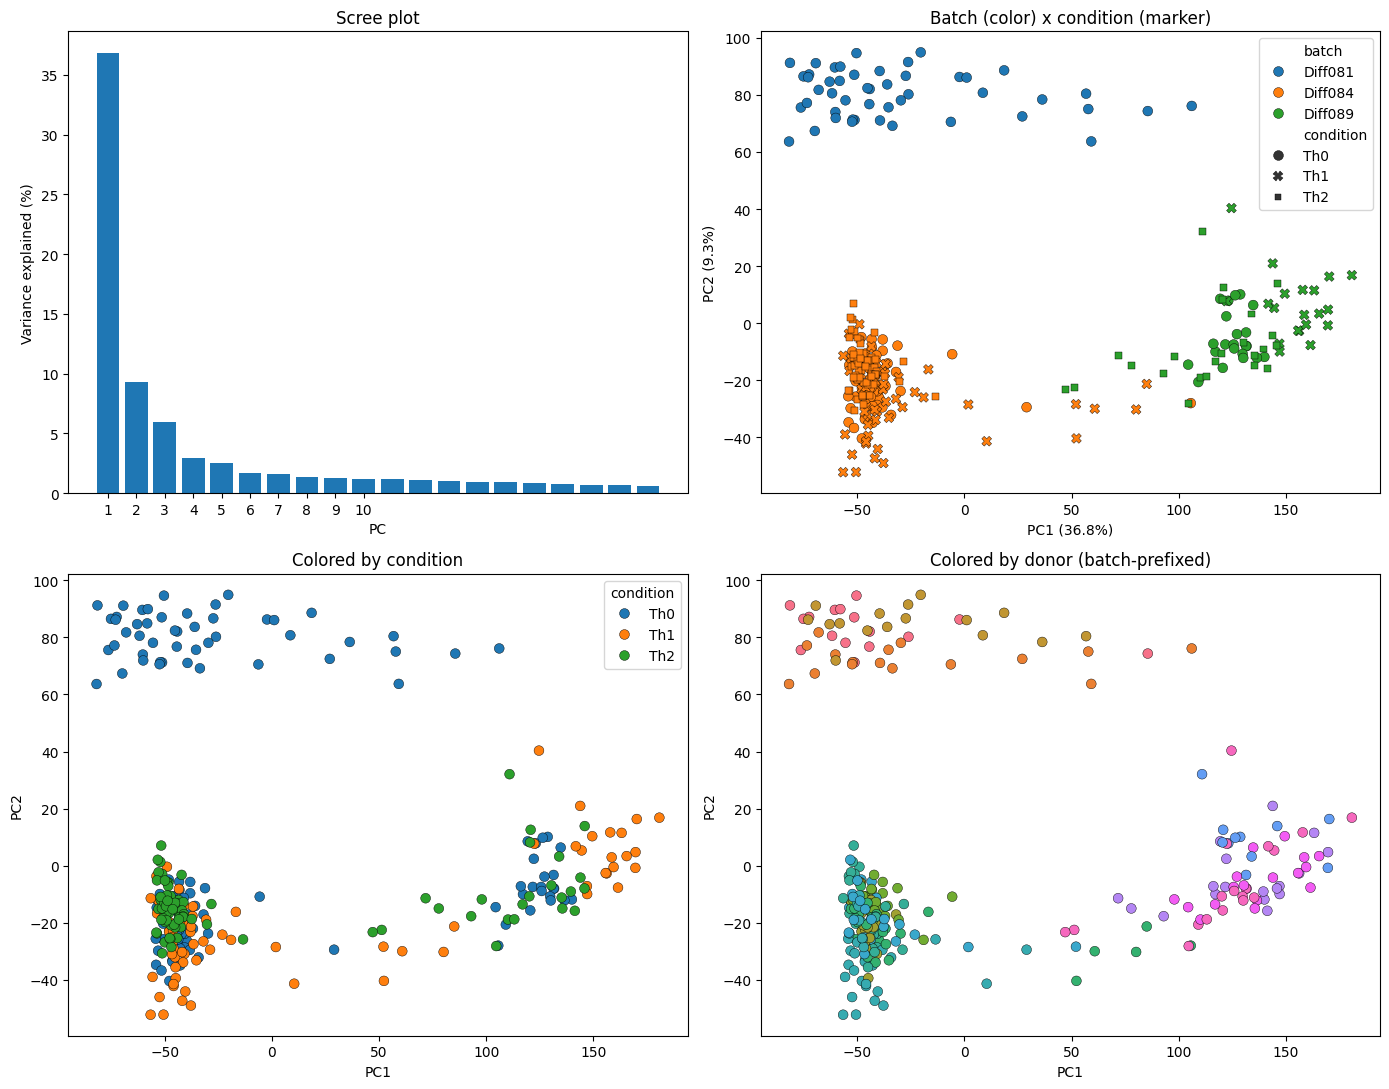

In [38]:
# Diagnostic plots: PC1/PC2 colored by batch / condition / donor / perturbation.
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

axes[0].bar(range(1, 21), pca.explained_variance_ratio_ * 100)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot'); axes[0].set_xticks(range(1, 11))

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='batch', style='condition',
                ax=axes[1], s=50, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Batch (color) x condition (marker)')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='condition',
                ax=axes[2], s=50, edgecolor='k', linewidth=0.3)
axes[2].set_title('Colored by condition')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='donor',
                ax=axes[3], s=50, edgecolor='k', linewidth=0.3, legend=False)
axes[3].set_title('Colored by donor (batch-prefixed)')

plt.tight_layout()

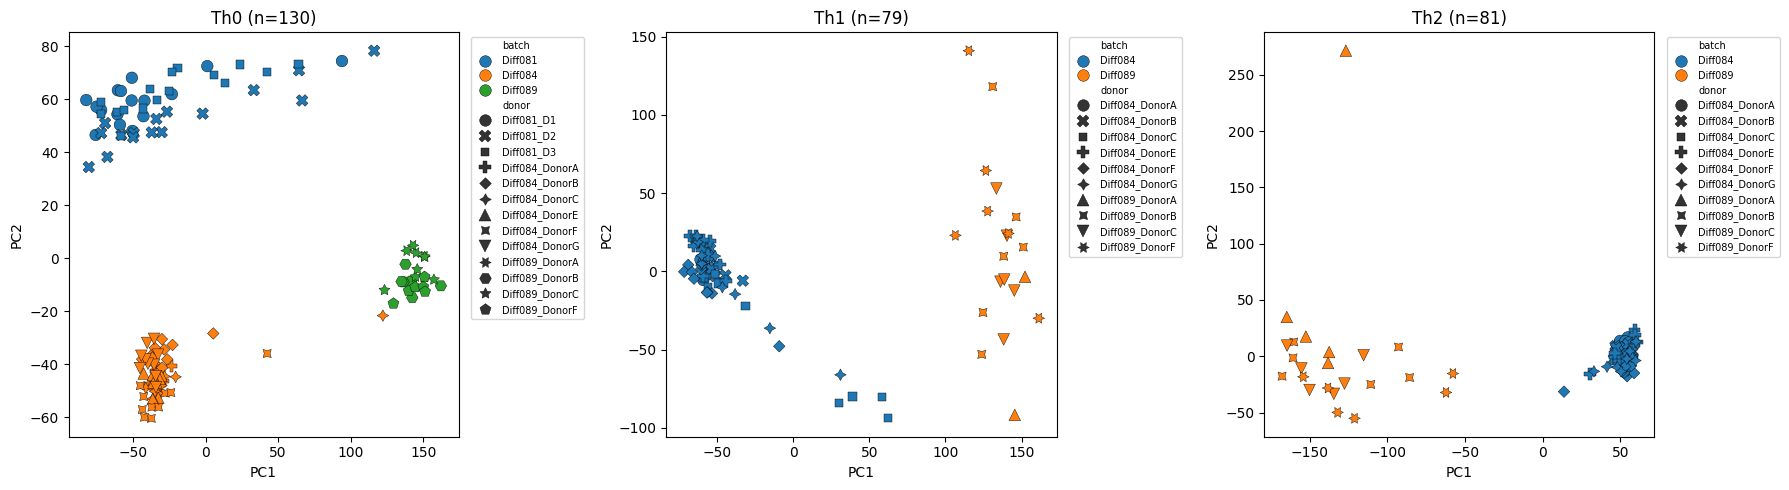

In [39]:
# PCA within each condition: do batches still separate after conditioning on condition?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cond in zip(axes, ['Th0','Th1','Th2']):
    sub_samples = sample_meta.loc[sample_meta['condition']==cond, 'full_sample_name'].values
    log_cpm_sub = log_cpm[sub_samples]
    keep = (log_cpm_sub.var(axis=1) > 0)
    X = StandardScaler().fit_transform(log_cpm_sub.loc[keep].T)
    pca_c = PCA(n_components=2).fit_transform(X)
    df = pd.DataFrame(pca_c, columns=['PC1','PC2'], index=sub_samples)
    df = df.merge(sample_meta.set_index('full_sample_name'),
                  left_index=True, right_index=True)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='batch', style='donor',
                    ax=ax, s=70, edgecolor='k', linewidth=0.3)
    ax.set_title(f'{cond} (n={len(sub_samples)})')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()

## §3 Joint DE analysis

Per-condition DESeq2 with all batches pooled. Design: `~ donor + PC1 + perturbation_group`. Donor is batch-prefixed, so the donor covariate captures batch differences as well as donor-to-donor variation. NTC is the reference level. Each contrast is `<perturbation> - NTC` within the condition.

Output: `bulkRNAseq_DESeq2_results.combined.csv`. Schema matches the previous combined table (`variable, gene_name, contrast, target_contrast_gene_name, condition, batch, baseMean, log_fc, lfcSE, stat, zscore, p_value, adj_p_value`) — `batch` lists which batch(es) each contrast pooled.

In [40]:
# Attach merged-PCA PC1 per sample (DE covariate)
sample_meta = sample_meta.set_index('full_sample_name')
sample_meta['PC1'] = pca_df['PC1']
sample_meta = sample_meta.reset_index()

def build_adata_cond(cond):
    sub = sample_meta[sample_meta['condition']==cond].copy()
    counts_sub = counts_pc[sub['full_sample_name'].values]
    gene_mask = counts_sub.sum(axis=1) >= 10
    counts_sub = counts_sub.loc[gene_mask]
    return sc.AnnData(
        X=np.round(counts_sub.T.values).astype(int),
        obs=sub.set_index('full_sample_name'),
        var=gene_annot.loc[counts_sub.index, ['gene_name']].copy(),
    )

adatas = {cond: build_adata_cond(cond) for cond in ['Th0','Th1','Th2']}
for cond, a in adatas.items():
    print(f"{cond}: {a.shape}  groups={a.obs['perturbation_group'].value_counts().to_dict()}")

Th0: (130, 17010)  groups={'NTC': 29, 'TBX21': 9, 'JAK2': 9, 'GATA3': 9, 'MED24': 7, 'KDM1A': 7, 'STAT6': 6, 'ZMYND8': 6, 'NKTR': 6, 'PPP1R7': 6, 'MAMLD1': 6, 'STYXL1': 6, 'APPBP2': 3, 'CDKAL1': 3, 'FAM120A': 3, 'FBXO32-3': 3, 'FBXO32': 3, 'MTA2': 3, 'PTPN2': 3, 'NAB2': 3}
Th1: (79, 16267)  groups={'NTC': 19, 'TBX21': 6, 'GATA3': 6, 'JAK2': 6, 'STYXL1': 6, 'MAMLD1': 6, 'NKTR': 6, 'ZMYND8': 6, 'PPP1R7': 5, 'MED24': 4, 'KDM1A': 3, 'STAT6': 3, 'NAB2': 3}
Th2: (81, 16350)  groups={'NTC': 20, 'TBX21': 6, 'GATA3': 6, 'JAK2': 6, 'MAMLD1': 6, 'NKTR': 6, 'ZMYND8': 6, 'STYXL1': 5, 'PPP1R7': 5, 'MED24': 4, 'KDM1A': 4, 'STAT6': 4, 'NAB2': 3}


In [41]:

# For each (target, condition) record which batches contributed samples — useful
# downstream to know whether a contrast is single-batch or pooled.
batches_per_target = (
    sample_meta.groupby(['condition', 'perturbation_group'])['batch']
    .agg(lambda s: ','.join(sorted(set(s)))).to_dict()
)

all_res = []
for cond, adata in adatas.items():
    print(f'\n=== Condition: {cond} ===')
    model = pertpy.tl.PyDESeq2(adata, design='~ donor + PC1 + perturbation_group')
    model.fit(n_cpus=3, quiet=True)

    targets = [t for t in adata.obs['perturbation_group'].unique() if t != 'NTC']
    contrasts = {
        t: (model.cond(perturbation_group=t) - model.cond(perturbation_group='NTC'))
        for t in targets
    }
    res = model.test_contrasts(contrasts)
    res['gene_name'] = res['variable'].map(adata.var['gene_name'].to_dict())
    res['condition'] = cond
    res['target_contrast_gene_name'] = res['contrast']
    res['zscore'] = res['log_fc'] / res['lfcSE']
    res['batch'] = res['contrast'].map(lambda t: batches_per_target.get((cond, t), ''))
    all_res.append(res)

res_df = pd.concat(all_res, ignore_index=True)
print(f'\nTotal DE rows: {len(res_df):,}')
res_df.head()


=== Condition: Th0 ===


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    2.6s
[Parallel(n_jobs=3)]: Done 17009 out of 17009 | elapsed:    6.2s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    4.8s
[Parallel(n_jobs=3)]: Done 17009 out of 17009 | elapsed:   12.6s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    3.1s
[Parallel(n_jobs=3)]: Done 17009 out of 17009 | elapsed:    9.1s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    2.3s
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/pydeseq2/utils.py:380: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/emmadann/miniforge3/envs/

Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  1.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    6.704218        0.035622  0.506195  0.070372  0.943898   
ENSG00000000419  970.011163       -0.007395  0.045949 -0.160949  0.872134   
ENSG00000000457  105.615312       -0.020636  0.064737 -0.318761  0.749908   
ENSG00000000460   62.458817       -0.071269  0.075560 -0.943216  0.345570   
ENSG00000000938    1.001664       -0.545594  0.532272 -1.025029  0.305350   
...                     ...             ...       ...       ...       ...   
ERCC-00096         6.217735       -0.566925  1.067438 -0.531108  0.595344   
ERCC-00113         1.215916       -0.187453  2.995764 -0.062573  0.950107   
ERCC-00130         6.570244        0.465

Running Wald tests...
... done in 0.95 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  1.  0.  0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  0.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    6.704218        0.825139  0.458494  1.799673  0.071912   
ENSG00000000419  970.011163       -0.000861  0.045521 -0.018908  0.984915   
ENSG00000000457  105.615312        0.065641  0.063674  1.030891  0.302592   
ENSG00000000460   62.458817        0.023796  0.075009  0.317238  0.751063   
ENSG00000000938    1.001664        0.498487  0.458000  1.088401  0.276418   
...                     ...             ...       ...       ...       ...   
ERCC-00096         6.217735       -0.022964  1.020372 -0.022505  0.982045   
ERCC-00113         1.215916       -0.301904  2.994002 -0.100836  0.919681   
ERCC-00130         6.570244        0.276

...

... done in 0.95 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -1.
  0.  1.  0.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    5.529343       -0.084691  0.603874 -0.140245  0.888466   
ENSG00000000419  792.190498       -0.087933  0.082421 -1.066876  0.286028   
ENSG00000000457   80.101247        0.171754  0.162671  1.055838  0.291042   
ENSG00000000460   55.562503       -0.342300  0.285199 -1.200214  0.230056   
ENSG00000000938    0.448956        0.559425  1.823444  0.306796  0.758999   
...                     ...             ...       ...       ...       ...   
ERCC-00111         0.415851        1.049843  8.052649  0.130372  0.896272   
ERCC-00113         3.831516        0.862373  0.767103  1.124195  0.260930   
ERCC-00130        16.130225        0.281685  0.465842  0.604680  0.545392   
ERC

... done in 1.00 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. -1.
  0.  0.  0.  0.  0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    5.529343        0.132322  0.659358  0.200683  0.840946   
ENSG00000000419  792.190498       -0.007340  0.089648 -0.081879  0.934743   
ENSG00000000457   80.101247       -0.145761  0.196008 -0.743644  0.457092   
ENSG00000000460   55.562503        0.298401  0.302937  0.985029  0.324610   
ENSG00000000938    0.448956        1.362914  1.810768  0.752671  0.451647   
...                     ...             ...       ...       ...       ...   
ERCC-00111         0.415851       -1.445824  9.201800 -0.157124  0.875147   
ERCC-00113         3.831516        0.129321  0.921567  0.140327  0.888401   
ERCC-00130        16.130225       -0.198637  0.531226 -0.373922  0.708463   
ERC

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,gene_name,condition,target_contrast_gene_name,zscore,batch
0,ENSG00000186810,230.481196,-1.497004,0.075341,-19.869603,7.459072e-88,9.489432e-84,TBX21,CXCR3,Th0,TBX21,-19.869603,"Diff081,Diff084"
1,ENSG00000073861,382.218110,-3.034060,0.155001,-19.574431,2.554714e-85,1.625054e-81,TBX21,TBX21,Th0,TBX21,-19.574431,"Diff081,Diff084"
2,ENSG00000159128,56.958135,1.699342,0.102995,16.499310,3.711072e-61,1.573742e-57,TBX21,IFNGR2,Th0,TBX21,16.499310,"Diff081,Diff084"
3,ENSG00000164691,747.621157,-0.991867,0.087345,-11.355765,6.942911e-30,2.208193e-26,TBX21,TAGAP,Th0,TBX21,-11.355765,"Diff081,Diff084"
4,ENSG00000198933,47.990753,1.066140,0.112286,9.494892,2.204406e-21,5.608890e-18,TBX21,TBKBP1,Th0,TBX21,9.494892,"Diff081,Diff084"


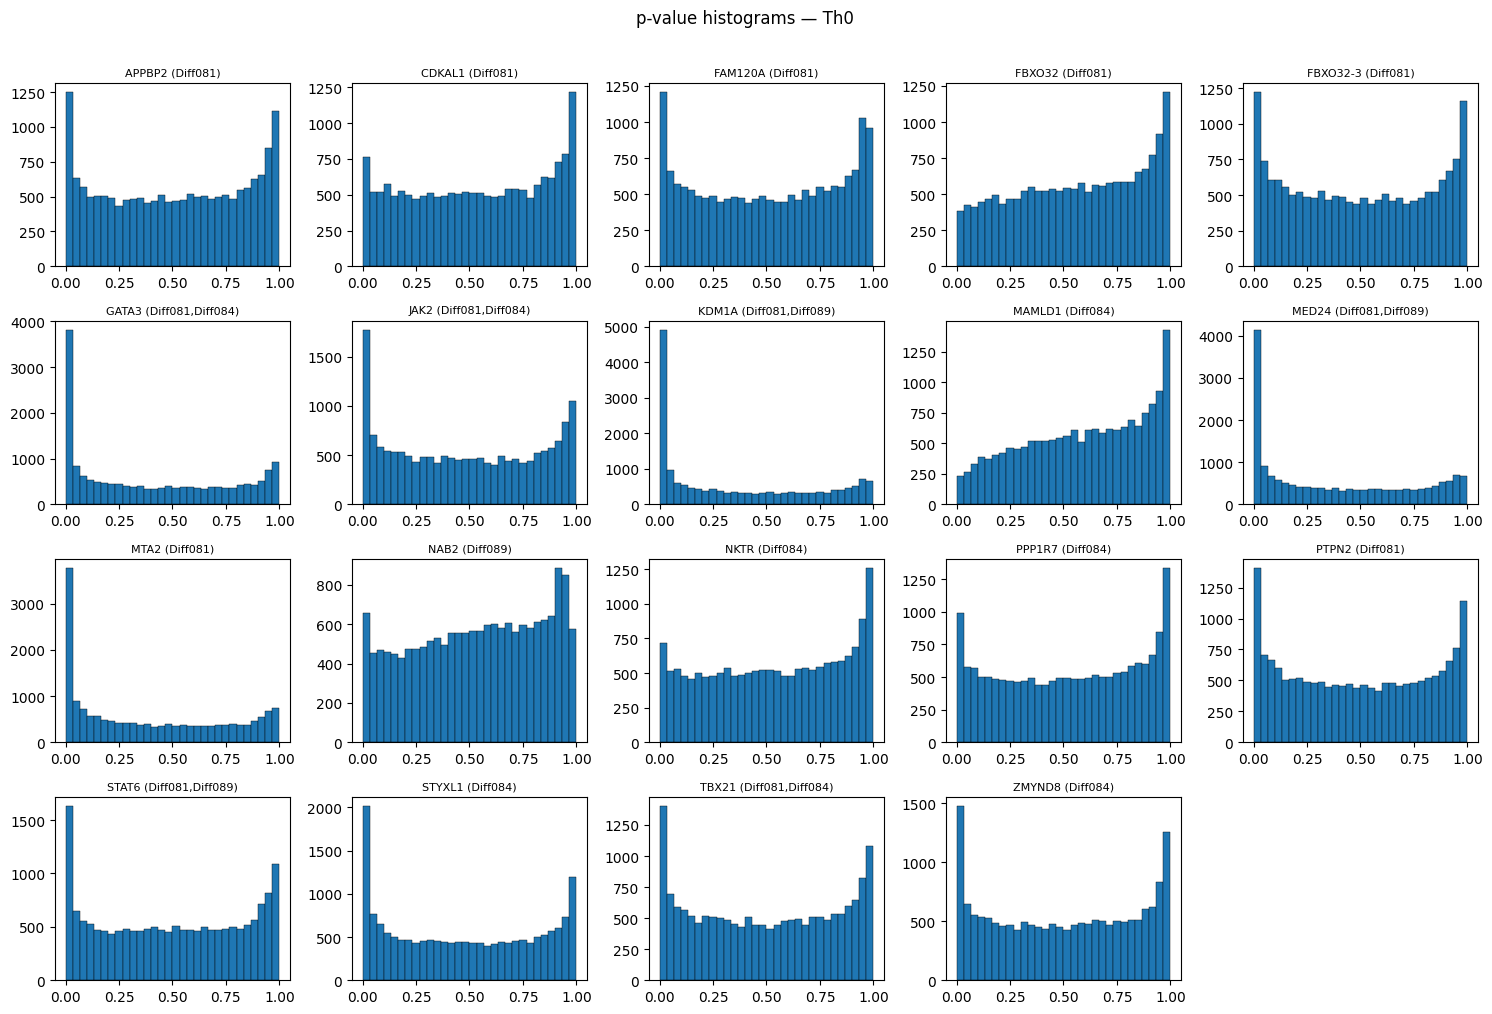

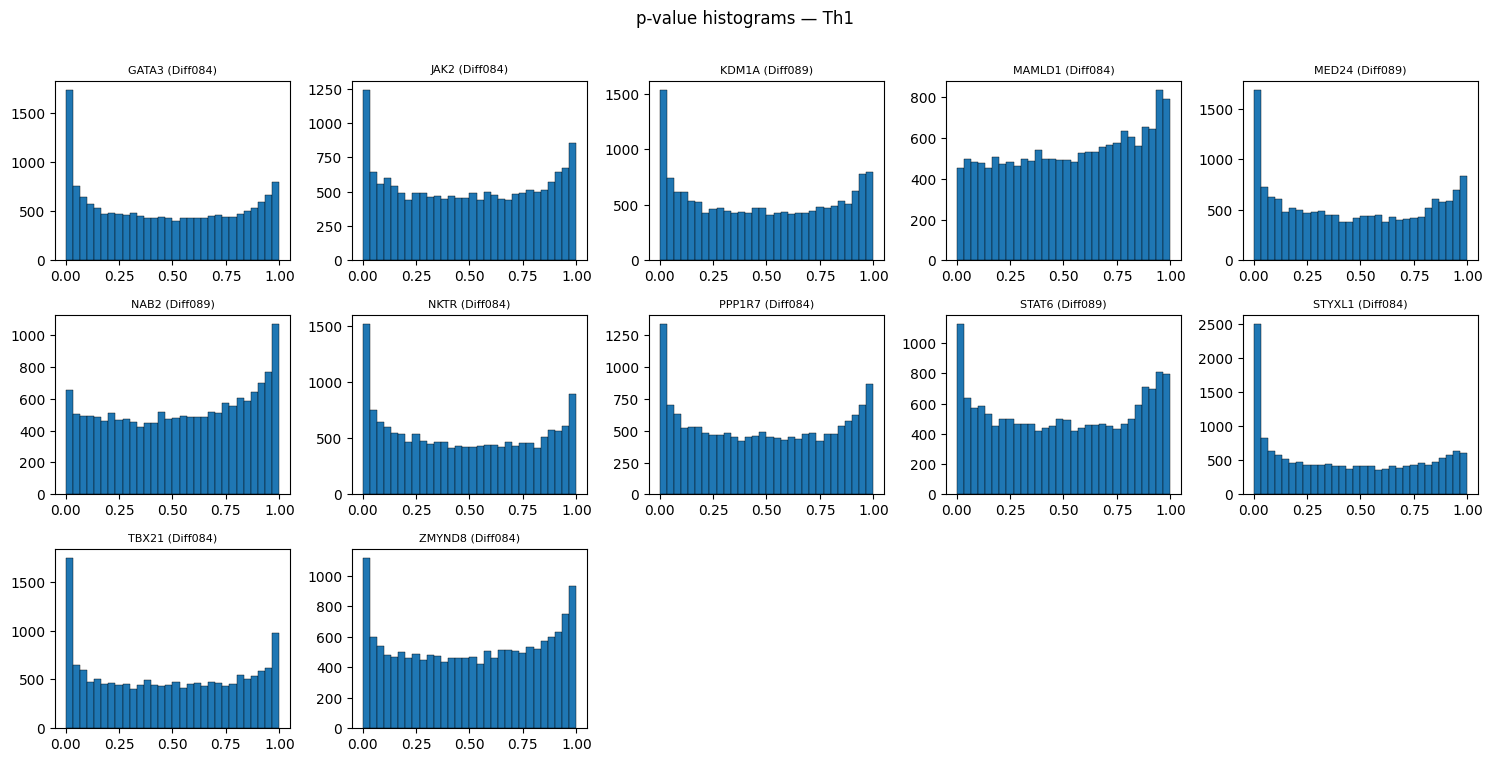

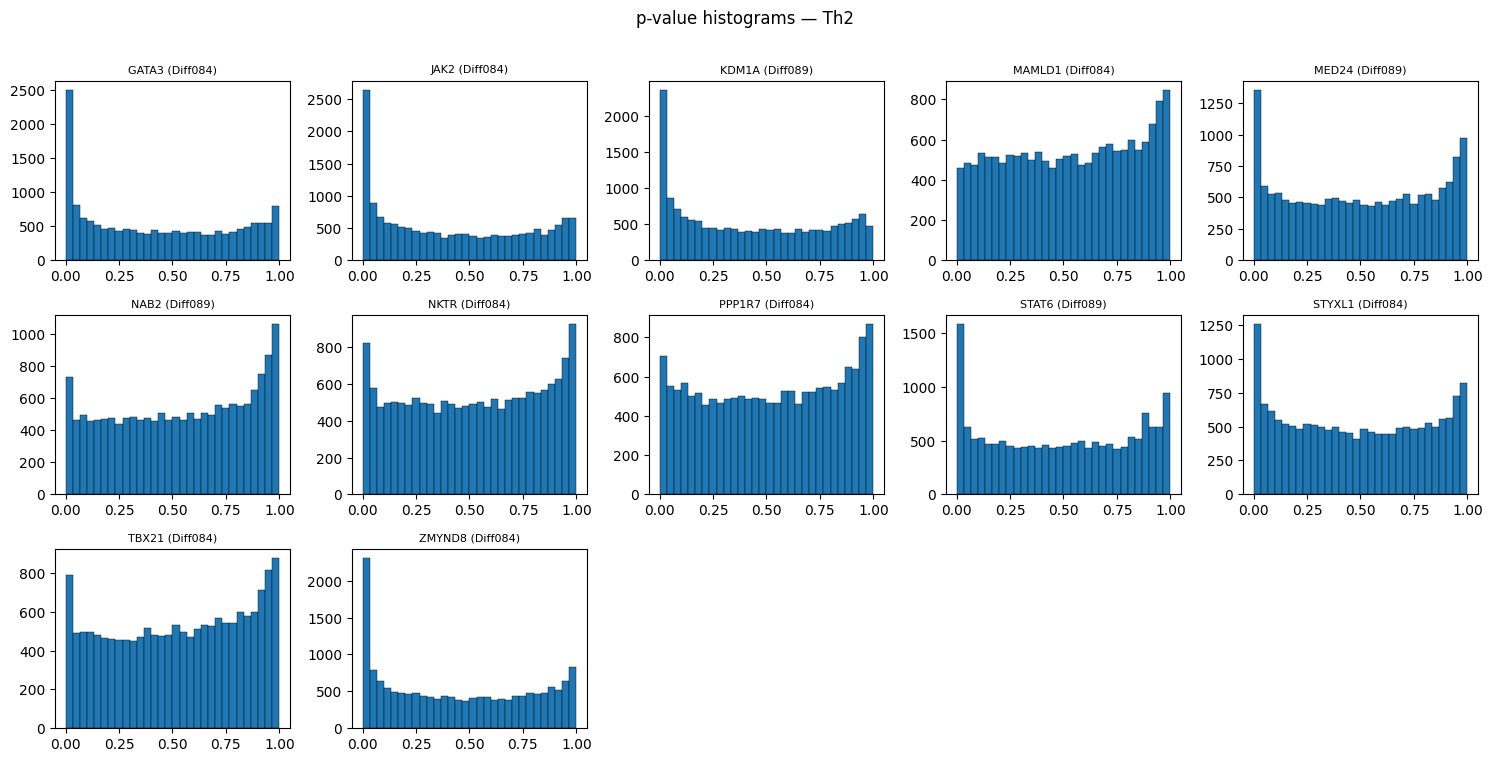

In [42]:
# Sanity: p-value histograms per condition (one panel per contrast).
for cond in ['Th0','Th1','Th2']:
    sub = res_df[res_df['condition']==cond]
    targets = sorted(sub['contrast'].unique())
    n_cols = 5; n_rows = int(np.ceil(len(targets)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, t in enumerate(targets):
        s = sub[sub['contrast']==t]
        axes[i].hist(s['p_value'].dropna(), bins=30, edgecolor='k', linewidth=0.3)
        axes[i].set_title(f'{t} ({batches_per_target.get((cond, t), "")})', fontsize=8)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'p-value histograms — {cond}', y=1.01)
    plt.tight_layout(); plt.show()

In [43]:
# Sanity: on-target knockdown effects (where target gene is measured).
rows = []
for cond in ['Th0','Th1','Th2']:
    sub = res_df[res_df['condition']==cond]
    for t in sorted(sub['contrast'].unique()):
        on = sub[(sub['contrast']==t) & (sub['gene_name']==t)]
        if not on.empty:
            r = on.iloc[0]
            rows.append({'condition': cond, 'target': t,
                         'log_fc': r['log_fc'], 'adj_p_value': r['adj_p_value']})
on_target_df = pd.DataFrame(rows)
on_target_df.pivot(index='target', columns='condition', values='log_fc')

condition,Th0,Th1,Th2
target,,,
APPBP2,-4.352499,NaN,NaN
CDKAL1,-4.197103,NaN,NaN
FAM120A,-4.207994,NaN,NaN
FBXO32,-2.269379,NaN,NaN
GATA3,-1.338164,-1.184890,-0.826686
JAK2,-2.865689,-2.802850,-2.736651
KDM1A,-3.423470,-1.693160,-1.550480
MAMLD1,-3.003233,-3.223542,-2.073117
MED24,-3.184830,-1.320812,-1.404235


In [44]:
# DE-gene counts per perturbation per condition (padj < 0.05)
de_summary = (
    res_df.dropna(subset=['adj_p_value'])
    .groupby(['condition','contrast'])
    .apply(lambda x: pd.Series({
        'n_DE_genes': (x['adj_p_value'] < 0.05).sum(),
        'n_up':   ((x['adj_p_value'] < 0.05) & (x['log_fc'] > 0)).sum(),
        'n_down': ((x['adj_p_value'] < 0.05) & (x['log_fc'] < 0)).sum(),
    }))
    .astype(int)
)
de_summary

/tmp/ipykernel_2704581/3869066476.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


n_DE_genes  n_up  n_down
condition contrast                          
Th0       APPBP2           297   219      78
          CDKAL1            32     9      23
          FAM120A          175   146      29
          FBXO32            13     1      12
          FBXO32-3          92    15      77
          GATA3           2818  1569    1249
          JAK2             710   306     404
          KDM1A           3999  2686    1313
          MAMLD1             4     1       3
          MED24           3096  1559    1537
          MTA2            2460  1508     952
          NAB2              58    51       7
          NKTR              34    15      19
          PPP1R7            67    49      18
          PTPN2            206   132      74
          STAT6            655   393     262
          STYXL1           640   239     401
          TBX21            411   186     225
          ZMYND8           456   277     179
Th1       GATA3            592   289     303
          JAK2             294    85     209
          KDM1A            402   308      94
          MAMLD1             4     1       3
          MED24            541   365     176
          NAB2              27    19       8
          NKTR             174    81      93
          PPP1R7           185   122      63
          STAT6            174   101      73
          STYXL1          1311   637     674
          TBX21            786   459     327
          ZMYND8           197   115      82
Th2       GATA3           1322   675     647
          JAK2            1329   643     686
          KDM1A           1154   644     510
          MAMLD1             5     1       4
          MED24            418   321      97
          NAB2             100    81      19
          NKTR              49    31      18
          PPP1R7             1     0       1
          STAT6            700   447     253
          STYXL1           163    85      78
          TBX21             58    24      34
          ZMYND8          1104   606     498

In [45]:
# Save combined long-format DE table. Drops FBXO32-3 column; both FBXO32-2 and
# FBXO32-3 contrasts are kept (under 'FBXO32' and 'FBXO32-3').
cols = ['variable', 'gene_name', 'contrast', 'target_contrast_gene_name',
        'condition', 'batch',
        'baseMean', 'log_fc', 'lfcSE', 'stat', 'zscore',
        'p_value', 'adj_p_value']
combined = res_df[cols].copy()
combined.to_csv('results/bulkRNAseq_DESeq2_results.combined_v2.csv', index=False)
print(f'wrote results/bulkRNAseq_DESeq2_results.combined_v2.csv  shape={combined.shape}')
display(combined.groupby(['condition'])['contrast'].nunique().rename('n_contrasts'))
display(combined[['contrast','target_contrast_gene_name','condition','batch']].drop_duplicates().head(30))

wrote bulkRNAseq_DESeq2_results.combined_v2.csv  shape=(714594, 13)


condition
Th0    19
Th1    12
Th2    12
Name: n_contrasts, dtype: int64

,contrast,target_contrast_gene_name,condition,batch
0,TBX21,TBX21,Th0,"Diff081,Diff084"
17010,GATA3,GATA3,Th0,"Diff081,Diff084"
34020,MED24,MED24,Th0,"Diff081,Diff089"
51030,KDM1A,KDM1A,Th0,"Diff081,Diff089"
68040,PTPN2,PTPN2,Th0,Diff081
85050,JAK2,JAK2,Th0,"Diff081,Diff084"
102060,MTA2,MTA2,Th0,Diff081
119070,FBXO32,FBXO32,Th0,Diff081
136080,FBXO32-3,FBXO32-3,Th0,Diff081
153090,APPBP2,APPBP2,Th0,Diff081


In [ ]:
# Per-target follow-ups in §7-§9 (TBX21 / JAK2 compensation / FBXO32) historically
# used Diff081-only DE. After the joint refactor in §3, the joint table is the
# canonical source — for contrasts unique to Diff081 (FBXO32-3, MTA2, PTPN2,
# CDKAL1, FAM120A, APPBP2) the joint estimate equals the Diff081 estimate;
# for shared contrasts (TBX21, GATA3, JAK2, etc.) the joint estimate pools all batches.
res_df_diff081 = res_df[res_df['condition'] == 'Th0'].copy()
# 'contrast' is gene-level after harmonisation; expose it as target_contrast_gene_name too.
res_df_diff081['target_contrast_gene_name'] = res_df_diff081['contrast']
print(f'res_df_diff081: {res_df_diff081.shape}, contrasts: '
      f'{sorted(res_df_diff081["contrast"].unique())}')

## §4 Polarization NTC-only DE (all batches)

Th1 vs Th0 and Th2 vs Th0 using NTC samples from all batches — defines the bulk-derived polarization signatures used downstream. Th1/Th2 NTC samples come from Diff084 + Diff089; Th0 NTC samples come from Diff081 + Diff084 + Diff089.

In [46]:
# DE analysis between conditions using NTC-only samples
ntc_mask = sample_meta['perturbation_group'] == 'NTC'
ntc_meta = sample_meta[ntc_mask].copy()
ntc_counts = counts_pc[ntc_meta['full_sample_name'].values]

# Filter lowly expressed genes
gene_mask = ntc_counts.sum(axis=1) >= 10
ntc_counts = ntc_counts.loc[gene_mask]

adata_cond = sc.AnnData(
    X=np.round(ntc_counts.T.values).astype(int),
    obs=ntc_meta.set_index('full_sample_name'),
    var=gene_annot.loc[ntc_counts.index, ['gene_name']].copy(),
)
print(f"NTC adata: {adata_cond.shape}")
print(adata_cond.obs[['condition','donor']].value_counts().unstack(fill_value=0))

NTC adata: (68, 16373)
donor      Diff081_D1  Diff081_D2  Diff081_D3  Diff084_DonorA  Diff084_DonorB  \
condition                                                                       
Th0                 3           3           3               2               2   
Th1                 0           0           0               2               2   
Th2                 0           0           0               2               2   

donor      Diff084_DonorC  Diff084_DonorE  Diff084_DonorF  Diff084_DonorG  \
condition                                                                   
Th0                     2               2               2               2   
Th1                     2               2               2               2   
Th2                     2               2               2               2   

donor      Diff089_DonorA  Diff089_DonorB  Diff089_DonorC  Diff089_DonorF  
condition                                                                  
Th0                     2        

In [47]:
# Fit DESeq2 on NTC samples with condition as factor
model_cond = pertpy.tl.PyDESeq2(adata_cond, design="~ donor + PC1 + condition")
model_cond.fit(n_cpus=3, quiet=True)

# Test Th1 vs Th0 and Th2 vs Th0
contrasts_cond = {
    'Th1_vs_Th0': (model_cond.cond(condition='Th1') - model_cond.cond(condition='Th0')),
    'Th2_vs_Th0': (model_cond.cond(condition='Th2') - model_cond.cond(condition='Th0')),
}
res_cond = model_cond.test_contrasts(contrasts_cond)
res_cond['gene_name'] = res_cond['variable'].map(adata_cond.var['gene_name'].to_dict())
res_cond['zscore'] = res_cond['log_fc'] / res_cond['lfcSE']

print(res_cond.groupby('contrast').apply(
    lambda x: pd.Series({
        'n_sig_padj<0.05': (x['adj_p_value'] < 0.05).sum(),
        'n_up': ((x['adj_p_value'] < 0.05) & (x['log_fc'] > 0)).sum(),
        'n_down': ((x['adj_p_value'] < 0.05) & (x['log_fc'] < 0)).sum(),
    })
))

res_cond.to_csv('results/Diff084_polarization_DE_NTC_vs_Th0.csv', index=False)
res_cond.head()

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    2.7s
[Parallel(n_jobs=3)]: Done 16373 out of 16373 | elapsed:    5.4s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    2.5s
[Parallel(n_jobs=3)]: Done 16373 out of 16373 | elapsed:    7.0s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    2.1s
[Parallel(n_jobs=3)]: Done 16373 out of 16373 | elapsed:    6.0s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done 5638 tasks      | elapsed:    1.2s
[Parallel(n_jobs=3)]: Done 16373 out of 16373 | elapsed:    3.5s finished
Running Wald tests...
... done in 3.97 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                     
ENSG00000000003    7.085076       -0.529020  0.490292 -1.078990  0.280592   
ENSG00000000419  802.345934       -0.111909  0.050753 -2.204964  0.027457   
ENSG00000000457   86.122005       -0.106456  0.075679 -1.406678  0.159523   
ENSG00000000460   45.467732        0.034684  0.080029  0.433398  0.664725   
ENSG00000000938    0.635025       -1.332456  0.659220 -2.021261  0.043253   
...                     ...             ...       ...       ...       ...   
ERCC-00111         0.612579        0.639693  4.160999  0.153735  0.877818   
ERCC-00113         3.089977        1.058355  0.993136  1.065670  0.286573   
ERCC-00130        21.634266        1.727124  0.552022  3.128724  0.001756   
ERCC-00136         1.706842        1.418233  1.3

... done in 0.94 seconds.

/tmp/ipykernel_2704581/1061034343.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(res_cond.groupby('contrast').apply(


Log2 fold change & Wald test p-value, contrast vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
                   baseMean  log2FoldChange     lfcSE      stat        pvalue  \
gene_id                                                                         
ENSG00000000003    7.085076        0.201024  0.435343  0.461761  6.442529e-01   
ENSG00000000419  802.345934       -0.122712  0.047828 -2.565708  1.029653e-02   
ENSG00000000457   86.122005       -0.226282  0.073127 -3.094362  1.972365e-03   
ENSG00000000460   45.467732        0.475241  0.074220  6.403147  1.522066e-10   
ENSG00000000938    0.635025       -1.285191  0.621896 -2.066568  3.877483e-02   
...                     ...             ...       ...       ...           ...   
ERCC-00111         0.612579        0.382231  3.921028  0.097482  9.223435e-01   
ERCC-00113         3.089977        1.009418  0.898433  1.123531  2.612120e-01   
ERCC-00130        21.634266        1.008308  0.497677  2.026031  4.276161e-02   
ERCC

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast,gene_name,zscore
0,ENSG00000154229,441.288953,-0.836647,0.057955,-14.436179,3.063623e-47,4.335333e-43,Th1_vs_Th0,PRKCA,-14.436179
1,ENSG00000111537,4402.431579,2.768534,0.219469,12.614693,1.752395e-36,1.239907e-32,Th1_vs_Th0,IFNG,12.614693
2,ENSG00000143641,315.005784,0.469147,0.038644,12.140320,6.457301e-34,3.045909e-30,Th1_vs_Th0,GALNT2,12.140320
3,ENSG00000150977,765.094987,0.540795,0.044789,12.074354,1.442936e-33,5.104746e-30,Th1_vs_Th0,RILPL2,12.074354
4,ENSG00000276070,75.549499,2.616211,0.233976,11.181536,5.021319e-29,1.421134e-25,Th1_vs_Th0,CCL4L2,11.181536


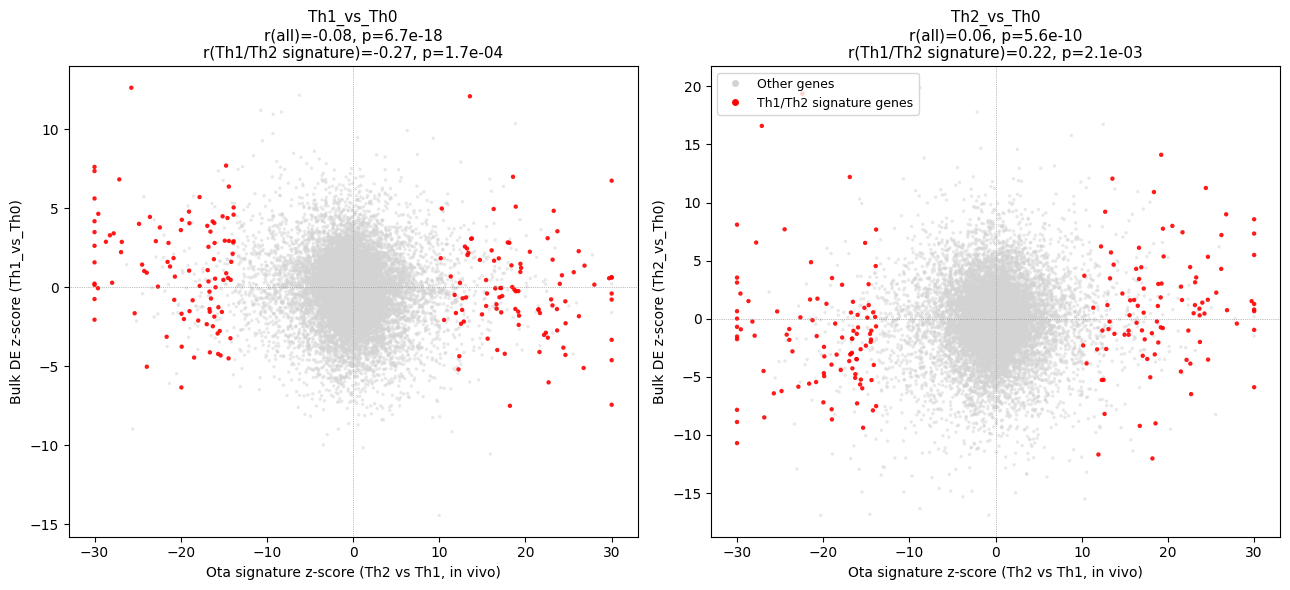

In [48]:
# Compare Th1 vs Th0 and Th2 vs Th0 DE signatures to the Ota Th2/Th1 in-vivo signature
from scipy.stats import pearsonr

# Load ota signature locally (also loaded later in the signature comparison section)
_ota = pd.read_csv('results/Ota_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
_ota.loc[_ota['zscore'] > 30, 'zscore'] = 30
_ota.loc[_ota['zscore'] < -30, 'zscore'] = -30

# Load hollbacher for the signature-gene intersection
_hol = pd.read_csv('results/hollbacher_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
_sig_ota = _ota.reset_index()[_ota.reset_index()['adj_p_value'] < 0.01]['variable'].tolist()
_sig_hol = _hol.reset_index()[_hol.reset_index()['adj_p_value'] < 0.01]['variable'].tolist()
_both = set(_sig_ota) & set(_sig_hol)
_sig_genes_set = set(_ota.loc[list(_both)].nlargest(100, 'zscore').index) | set(_ota.loc[list(_both)].nsmallest(100, 'zscore').index)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, contrast in zip(axes, ['Th1_vs_Th0', 'Th2_vs_Th0']):
    sub = res_cond[res_cond['contrast'] == contrast].copy()
    merged = sub.merge(
        _ota[['zscore']].rename(columns={'zscore': 'zscore_ota'}),
        left_on='gene_name', right_index=True, how='inner'
    ).dropna(subset=['zscore', 'zscore_ota'])
    merged['is_sig_gene'] = merged['gene_name'].isin(_sig_genes_set)

    r_all, p_all = pearsonr(merged['zscore'], merged['zscore_ota'])
    sig = merged[merged['is_sig_gene']]
    r_sig, p_sig = pearsonr(sig['zscore'], sig['zscore_ota']) if len(sig) > 2 else (np.nan, np.nan)

    other = merged[~merged['is_sig_gene']]
    ax.scatter(other['zscore_ota'], other['zscore'], c='lightgrey', s=6, alpha=0.5, edgecolor='none', zorder=1)
    ax.scatter(sig['zscore_ota'], sig['zscore'], c='red', s=10, edgecolor='none', alpha=0.9, zorder=2)
    ax.axhline(0, c='grey', ls=':', lw=0.5); ax.axvline(0, c='grey', ls=':', lw=0.5)
    ax.set_xlabel('Ota signature z-score (Th2 vs Th1, in vivo)')
    ax.set_ylabel(f'Bulk DE z-score ({contrast})')
    ax.set_title(f"{contrast}\nr(all)={r_all:.2f}, p={p_all:.1e}\nr(Th1/Th2 signature)={r_sig:.2f}, p={p_sig:.1e}",
                 fontsize=11)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey', markersize=6, label='Other genes'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Th1/Th2 signature genes'),
]
axes[-1].legend(handles=handles, loc='upper left', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

In [50]:
# Compare Th2 vs Th0 (NTC samples) with GATA3 knockdown effect in Th2 condition
from scipy.stats import pearsonr

th2_effect = res_cond[res_cond['contrast'] == 'Th1_vs_Th0'][['gene_name', 'zscore', 'adj_p_value']].rename(
    columns={'zscore': 'zscore_th2vs0', 'adj_p_value': 'padj_th2vs0'})
gata3_effect = res_df[(res_df['condition'] == 'Th1') & (res_df['contrast'] == 'TBX21')][
    ['gene_name', 'zscore', 'adj_p_value']].rename(
    columns={'zscore': 'zscore_gata3', 'adj_p_value': 'padj_gata3'})

cmp = pd.merge(th2_effect, gata3_effect, on='gene_name').dropna()

# Flag signature genes if available
# sig_set = set(signature_gs_up + signature_gs_down) if 'signature_gs_up' in globals() else set()
cmp['is_sig'] = cmp['gene_name'].isin(sig_set)

r_all, p_all = pearsonr(cmp['zscore_th2vs0'], cmp['zscore_gata3'])
# sig = cmp[cmp['is_sig']]
# r_sig, p_sig = pearsonr(sig['zscore_th2vs0'], sig['zscore_gata3']) if len(sig) > 2 else (np.nan, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
other = cmp[~cmp['is_sig']]
ax.scatter(other['zscore_th2vs0'], other['zscore_gata3'],
           c='grey', s=6, alpha=0.5, edgecolor='none', zorder=1)
# ax.scatter(sig['zscore_th2vs0'], sig['zscore_gata3'],
#            c='red', s=10, alpha=0.9, edgecolor='none', zorder=2)
ax.axhline(0, c='grey', ls=':', lw=0.5)
ax.axvline(0, c='grey', ls=':', lw=0.5)
ax.set_xlabel('Th1 vs Th0 z-score (NTC)')
ax.set_ylabel('TBX21 KD z-score (Th2 condition)')
ax.set_title(f"Th1 polarization vs GATA3 KD effect (Th2)\n"
             f"r(all)={r_all:.2f}, p={p_all:.1e}\n",
            #  f"r(Th1/Th2 signature)={r_sig:.2f}, p={p_sig:.1e}", 
            fontsize=11)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightgrey', markersize=6, label='Other genes'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Th1/Th2 signature genes'),
], loc='best', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()

NameError: name 'sig_set' is not defined

## §5 Compare to perturb-seq effects

Bulk DE z-scores vs single-cell perturb-seq z-scores per (target, condition).

In [3]:
res_df = pd.read_csv('results/bulkRNAseq_DESeq2_results.combined_v2.csv')
res_df['zscore'] = res_df['log_fc'] / res_df['lfcSE']
res_df['target_contrast_gene_name'].unique()

array(['TBX21', 'GATA3', 'MED24', 'KDM1A', 'PTPN2', 'JAK2', 'MTA2',
       'FBXO32', 'FBXO32-3', 'APPBP2', 'FAM120A', 'CDKAL1', 'STAT6',
       'STYXL1', 'MAMLD1', 'PPP1R7', 'NKTR', 'ZMYND8', 'NAB2'],
      dtype=object)

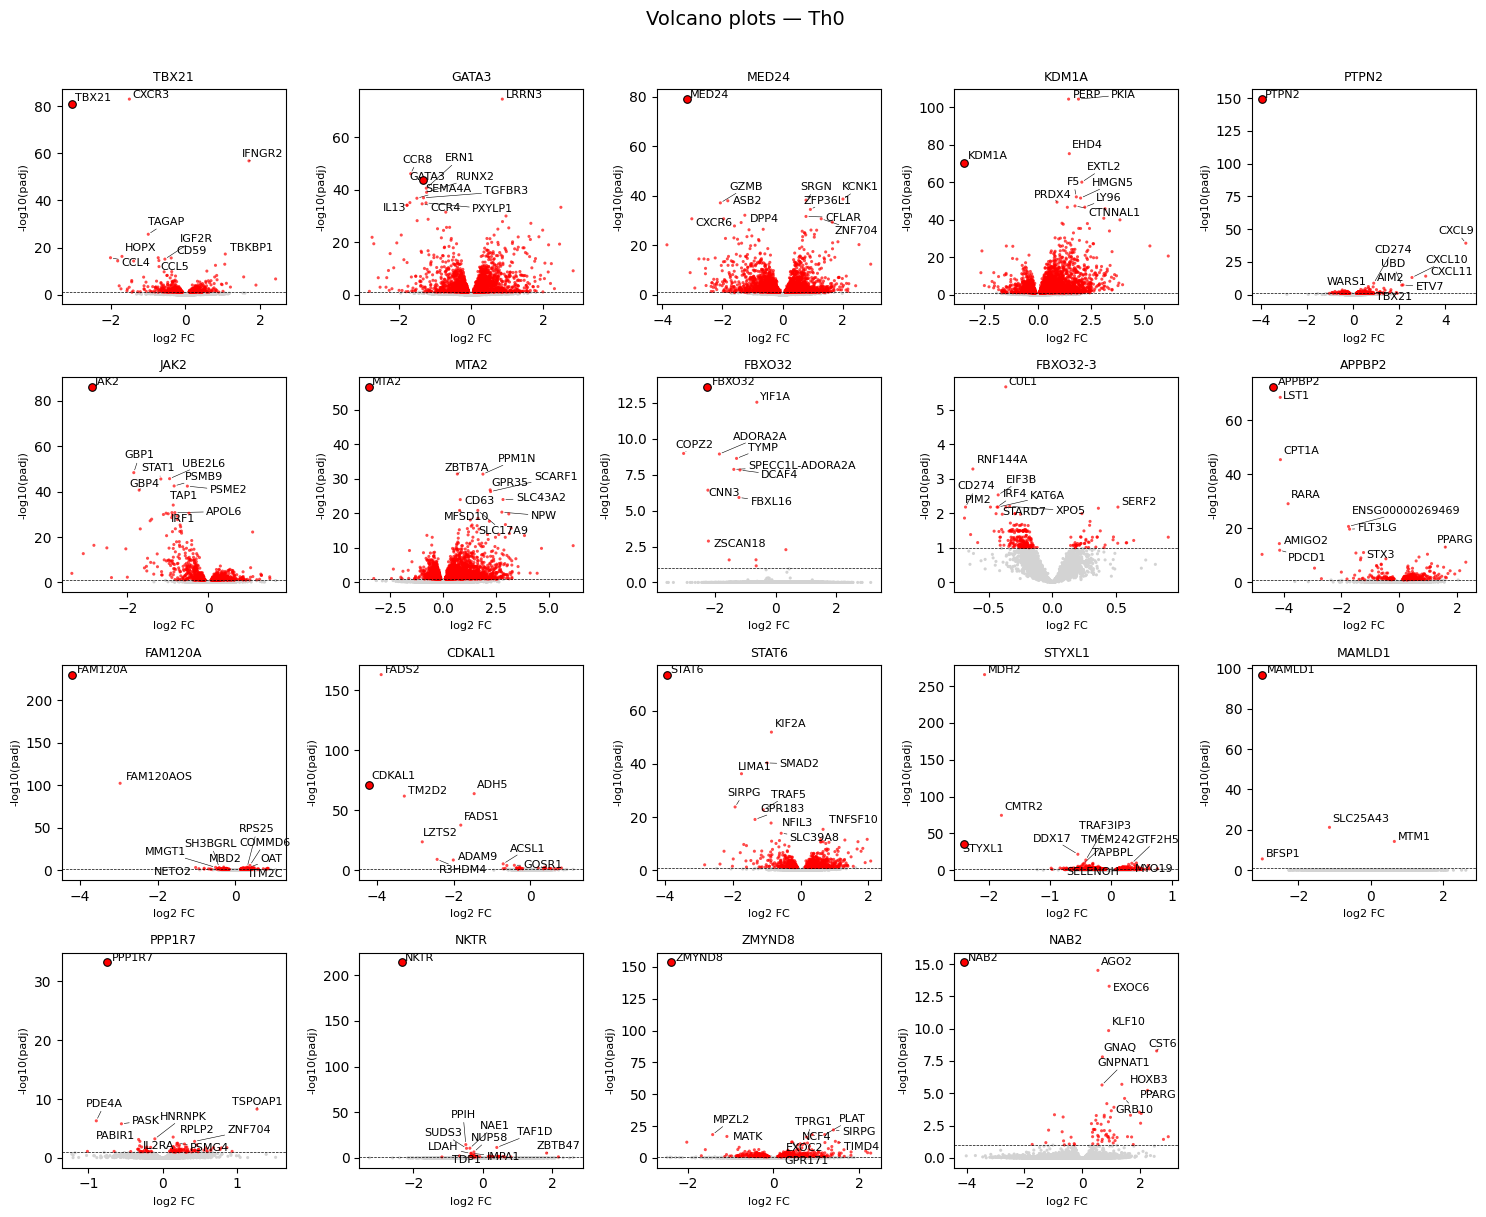

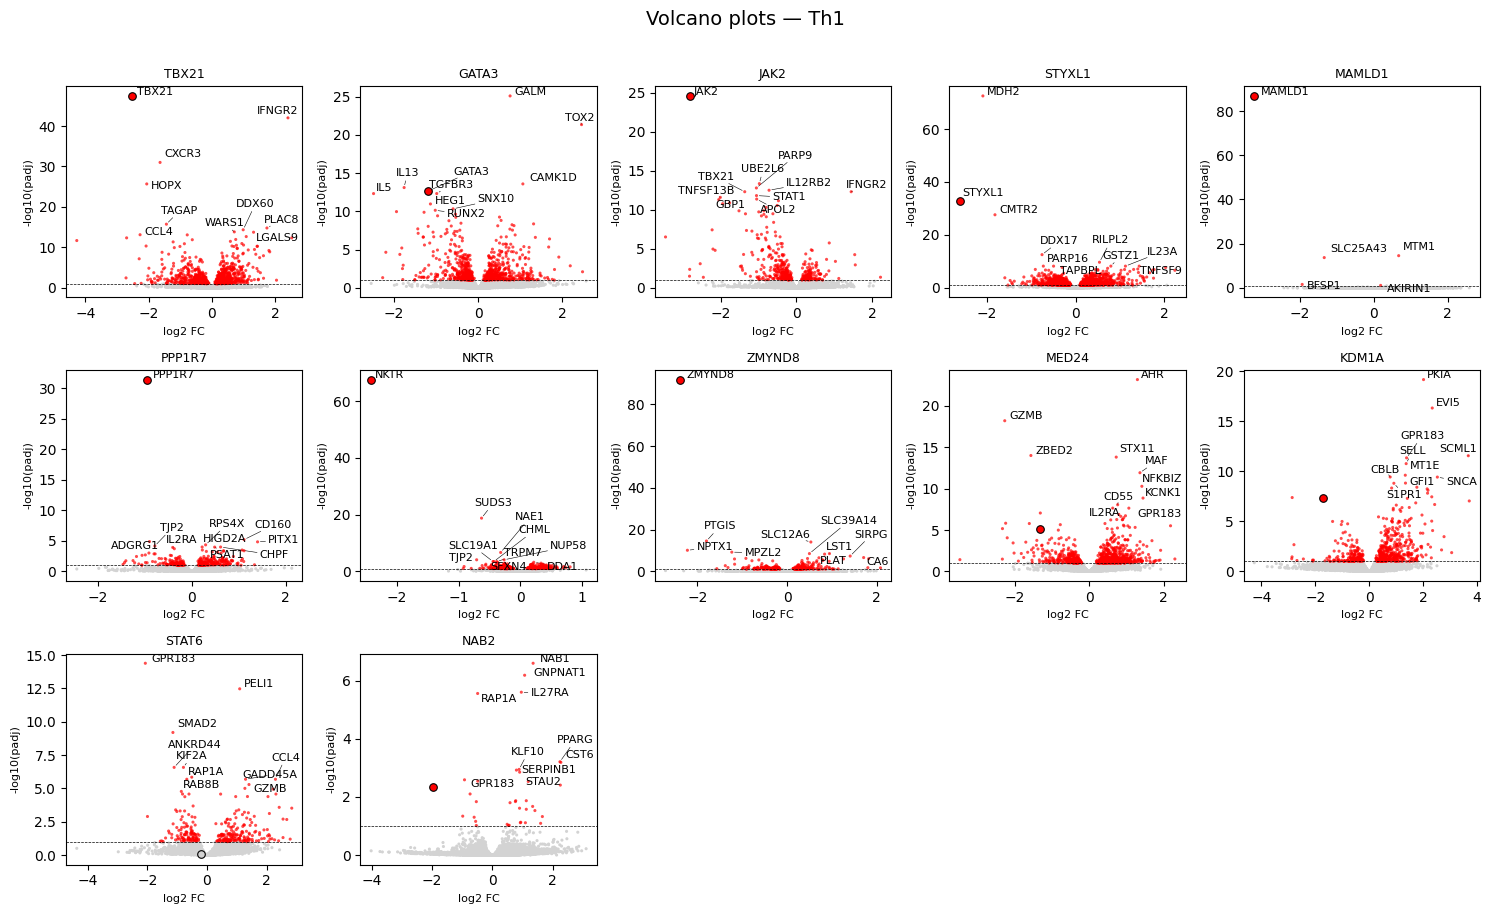

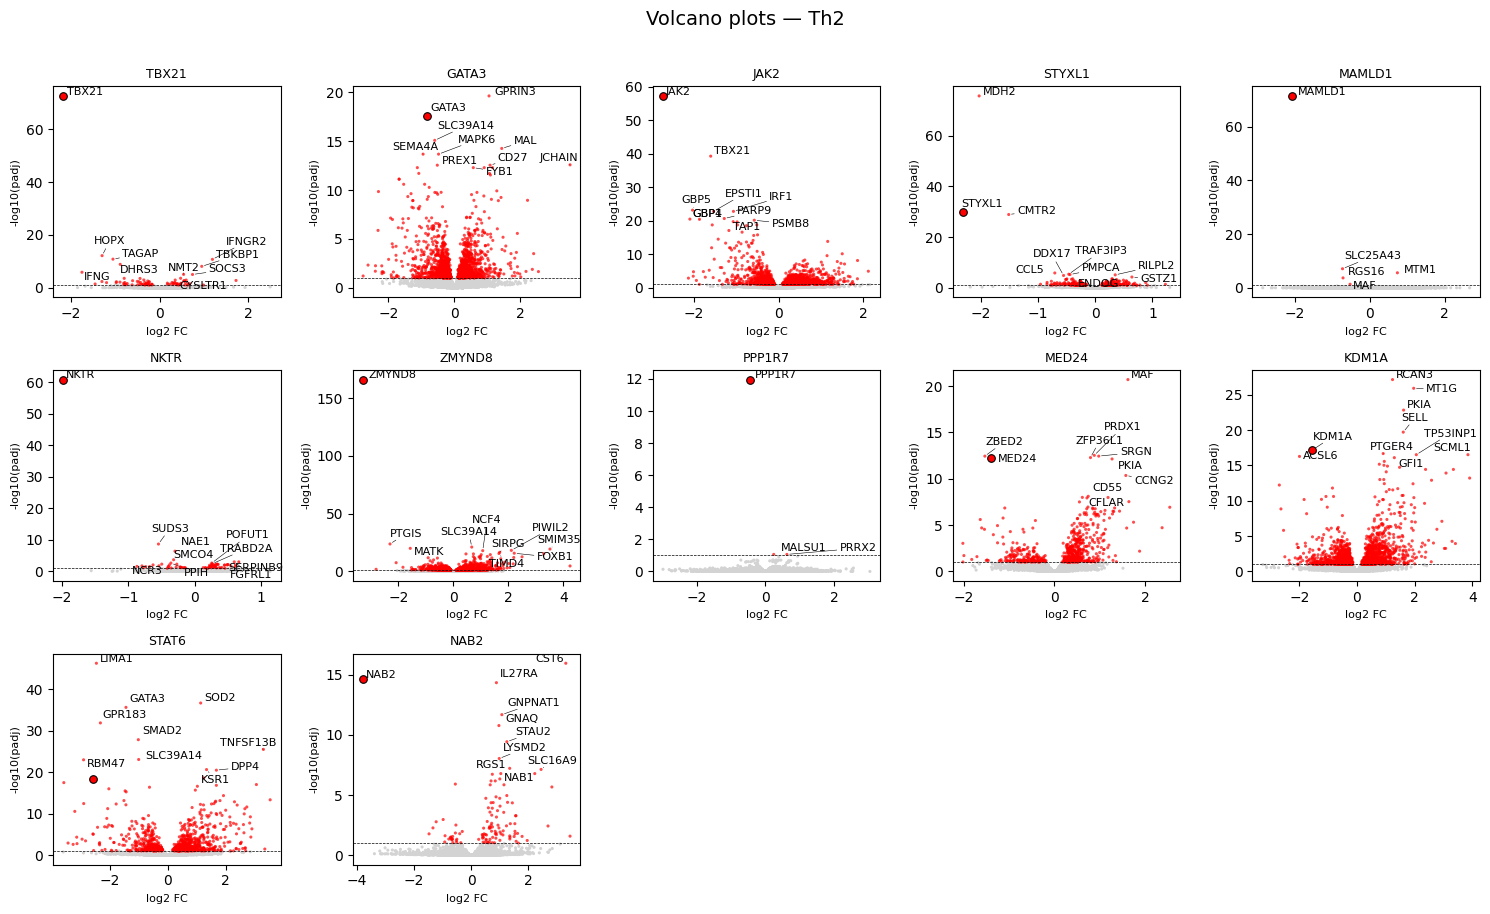

In [4]:
from adjustText import adjust_text

sig_threshold = 0.1
n_top_labels = 10

for cond in ['Th0','Th1','Th2']:
    sub = res_df[res_df['condition']==cond]
    contrasts = sub['contrast'].unique()
    n_cols = 5
    n_rows = int(np.ceil(len(contrasts)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten()
    for ax, contrast in zip(axes, contrasts):
        df = sub[sub['contrast']==contrast].copy().dropna(subset=['adj_p_value','log_fc','gene_name'])
        df['-log10_padj'] = -np.log10(df['adj_p_value'].clip(lower=1e-300))
        target_name = df['target_contrast_gene_name'].iloc[0]
        sig = df['adj_p_value'] < sig_threshold
        target_mask = df['gene_name'] == target_name
        ax.scatter(df.loc[~sig, 'log_fc'], df.loc[~sig, '-log10_padj'],
                   color='lightgray', s=5, edgecolor='none', rasterized=True, zorder=1)
        ax.scatter(df.loc[sig & ~target_mask, 'log_fc'], df.loc[sig & ~target_mask, '-log10_padj'],
                   color='red', alpha=0.7, s=5, edgecolor='none', rasterized=True, zorder=2)
        ax.scatter(df.loc[target_mask, 'log_fc'], df.loc[target_mask, '-log10_padj'],
                   color='red' if sig[target_mask].any() else 'lightgray', s=30, edgecolor='black', linewidth=0.8, zorder=4)
        top_sig = df[sig].nsmallest(n_top_labels, 'adj_p_value')
        texts = [ax.text(r['log_fc'], r['-log10_padj'], r['gene_name'], fontsize=8) for _, r in top_sig.iterrows()]
        if texts:
            adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.4))
        ax.axhline(-np.log10(sig_threshold), color='black', linestyle='--', linewidth=0.5)
        ax.set_title(f"{contrast}", fontsize=9)
        ax.set_xlabel('log2 FC', fontsize=8)
        ax.set_ylabel('-log10(padj)', fontsize=8)
    for ax in axes[len(contrasts):]:
        ax.set_visible(False)
    fig.suptitle(f"Volcano plots — {cond}", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()

In [5]:
# Load perturb-seq DE results and make long format
adata_de = anndata.read_h5ad('/mnt/oak/users/emma/data/GWT/CD4i_final/DE_results_all_confounders/CD4i_final.merged_DE_results.h5ad')
adata_de.layers['zscore'] = adata_de.layers['log_fc']/adata_de.layers['lfcSE']

# Map each bulk condition to a perturb-seq culture_condition.
# Th0 -> Stim8hr (matching main analysis), Th1 -> Th1, Th2 -> Th2 (if available).
pseq_cond_map = {'Th0': 'Stim8hr', 'Th1': 'Stim8hr', 'Th2': 'Stim8hr'}
available_pseq_conds = set(adata_de.obs['culture_condition'].unique())
print("Available perturb-seq conditions:", available_pseq_conds)
for k, v in pseq_cond_map.items():
    print(f"  {k} -> {v} ({'present' if v in available_pseq_conds else 'MISSING'})")

Available perturb-seq conditions: {'Stim8hr', 'Rest', 'Stim48hr'}
  Th0 -> Stim8hr (present)
  Th1 -> Stim8hr (present)
  Th2 -> Stim8hr (present)


In [6]:
adata_de

AnnData object with n_obs × n_vars = 33986 × 13959
    obs: 'target_contrast_gene_name', 'culture_condition', 'target_contrast', 'chunk', 'n_cells_target'
    var: 'gene_ids', 'gene_name'
    layers: 'adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value', 'zscore'

In [7]:
targets = res_df['target_contrast_gene_name'].unique().tolist()

pseq_de_parts = []
for bulk_cond, pseq_cond in pseq_cond_map.items():
    if pseq_cond not in available_pseq_conds:
        print(f"Skipping {bulk_cond}: perturb-seq lacks culture_condition '{pseq_cond}'")
        continue
    sub = get_DE_results_long(
        adata_de[adata_de.obs['culture_condition'] == pseq_cond],
        targets=[t for t in targets if t in adata_de.var['gene_name'].values or True],
        effect_estimates=['log_fc', 'zscore'],
    )
    sub['condition'] = bulk_cond
    pseq_de_parts.append(sub)
pseq_de = pd.concat(pseq_de_parts, ignore_index=True)
pseq_de.head()

,index,gene,log_fc,zscore,adj_p_value,significant,gene_name,culture_condition,target_contrast,target_contrast_gene_name,condition
0,ENSG00000004487_Stim8hr,ENSG00000000003,0.074879,0.013941,NaN,False,TSPAN6,Stim8hr,ENSG00000004487,KDM1A,Th0
1,ENSG00000004487_Stim8hr,ENSG00000000419,0.111654,2.379925,0.084434,True,DPM1,Stim8hr,ENSG00000004487,KDM1A,Th0
2,ENSG00000004487_Stim8hr,ENSG00000000457,-0.154016,-1.284900,0.440620,False,SCYL3,Stim8hr,ENSG00000004487,KDM1A,Th0
3,ENSG00000004487_Stim8hr,ENSG00000000460,-0.024548,-0.232495,0.923916,False,C1orf112,Stim8hr,ENSG00000004487,KDM1A,Th0
4,ENSG00000004487_Stim8hr,ENSG00000000938,-0.339778,-0.218270,0.928703,False,FGR,Stim8hr,ENSG00000004487,KDM1A,Th0


In [8]:
# Bulk vs perturb-seq z-score scatter per contrast, per condition
sig_threshold = 0.1

all_res_plot = []
for cond in ['Th0','Th1','Th2']:
    pseq_sub = pseq_de[pseq_de['condition']==cond] if 'condition' in pseq_de.columns else pseq_de
    if pseq_sub.empty:
        continue
    bulk_res = res_df[res_df['condition']==cond][['contrast','gene_name','target_contrast_gene_name','zscore','adj_p_value']].rename(
        columns={'zscore':'zscore_bulk','adj_p_value':'adj_p_value_bulk'})
    ps_res = pseq_sub[['gene_name','target_contrast_gene_name','zscore','adj_p_value']].rename(
        columns={'zscore':'zscore_pseq','adj_p_value':'adj_p_value_pseq'})
    merged = pd.merge(bulk_res, ps_res, on=['gene_name','target_contrast_gene_name'])
    # merged = merged[merged['target_contrast_gene_name'] != merged['gene_name']]
    merged['condition'] = cond
    merged['sig_bulk'] = merged['adj_p_value_bulk'] < sig_threshold
    merged['sig_pseq'] = merged['adj_p_value_pseq'] < sig_threshold
    merged['sig_cat'] = 'NS'
    merged.loc[merged['sig_bulk'] | merged['sig_pseq'], 'sig_cat'] = 'one'
    merged.loc[merged['sig_bulk'] & merged['sig_pseq'], 'sig_cat'] = 'both'
    all_res_plot.append(merged)

all_res_df = pd.concat(all_res_plot, ignore_index=True) if all_res_plot else pd.DataFrame()
print(f"Total compared gene-pert rows: {len(all_res_df):,}")

Total compared gene-pert rows: 546,210


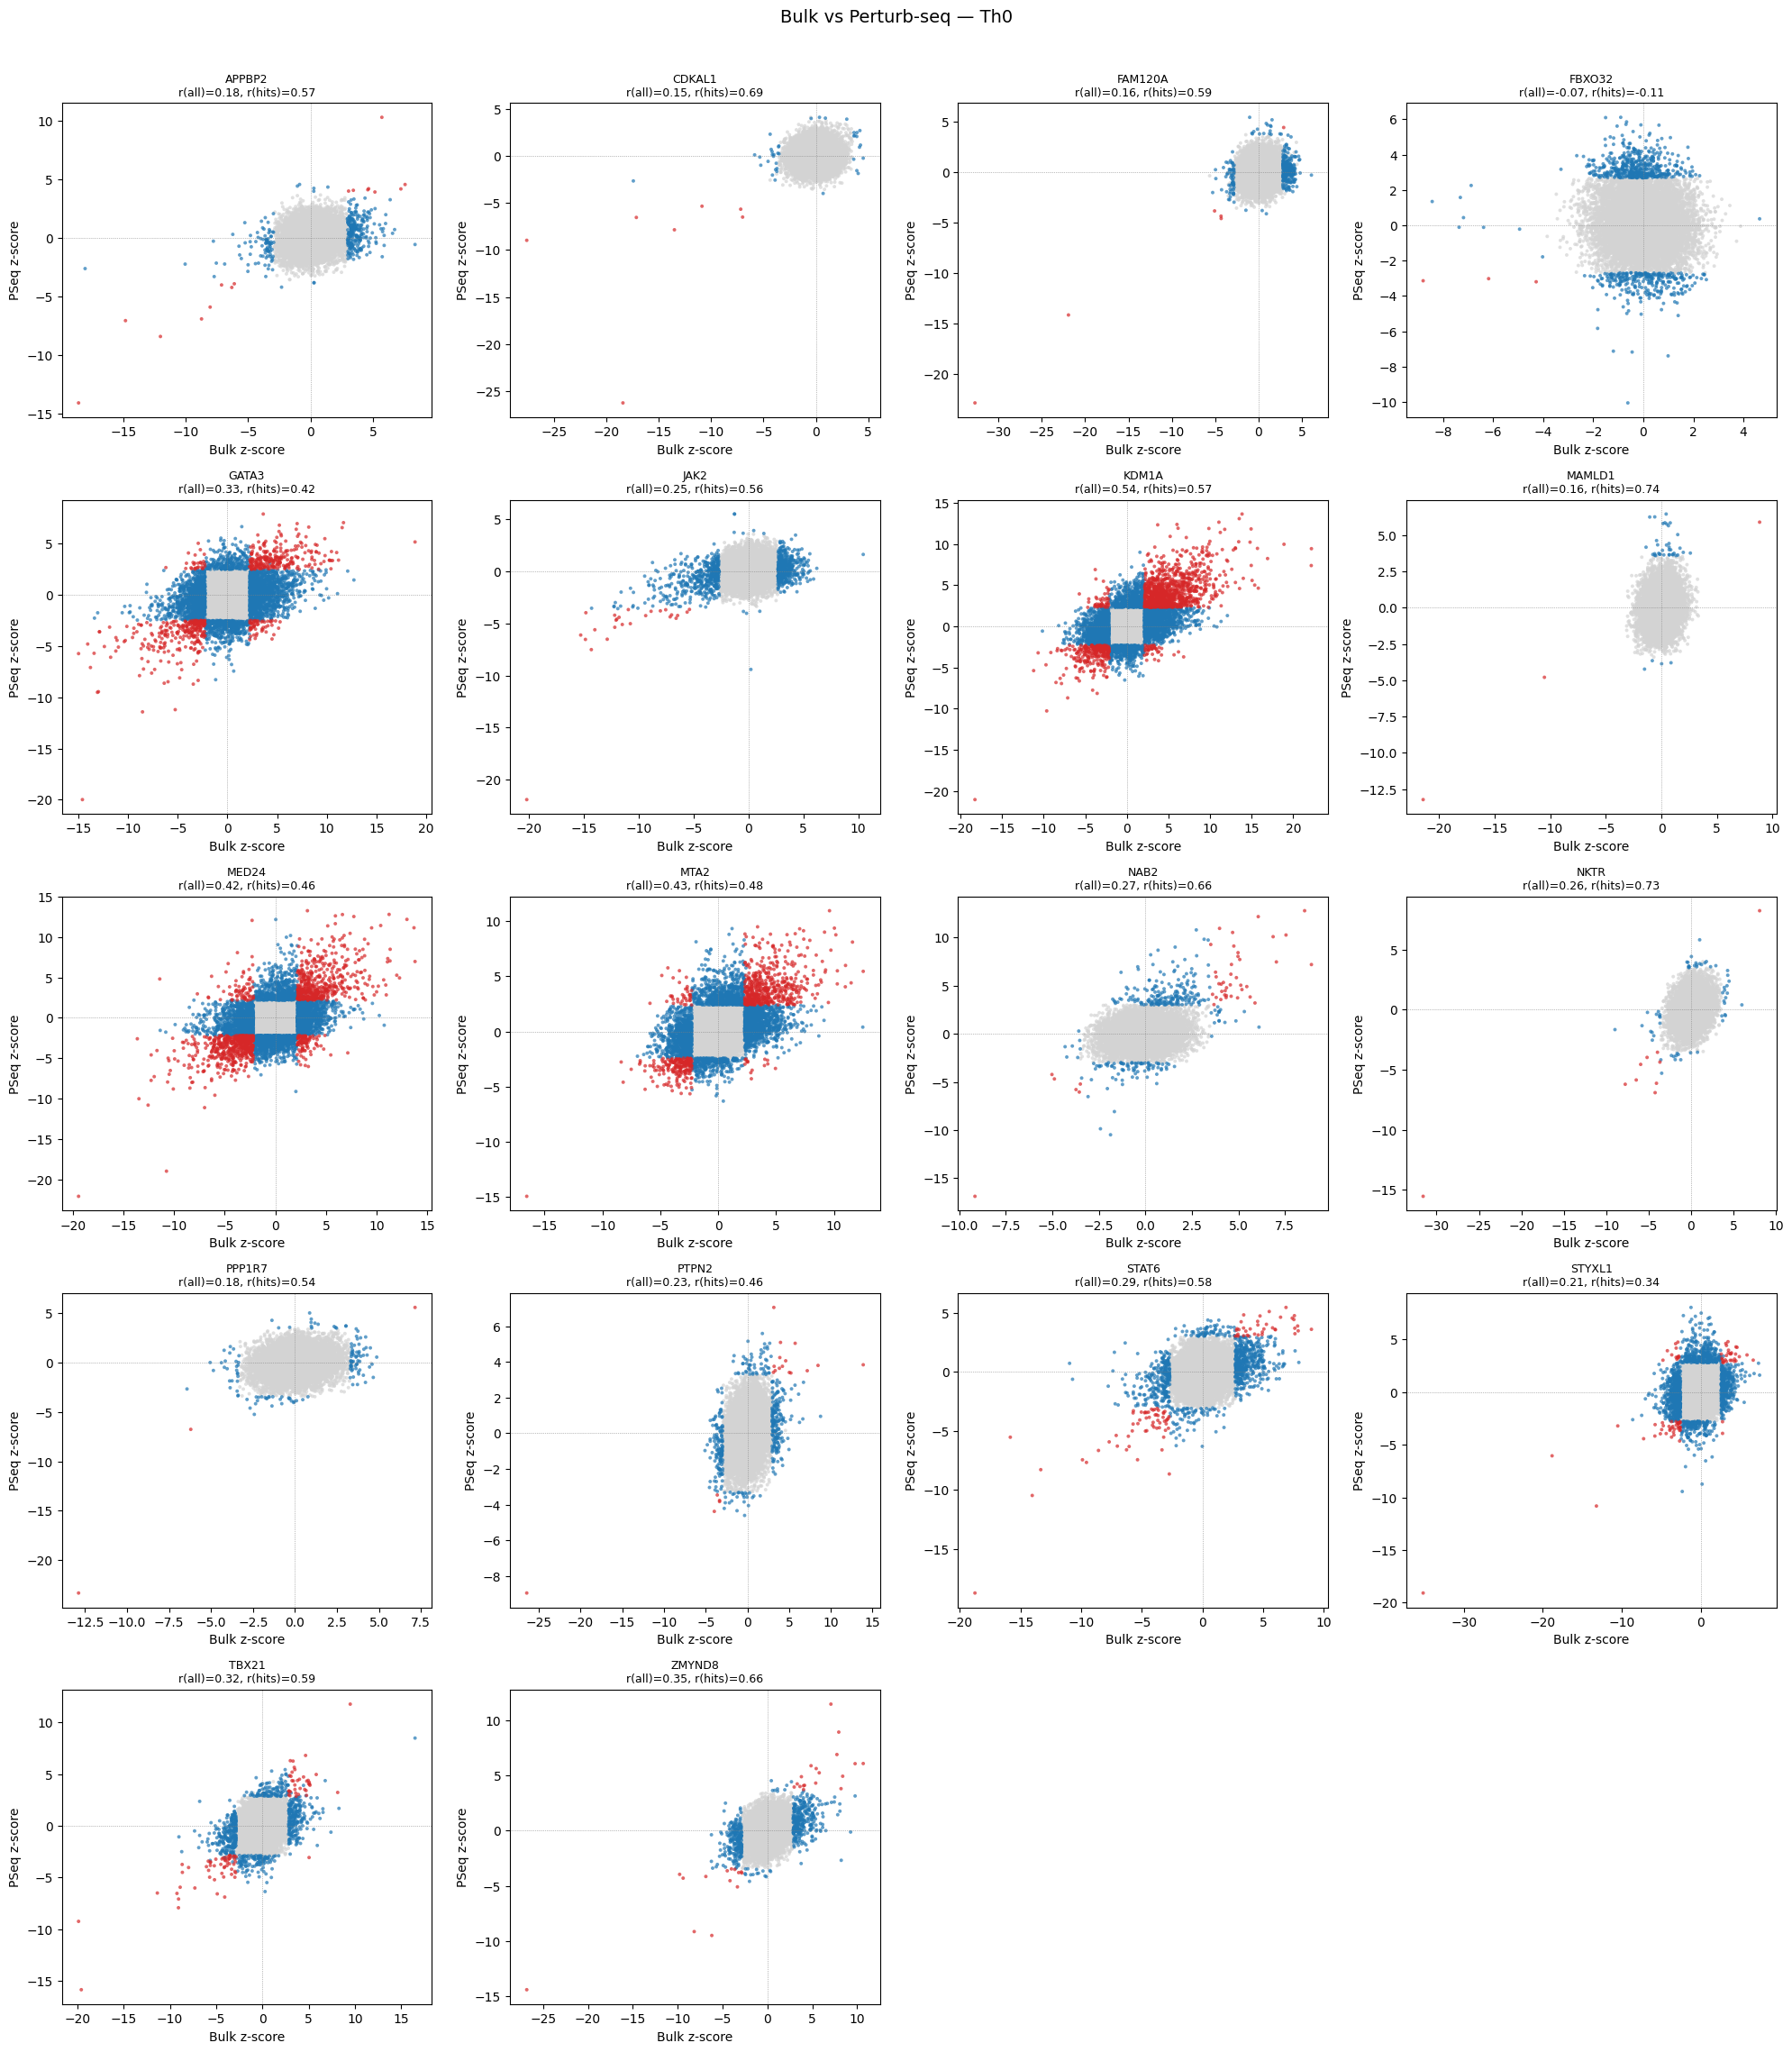

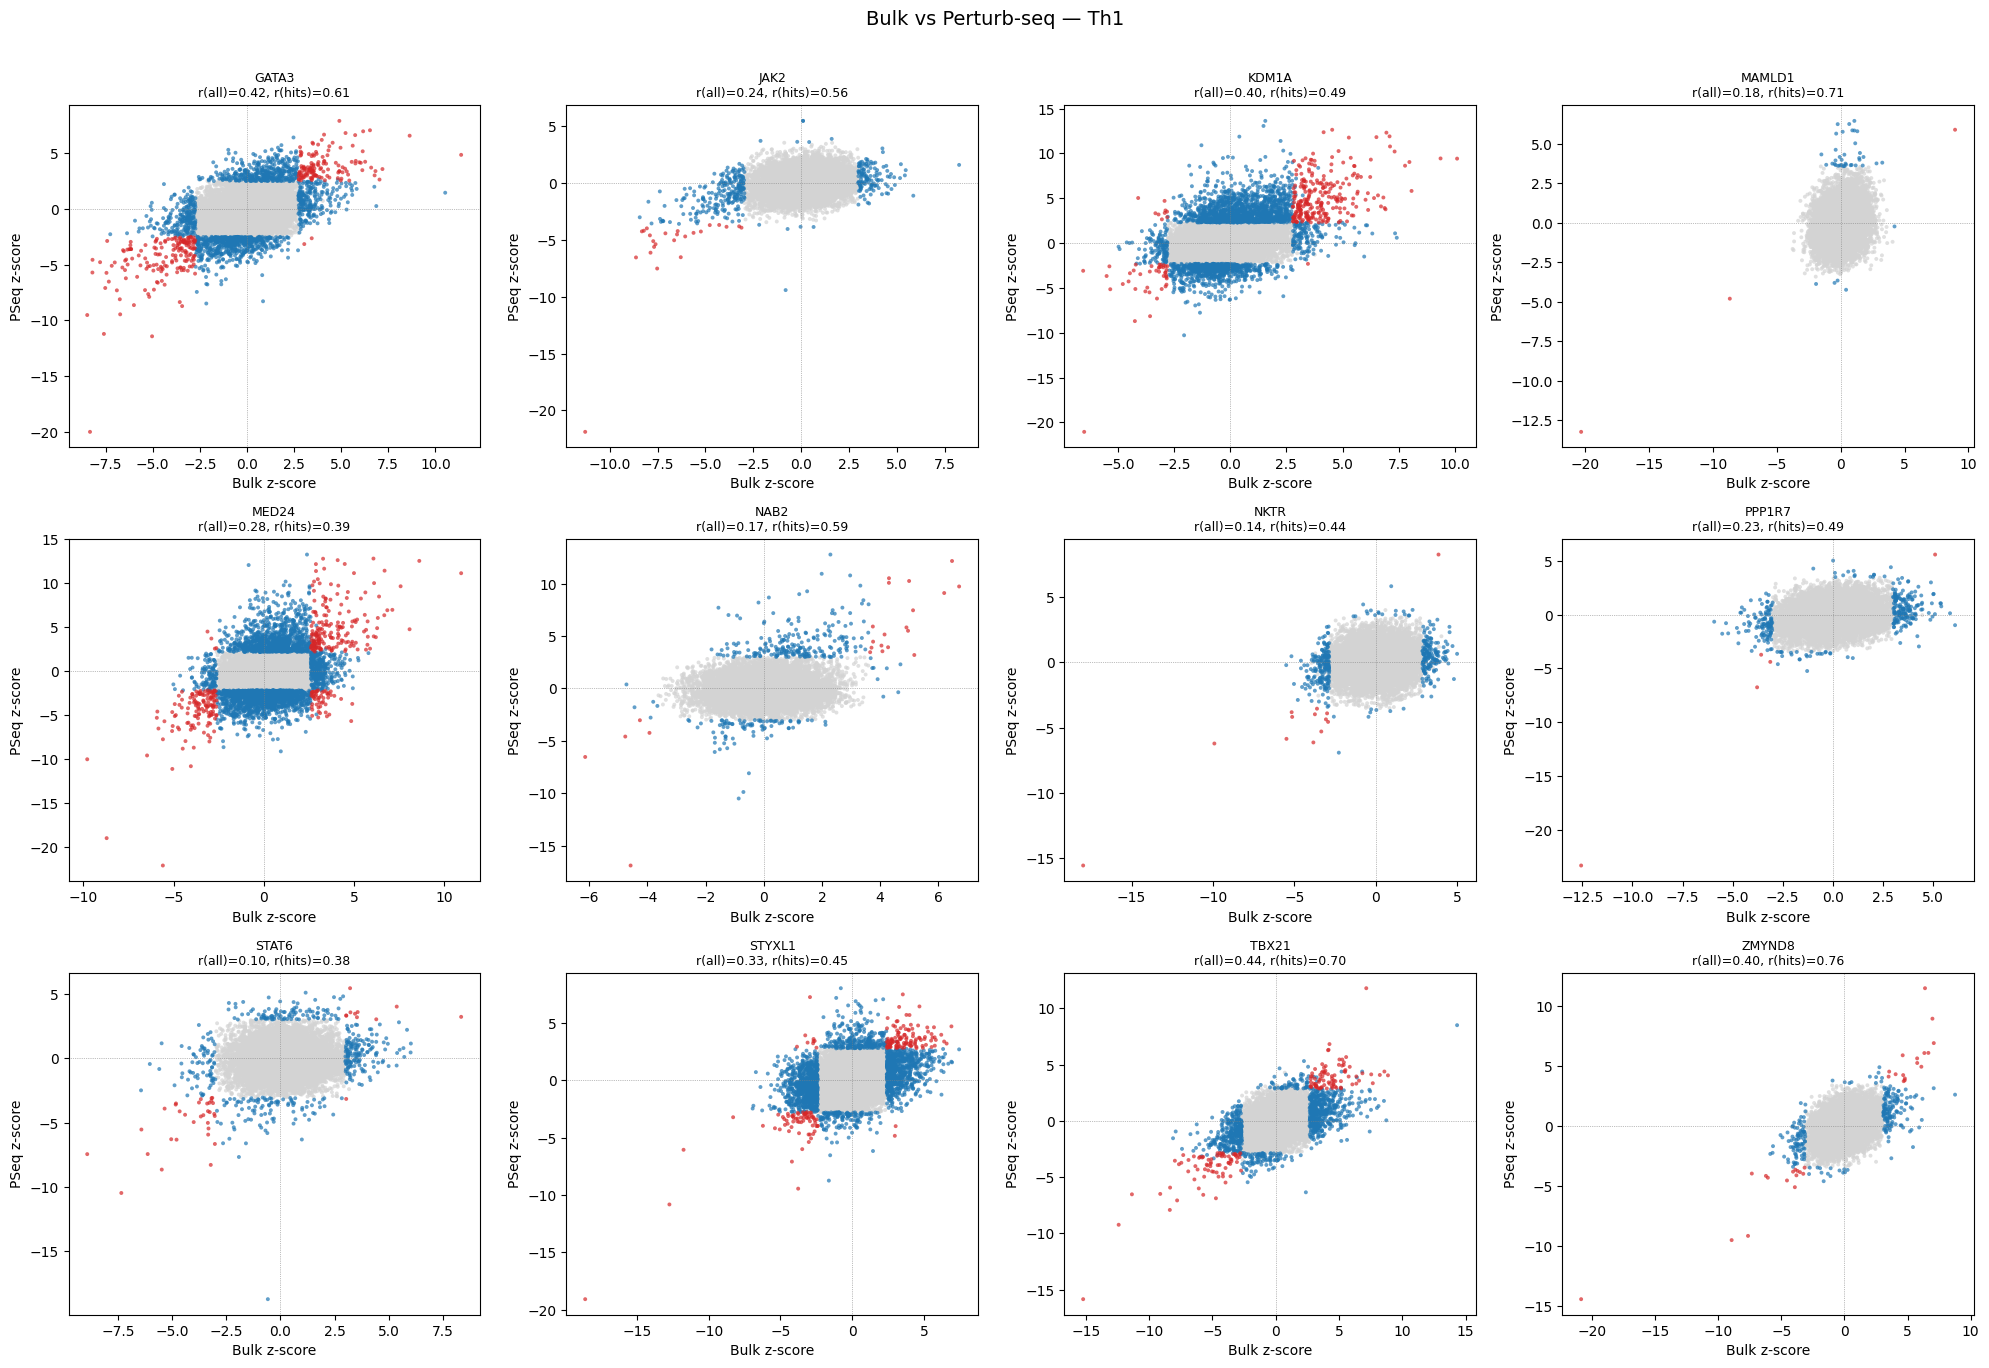

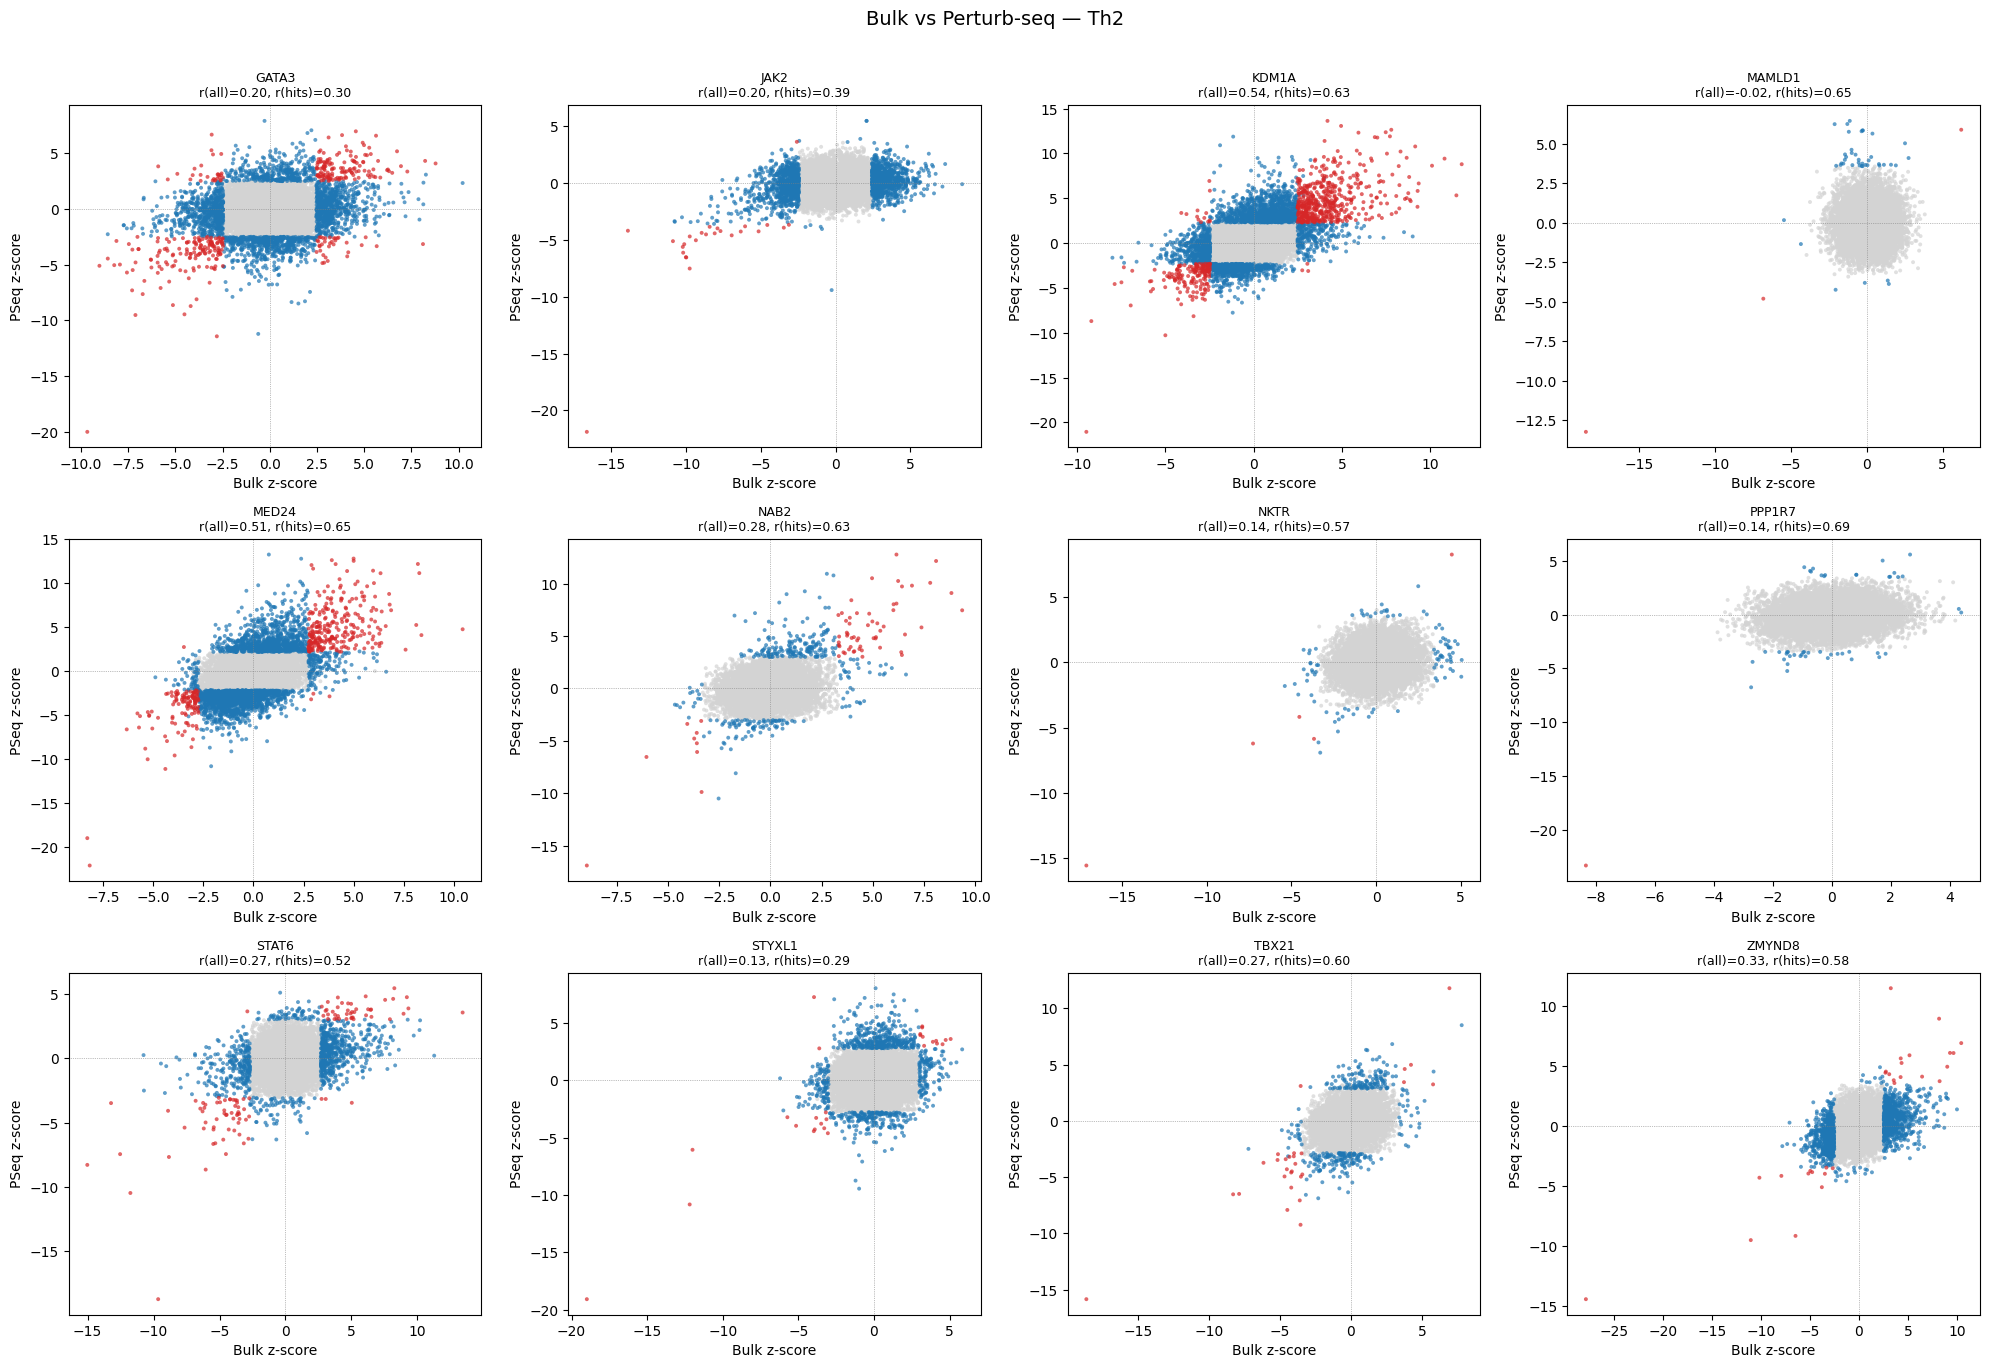

In [9]:
# Scatter: bulk vs perturb-seq z-score for each (contrast, condition)
if not all_res_df.empty:
    for cond in sorted(all_res_df['condition'].unique()):
        sub = all_res_df[all_res_df['condition']==cond]
        contrasts = sorted(sub['contrast'].unique())
        n_cols = 4
        n_rows = int(np.ceil(len(contrasts)/n_cols))
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4.5*n_rows), squeeze=False)
        for i, contrast in enumerate(contrasts):
            r, c = divmod(i, n_cols); ax = axs[r, c]
            df = sub[sub['contrast']==contrast].copy()
            if df.empty:
                ax.set_visible(False); continue
            corr_all = df[['zscore_bulk','zscore_pseq']].dropna().corr().iloc[0, 1]
            df_hits = df[df['sig_cat'] != 'NS']
            corr_hits = df_hits[['zscore_bulk','zscore_pseq']].dropna().corr().iloc[0, 1] if len(df_hits) > 2 else np.nan
            for cat, color, label, z in [('NS','lightgrey','NS',1),('one','tab:blue','one',2),('both','tab:red','both',3)]:
                s = df[df['sig_cat']==cat]
                ax.scatter(s['zscore_bulk'], s['zscore_pseq'], c=color, s=8, edgecolor='none', alpha=0.7, zorder=z, label=label)
            ax.axhline(0, c='grey', ls=':', lw=0.5); ax.axvline(0, c='grey', ls=':', lw=0.5)
            ax.set_title(f"{contrast}\nr(all)={corr_all:.2f}, r(hits)={corr_hits:.2f}", fontsize=9)
            ax.set_xlabel('Bulk z-score'); ax.set_ylabel('PSeq z-score')
        for j in range(len(contrasts), n_rows*n_cols):
            r, c = divmod(j, n_cols); axs[r, c].set_visible(False)
        fig.suptitle(f"Bulk vs Perturb-seq — {cond}", y=1.01, fontsize=14)
        plt.tight_layout()
        plt.show()

## §6 Compare to Th1/Th2 signatures

Bulk DE effects on the Ota/Hollbacker in-vivo Th1/Th2 signature gene set.

## Compare to Th1/Th2 signatures

In [10]:
# In vivo signature - discovery
ota_signature = pd.read_csv('results/Ota_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
ota_signature.loc[ota_signature['zscore'] > 30, 'zscore'] = 30
ota_signature.loc[ota_signature['zscore'] < -30, 'zscore'] = -30

# In vivo signature - replication
hollbacker_signature = pd.read_csv('results/hollbacher_Th2vsTh1_DE_results.csv', index_col='variable').dropna()
hollbacker_signature.loc[hollbacker_signature['zscore'] > 30, 'zscore'] = 30
hollbacker_signature.loc[hollbacker_signature['zscore'] < -30, 'zscore'] = -30

In [11]:
# Predicted effects
sorted_coefs = pd.read_csv('./results/polarization_prediction_condition_comparison.regulator_coefficients.csv', index_col=0)
sorted_coefs = sorted_coefs[(sorted_coefs['signature'] == 'ota') & (sorted_coefs['celltype'] == 'Stim8hr')]
pred_effect = sorted_coefs.set_index('regulator')['coef_mean']

targets_in_res = res_df['target_contrast_gene_name'].unique()
present = [t for t in targets_in_res if t in pred_effect.index]
missing = [t for t in targets_in_res if t not in pred_effect.index]
print(f"Targets with predicted effects: {present}")
print(f"Missing from predictions: {missing}")

Targets with predicted effects: ['TBX21', 'GATA3', 'MED24', 'KDM1A', 'PTPN2', 'JAK2', 'MTA2', 'FBXO32', 'APPBP2', 'FAM120A', 'CDKAL1', 'STAT6', 'STYXL1', 'MAMLD1', 'PPP1R7', 'NKTR', 'ZMYND8', 'NAB2']
Missing from predictions: ['FBXO32-3']


In [12]:
pred_effect

regulator
UBR7     0.004339
PYGL    -0.006004
CENPT    0.011623
PLAT     0.011851
HSPA8   -0.010143
           ...   
INSR    -0.011433
GAS6     0.004805
TOB2     0.009037
PRB4    -0.004769
ACACA   -0.014575
Name: coef_mean, Length: 3927, dtype: float64

In [13]:
# Define Th1/Th2 signature genes (intersection of sig in both cohorts, top/bottom by zscore)
state_results_df = ota_signature.reset_index().copy()
state_results_repl_df = hollbacker_signature.reset_index().copy()
sig_genes_ota = state_results_df[state_results_df['adj_p_value'] < 0.01]['variable'].tolist()
sig_genes_hollbacker = state_results_repl_df[state_results_repl_df['adj_p_value'] < 0.01]['variable'].tolist()
sig_genes_both = list(set(sig_genes_ota) & set(sig_genes_hollbacker))

state_results_df = state_results_df[state_results_df['variable'].isin(sig_genes_both)].copy()

n_top = 20
signature_gs_up = state_results_df.nlargest(n_top, 'zscore').sort_values('zscore', ascending=False)['variable'].tolist()
signature_gs_down = state_results_df.nsmallest(n_top, 'zscore').sort_values('zscore')['variable'].tolist()
print(f"Signature genes: {len(signature_gs_up)} up, {len(signature_gs_down)} down")

Signature genes: 20 up, 20 down


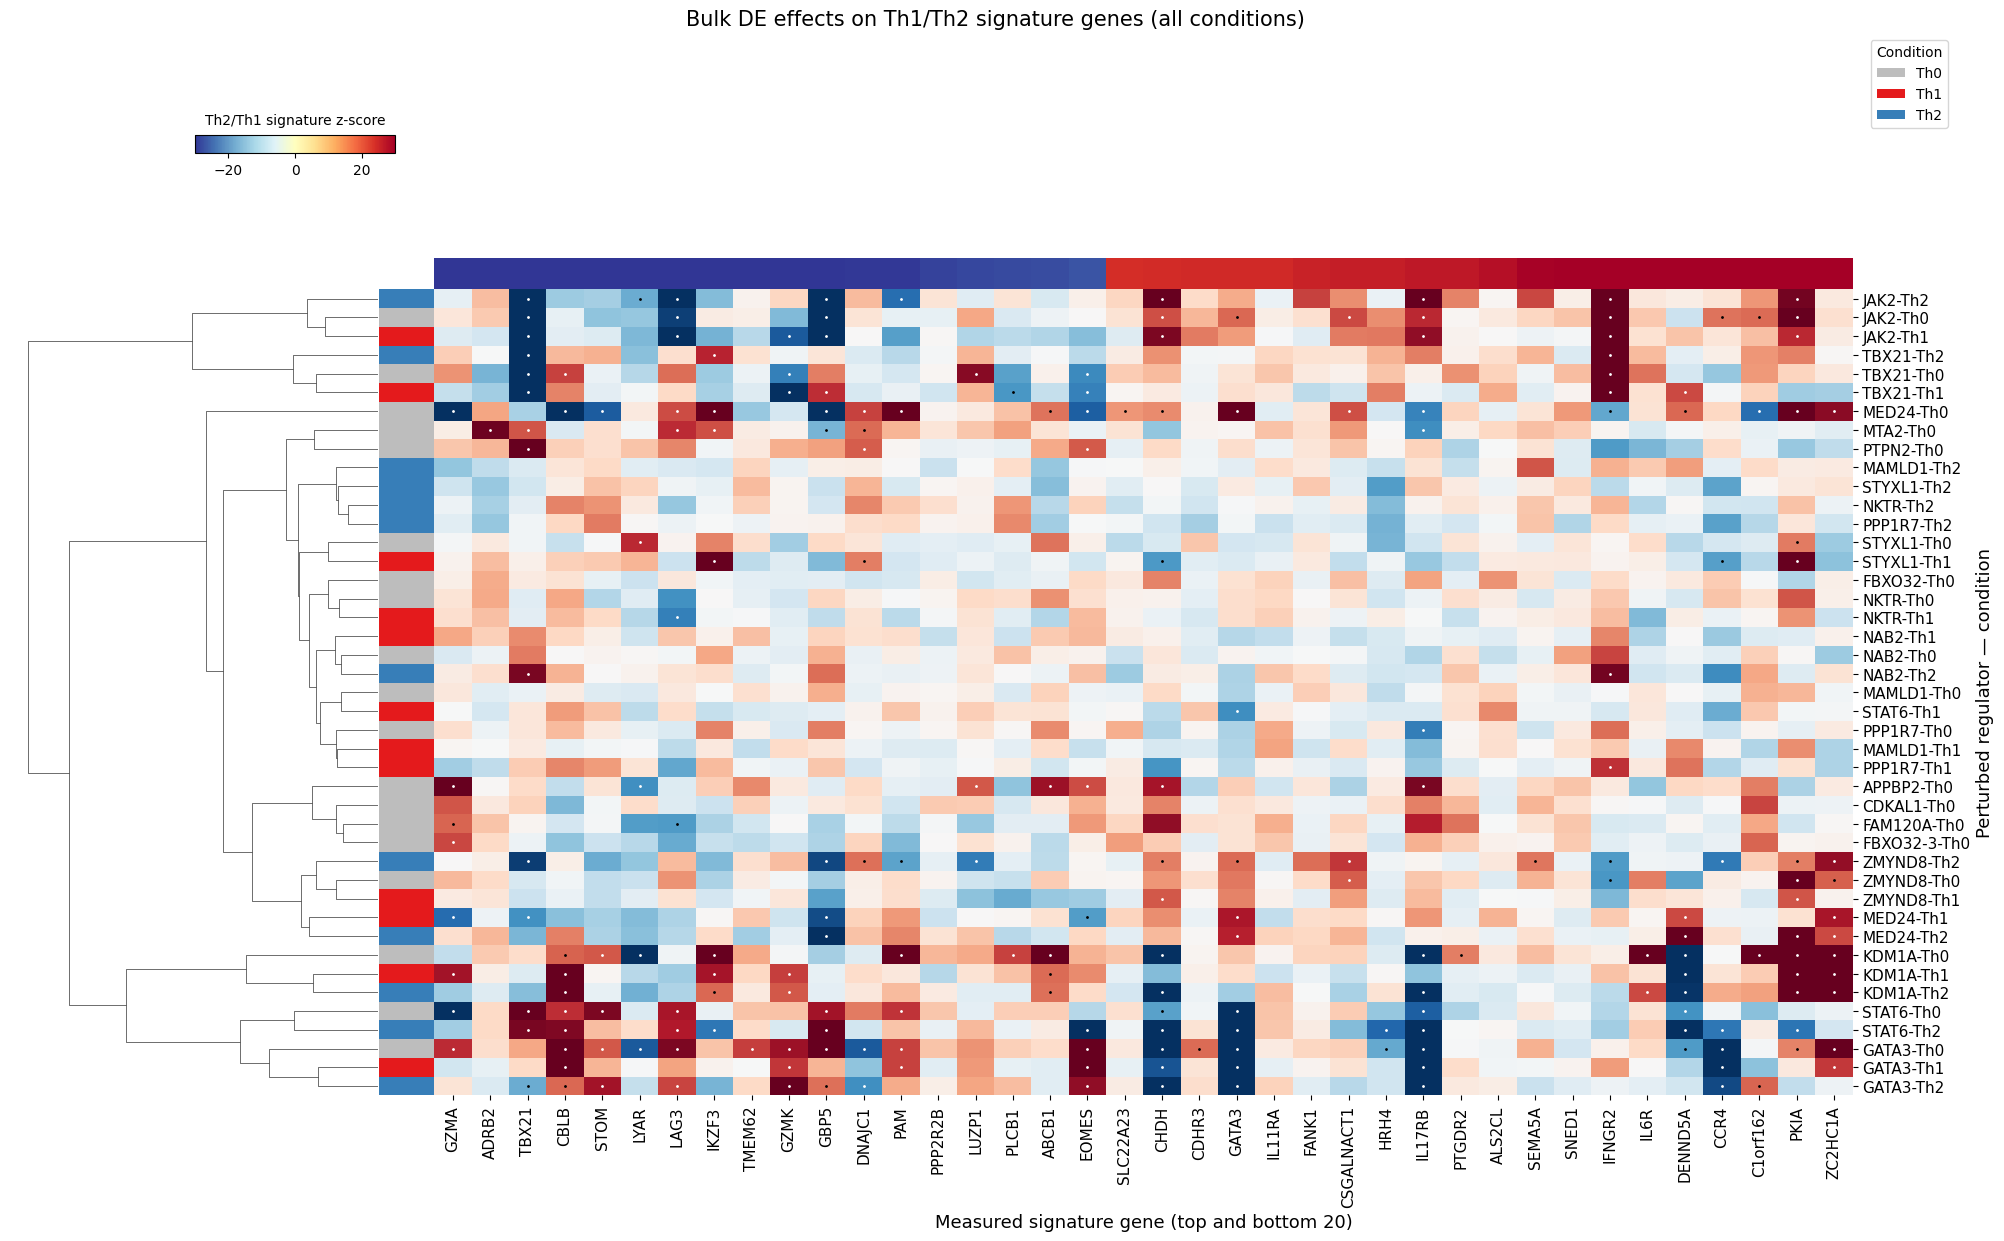

In [14]:
# Clustermap: z-score of bulk DE effect on signature genes, all 3 conditions in one heatmap.
# Rows are named "<contrast>-<condition>".
pl_df = res_df[res_df['gene_name'].isin(signature_gs_up + signature_gs_down)].copy()
pl_df['row_label'] = pl_df['contrast'].astype(str) + '-' + pl_df['condition'].astype(str)

wide = pl_df.pivot(index='row_label', columns='gene_name', values='zscore').fillna(0)
wide_p = pl_df.pivot(index='row_label', columns='gene_name', values='adj_p_value').fillna(1)

col_annot = pd.DataFrame({'zscore': ota_signature.loc[wide.columns, 'zscore']})
sorted_cols = col_annot.sort_values('zscore').index
wide = wide[sorted_cols]; wide_p = wide_p[sorted_cols]; col_annot = col_annot.loc[sorted_cols]

cmap_col = plt.cm.RdYlBu_r
vmax_col = max(abs(col_annot['zscore'].min()), abs(col_annot['zscore'].max()))
col_colors = col_annot['zscore'].apply(lambda x: cmap_col((x + vmax_col) / (2 * vmax_col)))

# Row annotation by condition for quick visual grouping
cond_palette = {'Th0': '#bdbdbd', 'Th1': '#e41a1c', 'Th2': '#377eb8'}
row_cond = wide.index.to_series().str.rsplit('-', n=1).str[-1]
row_colors = row_cond.map(cond_palette)

g = sns.clustermap(
    wide, cmap='RdBu_r', center=0,
    row_cluster=True, col_cluster=False,
    xticklabels=True, yticklabels=True, method='ward',
    figsize=(20, 12),
    col_colors=[col_colors], row_colors=[row_colors],
    vmin=-5, vmax=5, cbar_pos=None,
)

row_order = g.dendrogram_row.reordered_ind
for i, ri in enumerate(row_order):
    for j in range(wide.shape[1]):
        if wide_p.iloc[ri, j] < 0.1:
            zs = wide.iloc[ri, j]
            dot = 'w' if abs(zs) > 3 else 'k'
            g.ax_heatmap.plot(j + 0.5, i + 0.5, f'{dot}.', markersize=2)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=11)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=11)
g.ax_heatmap.set_xlabel('Measured signature gene (top and bottom 20)', fontsize=13)
g.ax_heatmap.set_ylabel('Perturbed regulator — condition', fontsize=13)
g.fig.suptitle("Bulk DE effects on Th1/Th2 signature genes (all conditions)", y=1.02, fontsize=15)

# Legends for annotation strips
norm_col = plt.Normalize(vmin=-vmax_col, vmax=vmax_col)
cax_col = g.fig.add_axes([0.1, 0.9, 0.1, 0.015])
plt.colorbar(plt.cm.ScalarMappable(norm=norm_col, cmap=cmap_col), cax=cax_col, orientation='horizontal')
cax_col.set_title('Th2/Th1 signature z-score', fontsize=10, pad=8)

from matplotlib.patches import Patch
cond_handles = [Patch(facecolor=c, label=cond) for cond, c in cond_palette.items()]
g.fig.legend(handles=cond_handles, title='Condition', loc='upper right', bbox_to_anchor=(0.98, 1.0), fontsize=10)

plt.show()

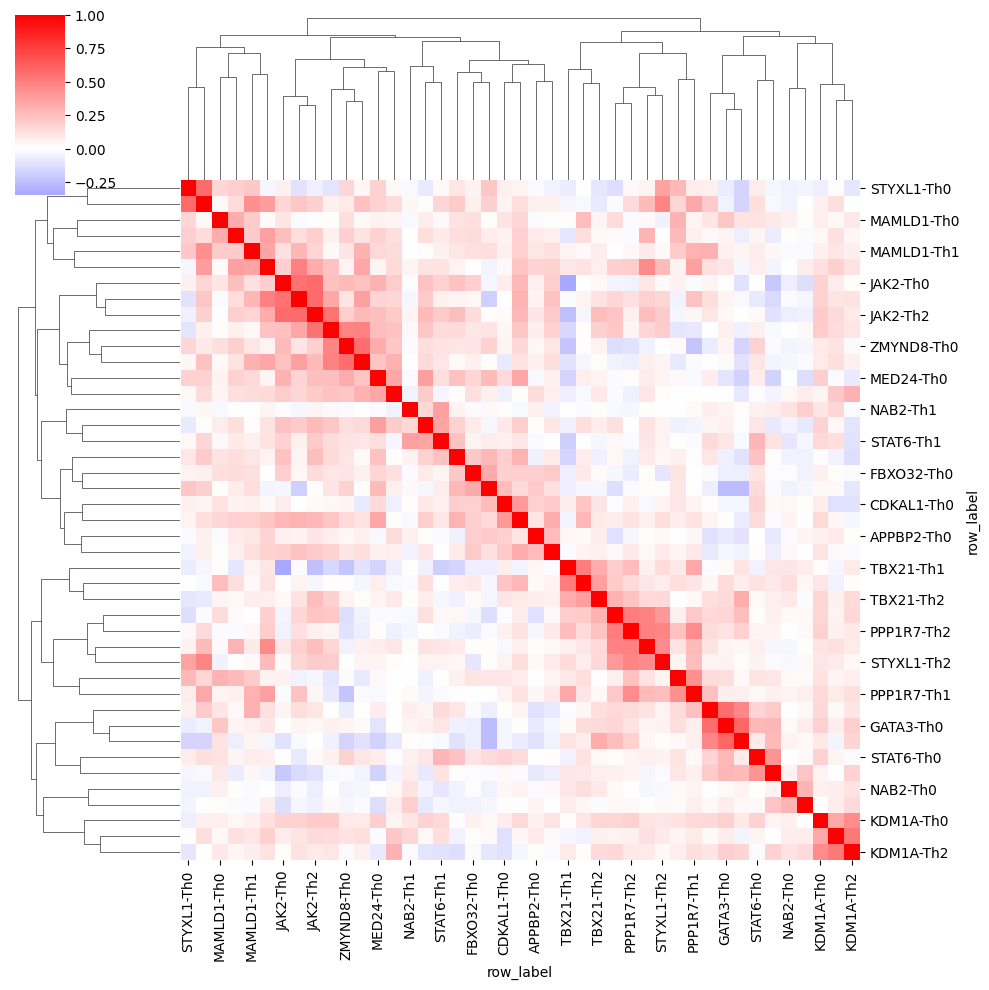

In [15]:
n_top = 50
signature_gs_up = state_results_df.nlargest(n_top, 'zscore').sort_values('zscore', ascending=False)['variable'].tolist()
signature_gs_down = state_results_df.nsmallest(n_top, 'zscore').sort_values('zscore')['variable'].tolist()
# Clustermap: z-score of bulk DE effect on signature genes, all 3 conditions in one heatmap.
# Rows are named "<contrast>-<condition>".
pl_df = res_df.copy()
pl_df['row_label'] = pl_df['contrast'].astype(str) + '-' + pl_df['condition'].astype(str)

wide = pl_df.pivot(index='row_label', columns='variable', values='zscore').fillna(0)

sns.clustermap(wide.T.corr(), cmap='bwr', center=0)

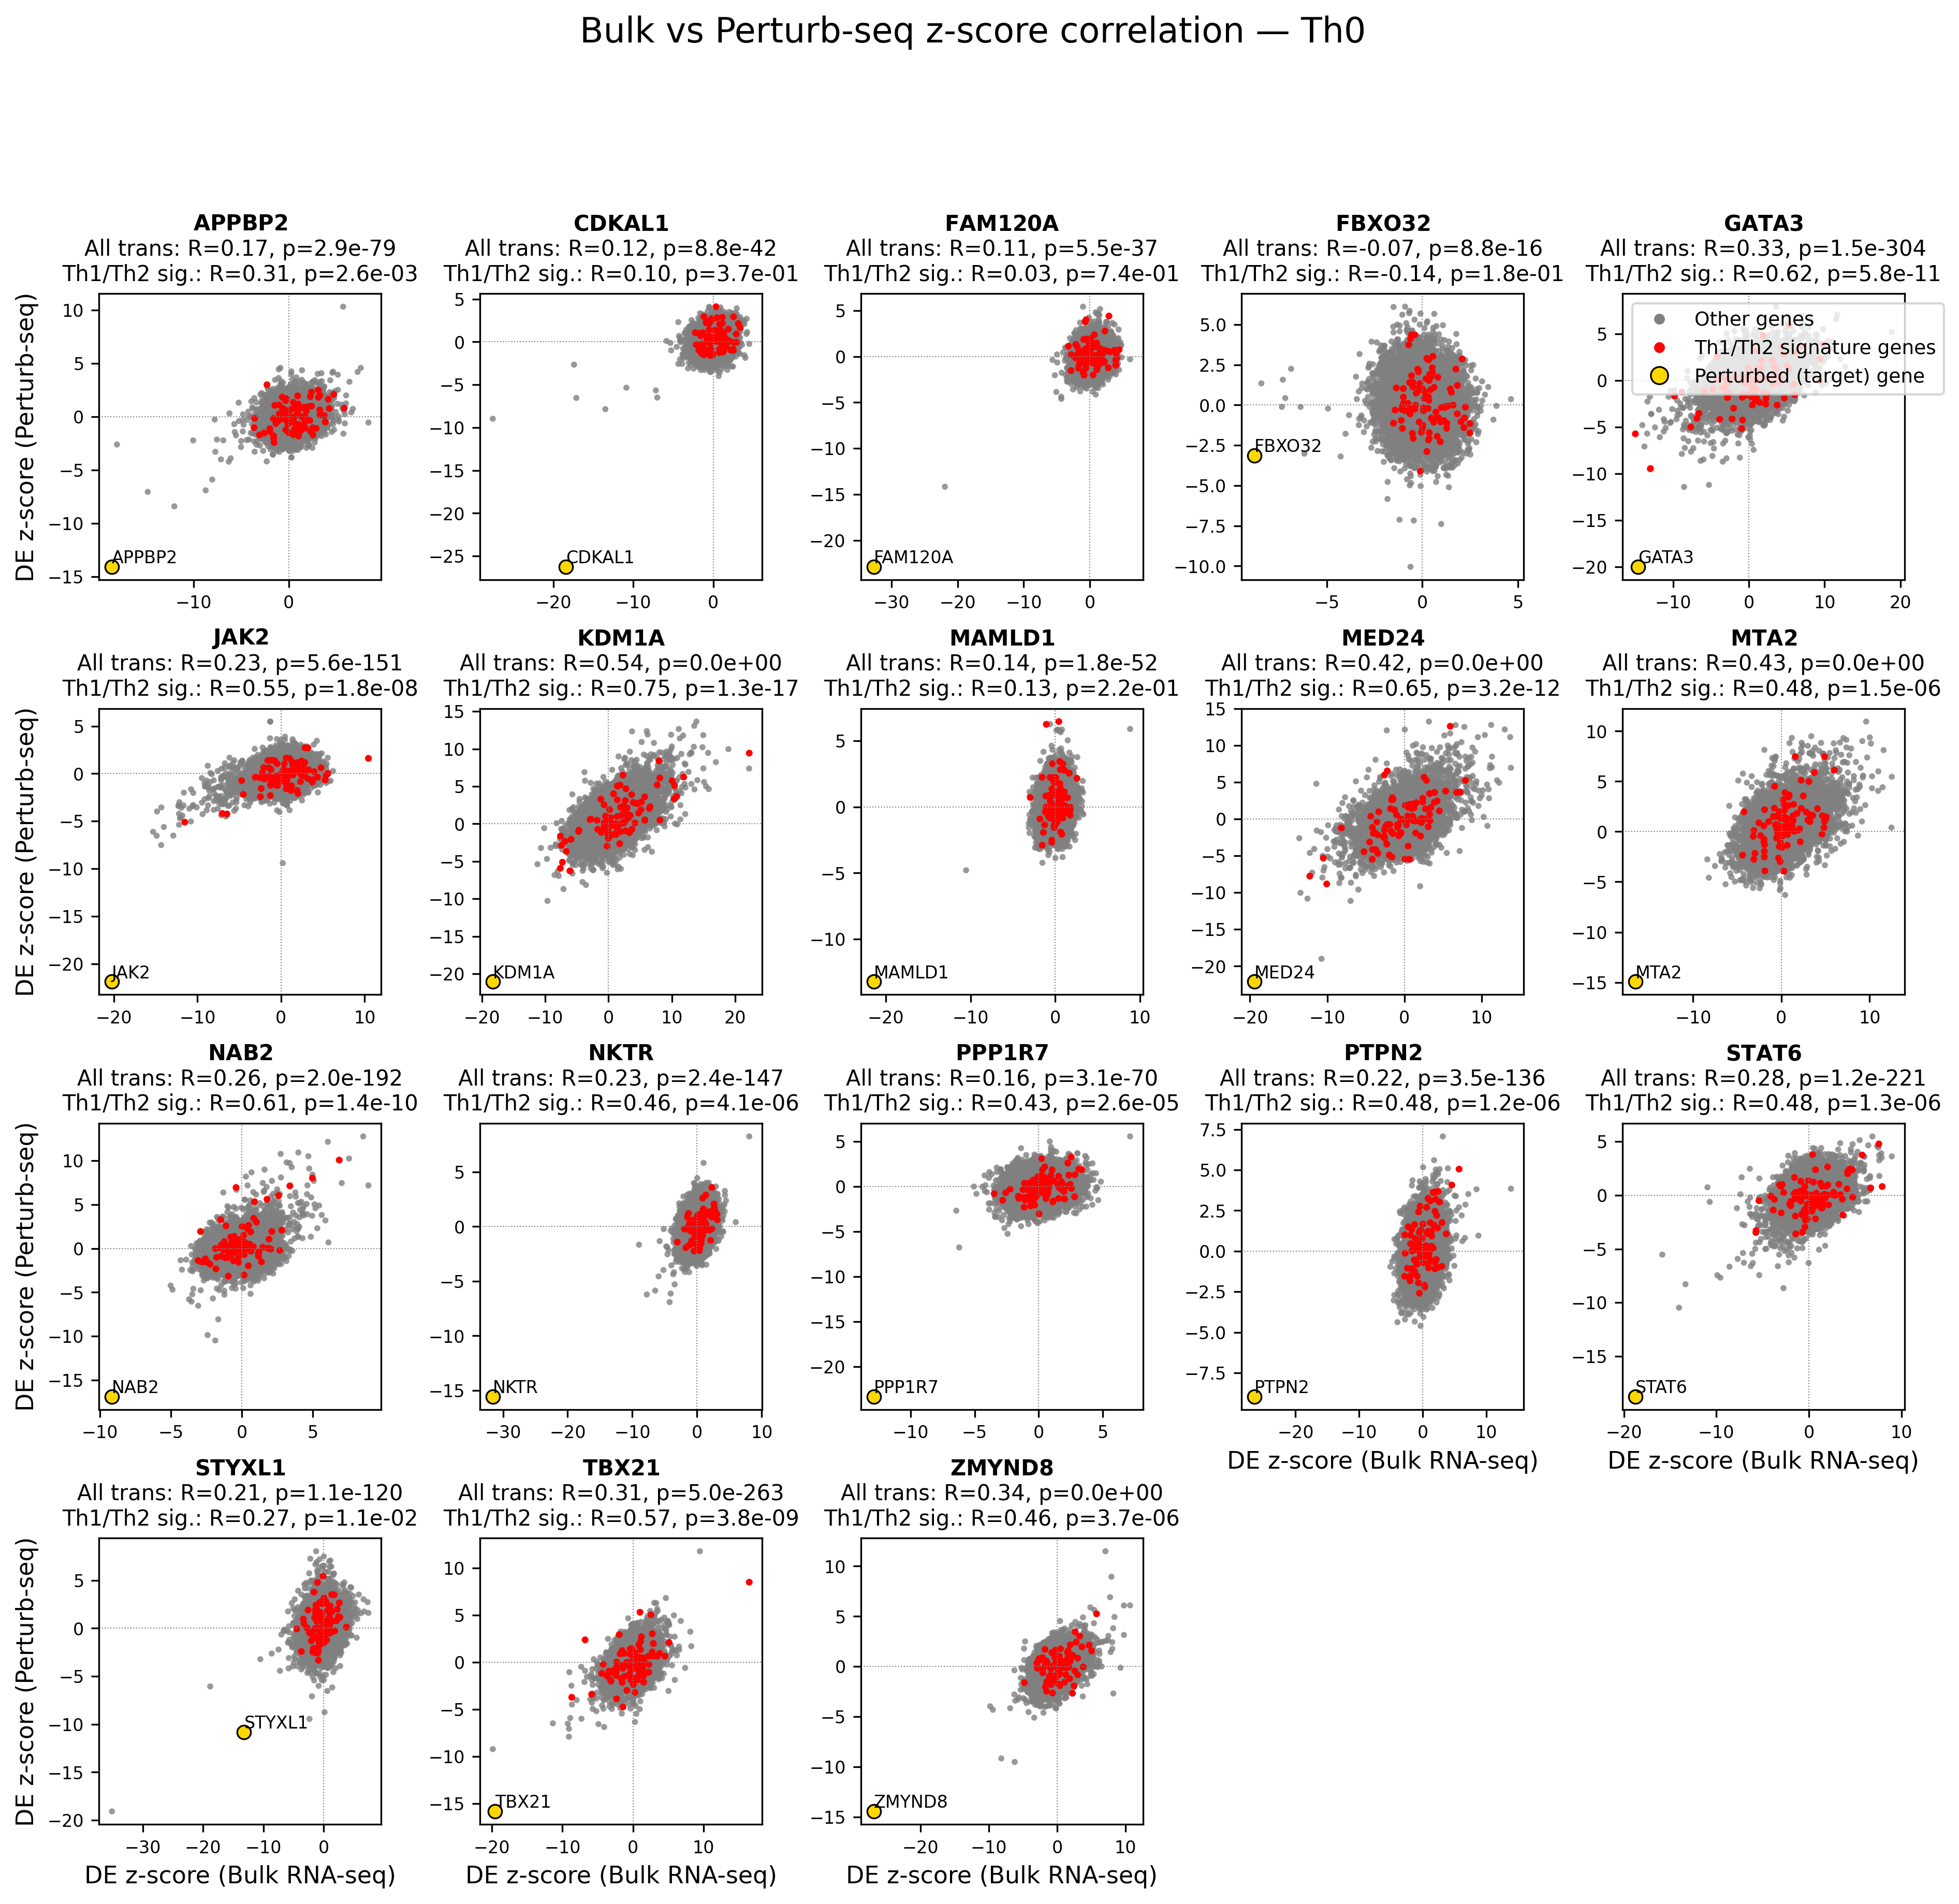

In [16]:
# Bulk vs Perturb-seq z-score correlation, highlighting Th1/Th2 signature genes
# (one figure per condition). The perturbed (target) gene is shown with a
# black-edged marker, mirroring the volcano plot above; correlations are
# computed on the *other* genes (target excluded) so the self-KD effect
# doesn't dominate.
from scipy.stats import pearsonr as _pearsonr
n_top = 50
signature_gs_up = state_results_df.nlargest(n_top, 'zscore').sort_values('zscore', ascending=False)['variable'].tolist()
signature_gs_down = state_results_df.nsmallest(n_top, 'zscore').sort_values('zscore')['variable'].tolist()

sig_genes = signature_gs_up + signature_gs_down
sig_threshold = 0.1

if not all_res_df.empty:
    cond = 'Th0'
    sub = all_res_df[all_res_df['condition'] == cond].copy()
    sub['is_sig_gene'] = sub['gene_name'].isin(sig_genes)
    contrasts = sorted(sub['contrast'].unique())
    n_contrasts = len(contrasts)
    n_rows = 4
    n_cols = int(np.ceil(n_contrasts / n_rows))

    fig, axs = plt.subplots(
        n_rows, n_cols, figsize=(3.0 * n_cols, 3.2 * n_rows),
        squeeze=False, sharex=False, sharey=False,
        gridspec_kw={'wspace': 0.35, 'hspace': 0.45},
    )

    rasterized_opts = {"rasterized": True}
    # Increased DPI for better raster resolution in output figure (applies only when saved to file)
    fig.dpi = 300

    for i, contrast in enumerate(contrasts):
        row, col = divmod(i, n_cols)
        ax = axs[row, col]
        df = sub[sub['contrast'] == contrast].copy()
        if df.empty:
            ax.set_visible(False)
            continue

        target_name = df['target_contrast_gene_name'].iloc[0]
        target_mask = df['gene_name'] == target_name

        # Correlations exclude the target gene -- its self-KD effect dominates
        # the relationship and isn't informative for off-target concordance.
        non_target = df[~target_mask]
        sub_all = non_target[['zscore_bulk', 'zscore_pseq']].dropna()
        r_all, p_all = _pearsonr(sub_all['zscore_bulk'], sub_all['zscore_pseq']) if len(sub_all) > 2 else (np.nan, np.nan)

        sub_sig = non_target[non_target['is_sig_gene']][['zscore_bulk', 'zscore_pseq']].dropna()
        r_sig, p_sig = _pearsonr(sub_sig['zscore_bulk'], sub_sig['zscore_pseq']) if len(sub_sig) > 2 else (np.nan, np.nan)

        other = df[~df['is_sig_gene'] & ~target_mask]
        sigdf = df[df['is_sig_gene'] & ~target_mask]
        target_df = df[target_mask]
        ax.scatter(
            other['zscore_bulk'], other['zscore_pseq'],
            c='grey', s=8, edgecolor='none', alpha=0.8, zorder=1, **rasterized_opts
        )
        ax.scatter(
            sigdf['zscore_bulk'], sigdf['zscore_pseq'],
            c='red', s=10, edgecolor='none', alpha=1, zorder=2, **rasterized_opts
        )
        ax.scatter(
            target_df['zscore_bulk'], target_df['zscore_pseq'],
            c='gold', s=40, edgecolor='black', linewidth=0.8, zorder=4, **rasterized_opts
        )
        for _, rrow in target_df.iterrows():
            ax.text(rrow['zscore_bulk'], rrow['zscore_pseq'], rrow['gene_name'],
                    fontsize=8, ha='left', va='bottom', zorder=5)

        ax.axhline(0, c='grey', ls=':', lw=0.5)
        ax.axvline(0, c='grey', ls=':', lw=0.5)
        ax.set_title(
            rf"$\bf{{{contrast}}}$"
            f"\nAll trans: R={r_all:.2f}, p={p_all:.1e}\n"
            f"Th1/Th2 sig.: R={r_sig:.2f}, p={p_sig:.1e}",
            fontsize=10)
        # Each panel keeps its own tick labels and independent x/y ranges.
        # Axis *labels* (text) only on the leftmost column and the
        # bottom-most visible panel of each column.
        is_bottom = (i + n_cols >= n_contrasts)
        if col == 0:
            ax.set_ylabel("DE z-score (Perturb-seq)", fontsize=11)
        if is_bottom:
            ax.set_xlabel("DE z-score (Bulk RNA-seq)", fontsize=11)
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=6, label='Other genes'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',  markersize=6, label='Th1/Th2 signature genes'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',
                   markeredgecolor='black', markeredgewidth=0.8, markersize=8,
                   label='Perturbed (target) gene'),
    ]
    axs[0, -1].legend(handles=handles, loc='upper left', fontsize=9, frameon=True)

    for j in range(n_contrasts, n_rows * n_cols):
        r, c = divmod(j, n_cols)
        axs[r, c].set_visible(False)

    fig.suptitle(f'Bulk vs Perturb-seq z-score correlation — {cond}', fontsize=16, y=1.02)
    plt.savefig('./results/validation_bulkRNAseq_corr_scatters.pdf', dpi=300)
    plt.show()


In [17]:
# For each perturbation, correlate the Th0 bulk effect against:
#   - Pseq z-score, - Th1 bulk effect, - Th2 bulk effect.
# Per-gene Pearson r on all genes, with a 5-resample bootstrap for error bars.
from scipy.stats import pearsonr as _pearsonr

N_BOOT = 5
rng = np.random.default_rng(0)

# Pivot to wide format on condition: one row per (contrast, gene) with bulk
# z-scores split into z_Th0 / z_Th1 / z_Th2 columns.
wide = (all_res_df
        .pivot_table(index=['contrast', 'gene_name'],
                     columns='condition',
                     values='zscore_bulk', aggfunc='first')
        .add_prefix('z_').reset_index())
# Pseq z-score: take from the Th0 row (assumed paired with bulk per gene).
pseq = (all_res_df[all_res_df['condition'] == 'Th0']
        [['contrast', 'gene_name', 'zscore_pseq']])
wide = wide.merge(pseq, on=['contrast', 'gene_name'], how='left')

# Per-contrast target gene; correlations below exclude this gene so the
# self-KD effect doesn't dominate the per-gene Pearson r.
target_per_contrast = (all_res_df.dropna(subset=['target_contrast_gene_name'])
                       .groupby('contrast')['target_contrast_gene_name'].first())

def boot_corr(df, x_col, y_col, n_boot=N_BOOT, rng=rng):
    sub = df[[x_col, y_col]].dropna()
    n = len(sub)
    if n <= 2:
        return np.nan, np.nan, np.nan, n
    r_obs = _pearsonr(sub[x_col], sub[y_col])[0]
    rs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        bs = sub.iloc[idx]
        if bs[x_col].std() == 0 or bs[y_col].std() == 0:
            continue
        rs.append(_pearsonr(bs[x_col], bs[y_col])[0])
    rs = np.array(rs)
    return (r_obs,
            rs.mean() if len(rs) else np.nan,
            rs.std(ddof=1) if len(rs) > 1 else np.nan,
            n)

summary_rows = []
for contrast in sorted(wide['contrast'].unique()):
    df = wide[wide['contrast'] == contrast]
    target_name = target_per_contrast.get(contrast)
    if target_name is not None:
        df = df[df['gene_name'] != target_name]
    for label, ycol in [('Th0', 'z_Th0'), ('Th1', 'z_Th1'), ('Th2', 'z_Th2')]:
        if ycol not in df.columns:
            continue
        r_obs, r_mean, r_std, n = boot_corr(df, 'zscore_pseq', ycol)
        summary_rows.append({
            'contrast': contrast,
            'comparison': label,        # what Th0 was compared to
            'n': n,
            'r_all': r_obs,
            'r_boot_mean': r_mean,
            'r_boot_std':  r_std,
            'pred_effect_val': pred_effect.get(contrast, 0),
        })
corr_summary_df = pd.DataFrame(summary_rows)
corr_summary_df

,contrast,comparison,n,r_all,r_boot_mean,r_boot_std,pred_effect_val
0,APPBP2,Th0,12163,0.169793,0.173406,0.015852,-0.035825
1,APPBP2,Th1,0,NaN,NaN,NaN,-0.035825
2,APPBP2,Th2,0,NaN,NaN,NaN,-0.035825
3,CDKAL1,Th0,12146,0.122445,0.128359,0.022218,-0.043030
4,CDKAL1,Th1,0,NaN,NaN,NaN,-0.043030
5,CDKAL1,Th2,0,NaN,NaN,NaN,-0.043030
6,FAM120A,Th0,12150,0.114937,0.104070,0.026977,-0.031947
7,FAM120A,Th1,0,NaN,NaN,NaN,-0.031947
8,FAM120A,Th2,0,NaN,NaN,NaN,-0.031947
9,FBXO32,Th0,12162,-0.072968,-0.065248,0.010707,-0.040807


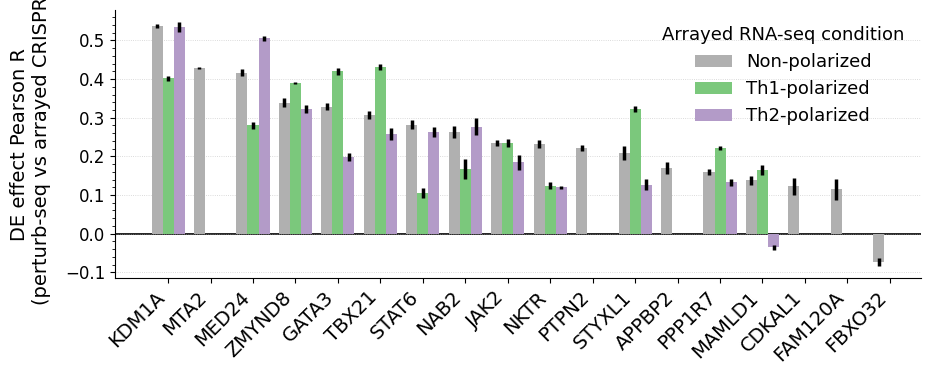

In [18]:
# Bar plot: vertical, one bar per (contrast, comparison) — three bars per
# perturbation showing the Th0-vs-Pseq / Th0-vs-Th1 / Th0-vs-Th2 correlation,
# with bootstrap-std error bars.
if not corr_summary_df.empty:
    import matplotlib as mpl
    mpl.rcParams.update({'font.size': 15, 'axes.titlesize': 18, 'axes.labelsize': 16,
                        'legend.fontsize': 13, 'xtick.labelsize': 14, 'ytick.labelsize': 14})

    COMPARISONS = ['Th0', 'Th1', 'Th2']
    COMP_LABELS = {'Th0': 'Non-polarized', 'Th1':'Th1-polarized', 'Th2':'Th2-polarized'}
    COLORS = {
        'Th0': '#B0B0B0',
        'Th1': '#7bc87c',  # slightly darker shade of original '#d9f0d3'
        'Th2': '#b39bc8',  # slightly darker shade of original '#e7d4e8'
    }

    # Sort perturbations by their correlation with Th0 (descending).
    contrasts_sorted = (
        corr_summary_df[corr_summary_df['comparison'] == 'Th0']
        .sort_values('r_all', ascending=False)['contrast'].tolist()
    )
    # Append any contrast missing a Th0 row at the end (preserves shape).
    missing = [t for t in corr_summary_df['contrast'].unique() if t not in contrasts_sorted]
    contrasts_sorted = contrasts_sorted + missing
    x = np.arange(len(contrasts_sorted))
    w = 0.26  # bar width; centred at x, ±w gives 3 grouped bars
    offsets = {'Th0': -w, 'Th1': 0.0, 'Th2': +w}

    fig, ax = plt.subplots(figsize=(max(5.5, 0.42 * len(contrasts_sorted) + 2), 4))
    for comp in COMPARISONS:
        sub = (corr_summary_df[corr_summary_df['comparison'] == comp]
               .set_index('contrast').reindex(contrasts_sorted))
        ax.bar(
            x + offsets[comp], sub['r_all'].values, w,
            yerr=sub['r_boot_std'].values,
            label=f'{COMP_LABELS[comp]}',
            color=COLORS[comp], edgecolor=None, linewidth=0,
            error_kw=dict(elinewidth=2.5, capsize=0),  # no caps, thicker line
        )

    ax.axhline(0, color='black', linewidth=1.2, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(contrasts_sorted, fontsize=14, rotation=45, ha='right')
    ax.set_ylabel('DE effect Pearson R\n(perturb-seq vs arrayed CRISPRi)', fontsize=14, labelpad=10)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(frameon=False, loc='upper right',
              title='Arrayed RNA-seq condition', title_fontsize=13)

    # Minor grid lines on the y-axis (the value axis after the flip).
    from matplotlib.ticker import AutoMinorLocator
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.6, zorder=0)
    sns.despine()
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('./results/validation_bulkRNAseq_corr_barplots.pdf', bbox_inches='tight')


## §7 TBX21 follow-up (Diff081)

### TBX21 follow-up

In [19]:
datadir = '/mnt/oak/users/emma/data/GWT/CD4i_final/'
DE_stats= pd.read_csv(f'{datadir}/DE_results_all_confounders/DE_summary_stats_per_target.csv', index_col=0)

In [20]:
DE_stats[DE_stats.target_name == 'NAB2']

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate
26121,ENSG00000166886,NAB2,Rest,843.0,0,1,1,-3.539376,False,3.314712,False,1 DE gene,False,False,2.0,False
26418,ENSG00000166886,NAB2,Stim48hr,733.0,5,2,7,-8.675739,True,17.119023,False,2-10 DE genes,False,False,2.0,False
33418,ENSG00000166886,NAB2,Stim8hr,763.0,216,86,302,-16.881586,True,61.724795,False,>50 DE genes,False,False,2.0,False


In [21]:
weinstock_df = pd.read_csv('../../metadata/TableS4_weinstock_et_al_DE.csv')
weinstock_kos = weinstock_df['KO'].unique().tolist()
common_perturbations = np.intersect1d(weinstock_kos, adata_de[adata_de.obs.culture_condition == 'Rest'].obs['target_contrast_gene_name'])
weinstock_df['zscore'] = weinstock_df['log2FoldChange'] / weinstock_df['lfcSE']
weinstock_df['gene_id'] = weinstock_df['gene_id'].str.split('.').str[0]
tbx21_weinstock = weinstock_df[weinstock_df['KO'] == 'TBX21']

In [25]:
tbx21_weinstock = tbx21_weinstock.rename(
    columns = {'padj':'adj_p_value', 'log2FoldChange':'log_fc'}
)

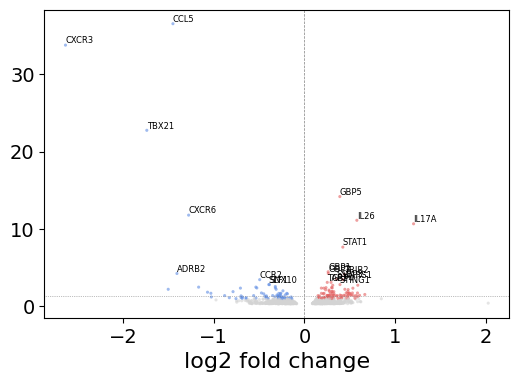

In [27]:
sub = tbx21_weinstock.copy()
sub['-log10_padj'] = -np.log10(sub['adj_p_value'].clip(lower=1e-300))
sub['color'] = 'lightgrey'
sub.loc[(sub['adj_p_value'] < 0.1) & (sub['log_fc'] > 0), 'color'] = '#e35f5f'
sub.loc[(sub['adj_p_value'] < 0.1) & (sub['log_fc'] < 0), 'color'] = '#5f8de3'

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sub['log_fc'], sub['-log10_padj'], c=sub['color'], s=5, alpha=0.6, linewidths=0)

# Label top significant genes
top = sub[(sub['adj_p_value'] < 0.1)].nlargest(20, '-log10_padj')
for _, row in top.iterrows():
    ax.text(row['log_fc'], row['-log10_padj'], row['gene_name'],
            fontsize=6, ha='left', va='bottom')

n_up = ((sub['adj_p_value'] < 0.1) & (sub['log_fc'] > 0)).sum()
n_dn = ((sub['adj_p_value'] < 0.1) & (sub['log_fc'] < 0)).sum()
# ax.set_title(f'{cond}\n↑{n_up}  ↓{n_dn}')
ax.set_xlabel('log2 fold change')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.axhline(-np.log10(0.05), color='grey', lw=0.5, ls=':')

In [28]:
DE_stats[
    DE_stats['target_name'] == 'TBX21'
    ]

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate
10440,ENSG00000073861,TBX21,Stim8hr,415.0,139,169,308,-15.850481,True,180.352853,False,>50 DE genes,False,False,2.0,False
28873,ENSG00000073861,TBX21,Stim48hr,382.0,250,153,403,-9.218964,True,50.928498,False,>50 DE genes,False,False,2.0,False
33292,ENSG00000073861,TBX21,Rest,406.0,16,24,40,-5.759933,True,27.979964,False,10-50 DE genes,False,False,2.0,False


In [31]:
t = 'TBX21'
cond = 'Stim8hr'
de_long = get_DE_results_long(adata_de, targets=[t], effect_estimates=['log_fc', 'zscore', 'p_value'], target_metadata_cols = ['culture_condition'] )

In [32]:
de_long.head()

,index,gene,log_fc,zscore,p_value,adj_p_value,significant,gene_name,culture_condition,target_contrast_gene_name
0,ENSG00000073861_Rest,ENSG00000000003,0.062108,0.001579,0.998740,NaN,False,TSPAN6,Rest,TBX21
1,ENSG00000073861_Rest,ENSG00000000419,0.058845,0.637070,0.524079,0.878173,False,DPM1,Rest,TBX21
2,ENSG00000073861_Rest,ENSG00000000457,-0.140917,-0.954744,0.339707,0.792906,False,SCYL3,Rest,TBX21
3,ENSG00000073861_Rest,ENSG00000000460,0.038725,0.248338,0.803873,0.959683,False,C1orf112,Rest,TBX21
4,ENSG00000073861_Rest,ENSG00000000938,-0.112359,-0.045762,0.963500,NaN,False,FGR,Rest,TBX21


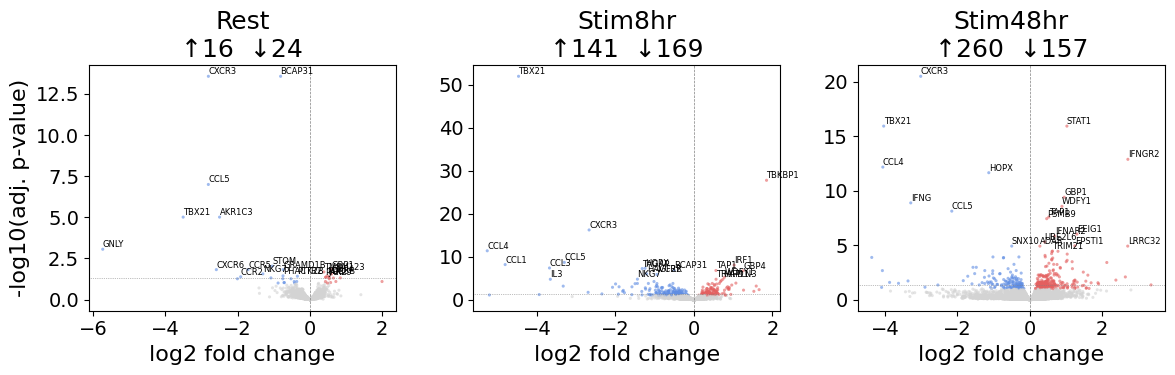

In [33]:
# Volcano plot of TBX21 perturbation DE effects per condition
import numpy as np

conditions = ['Rest', 'Stim8hr', 'Stim48hr']
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

for ax, cond in zip(axes, conditions):
    sub = de_long[de_long['culture_condition'] == cond].copy()
    sub['-log10_padj'] = -np.log10(sub['adj_p_value'].clip(lower=1e-300))
    sub['color'] = 'lightgrey'
    sub.loc[sub['significant'] & (sub['log_fc'] > 0), 'color'] = '#e35f5f'
    sub.loc[sub['significant'] & (sub['log_fc'] < 0), 'color'] = '#5f8de3'

    ax.scatter(sub['log_fc'], sub['-log10_padj'], c=sub['color'], s=5, alpha=0.6, linewidths=0)

    # Label top significant genes
    top = sub[sub['significant']].nlargest(20, '-log10_padj')
    for _, row in top.iterrows():
        ax.text(row['log_fc'], row['-log10_padj'], row['gene_name'],
                fontsize=6, ha='left', va='bottom')

    n_up = (sub['significant'] & (sub['log_fc'] > 0)).sum()
    n_dn = (sub['significant'] & (sub['log_fc'] < 0)).sum()
    ax.set_title(f'{cond}\n↑{n_up}  ↓{n_dn}')
    ax.set_xlabel('log2 fold change')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    ax.axhline(-np.log10(0.05), color='grey', lw=0.5, ls=':')

axes[0].set_ylabel('-log10(adj. p-value)')
plt.tight_layout()
plt.show()


In [34]:
adata_de.var_names = adata_de.var['gene_name'].values

In [35]:
ota_signature.loc['IFNGR2']

baseMean        382.95551
log_fc           2.096782
lfcSE            0.057955
stat            36.179332
p_value               0.0
adj_p_value           0.0
contrast       Th2_vs_Th1
zscore               30.0
Name: IFNGR2, dtype: object

/tmp/ipykernel_2576951/644151737.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pl_df['zscore'] = np.where(pl_df['significant'], pl_df['zscore'], 0)


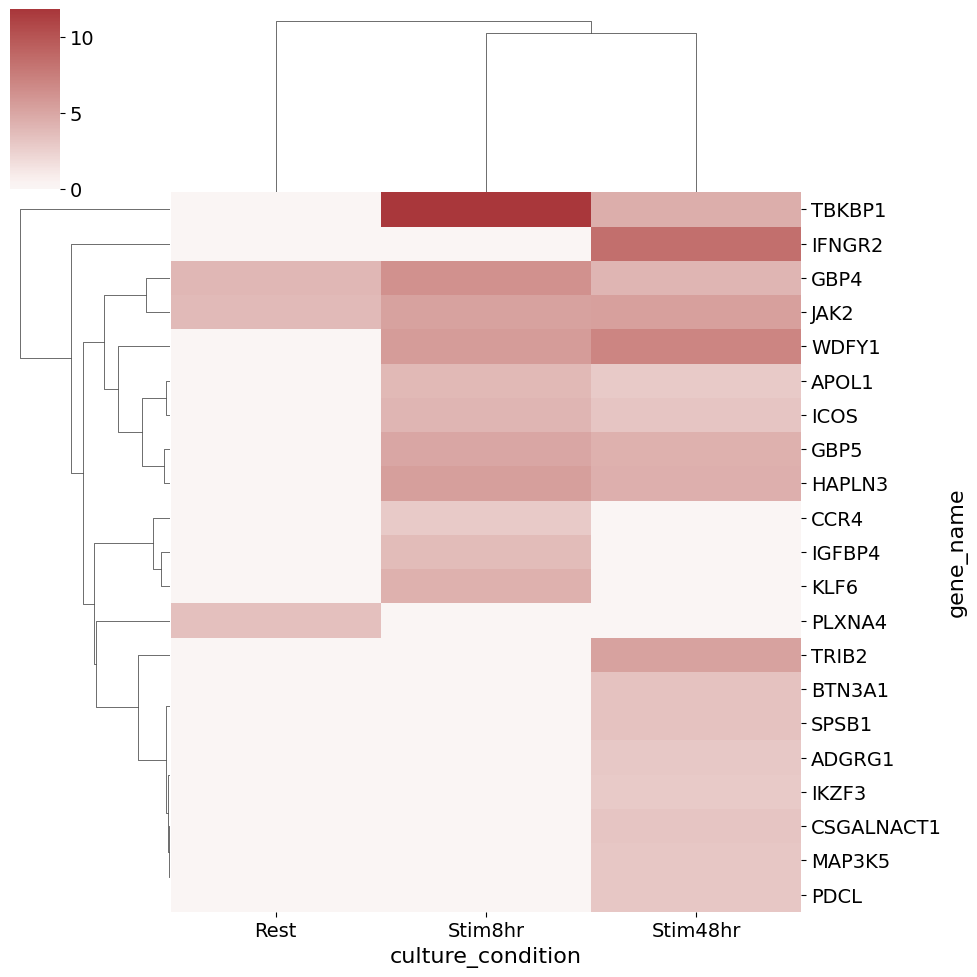

In [36]:
pl_df = de_long[de_long.gene_name.isin(sig_genes_both)]
pl_df['zscore'] = np.where(pl_df['significant'], pl_df['zscore'], 0)
pl_df = pl_df.pivot(columns='culture_condition', index='gene_name', values='zscore')

sns.clustermap(pl_df[pl_df.sum(1) > 0], cmap='vlag', center=0)

In [ ]:
adata_de.var_names = adata_de.var['gene_name'].values

Text(0.5, 1.0, 'Stim8hr')

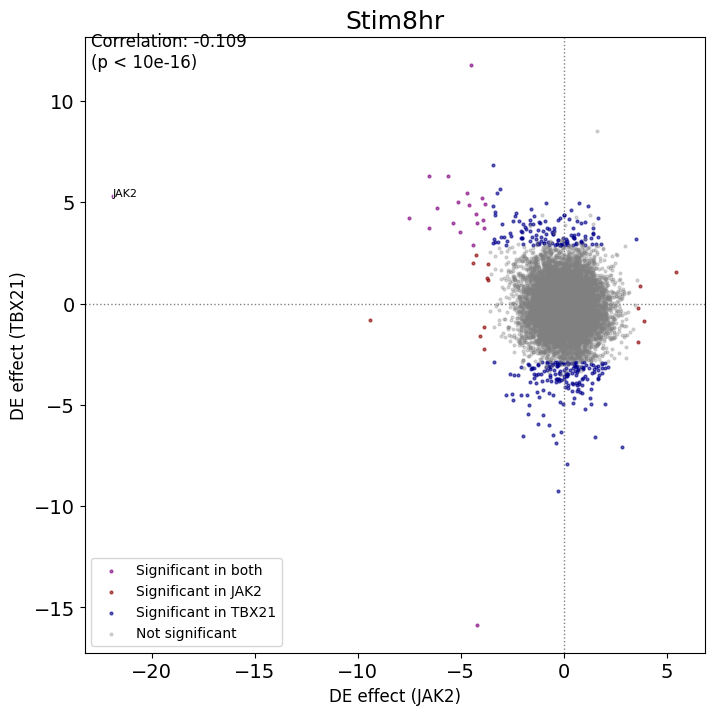

In [38]:
fix, ax = plt.subplots(figsize=(8,8))
plot_effect_comparison(
    adata_de, comparison_params = {
        'culture_condition':['Stim8hr'],
        'stat':['zscore'],
        'target_contrast_gene_name':['TBX21', 'JAK2'],
    },
    plot_correlation=True, annotate_significant = True,
    n_top_genes=10,
    ax=ax,
    annotate_genes = ['JAK2']
    )
ax.set_title('Stim8hr')


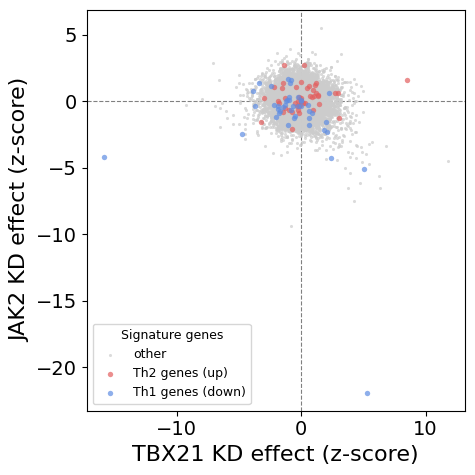

In [39]:
pl_df = get_DE_results_long(adata_de, targets = ['JAK2', 'TBX21'])
pl_df = pl_df[pl_df['culture_condition'] == 'Stim8hr'].copy()
pl_df = pl_df.pivot(index = 'gene_name', columns='target_contrast_gene_name', values='zscore')
# pl_df = pl_df.drop(['TBX21', 'JAK2'])

pl_df['color'] = 'other'
pl_df.loc[pl_df.index.isin(signature_gs_up), 'color'] = 'Th2 genes (up)'
pl_df.loc[pl_df.index.isin(signature_gs_down), 'color'] = 'Th1 genes (down)'

palette = {'other': '#cccccc', 'Th2 genes (up)': '#e35f5f', 'Th1 genes (down)': '#5f8de3'}
size_map = {'other': 5, 'Th2 genes (up)': 15, 'Th1 genes (down)': 15}

fig, ax = plt.subplots(figsize=(5, 5))

for group, color in palette.items():
    sub = pl_df[pl_df['color'] == group]
    ax.scatter(sub['TBX21'], sub['JAK2'], c=color, s=size_map[group],
               linewidths=0, alpha=0.7, label=group, zorder=2 if group == 'other' else 3)

ax.axhline(0, linestyle='--', color='grey', linewidth=0.8, zorder=1)
ax.axvline(0, linestyle='--', color='grey', linewidth=0.8, zorder=1)

ax.set_xlabel('TBX21 KD effect (z-score)')
ax.set_ylabel('JAK2 KD effect (z-score)')
ax.legend(title='Signature genes', fontsize=9, title_fontsize=9)
plt.tight_layout()
plt.show()

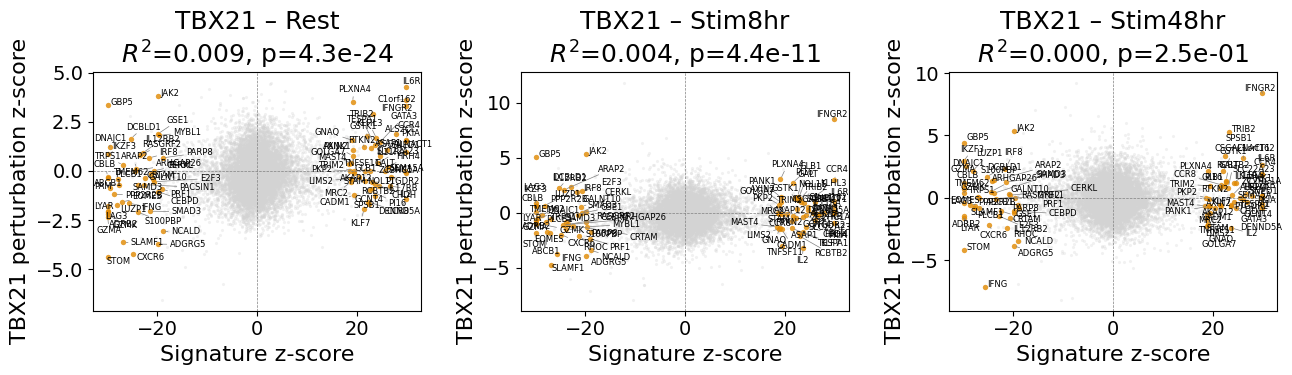

In [40]:
# Function: scatter plot of signature z-score vs perturbation effect in a given condition
from scipy.stats import pearsonr

def plot_signature_vs_target(adata_de, signature, target, condition, ax=None, n_label=10, highlight_genes=None):
    """
    Scatter plot of signature z-score (x) vs perturbation effect z-score (y)
    for a given target and culture condition.

    Parameters
    ----------
    adata_de : AnnData
        DE results object (used with get_DE_results_long).
    signature : pd.DataFrame
        Signature dataframe indexed by gene name (e.g. ota_signature),
        must contain a 'zscore' column.
    target : str
        Target gene name (e.g. 'TBX21').
    condition : str
        Culture condition to plot (e.g. 'Rest', 'Stim8hr', 'Stim48hr').
    ax : matplotlib Axes, optional
        Axes to plot on. Creates a new figure if None.
    n_label : intx
        Number of top and bottom signatuzre genes to label (ignored if highlight_genes is set).
    highlight_genes : list of str, optional
        Explicit list of genes to highlight and label. If None, defaults to
        top/bottom n_label genes by signature z-score.

    Returns
    -------
    ax : matplotlib Axes
    """
    de = get_DE_results_long(
        adata_de, targets=[target],
        effect_estimates=['log_fc', 'zscore', 'p_value'],
        target_metadata_cols=['culture_condition']
    )
    de_cond = de[de['culture_condition'] == condition]

    sig = signature.copy()
    if sig.index.name is not None and sig.index.name != 'gene_name':
        sig = sig.reset_index().rename(columns={sig.index.name: 'gene_name'})
    elif 'gene_name' not in sig.columns:
        sig = sig.reset_index().rename(columns={'index': 'gene_name'})

    pl_df = pd.merge(
        de_cond[['gene_name', 'zscore']],
        sig[['gene_name', 'zscore']],
        on='gene_name', suffixes=(f'_{target}', '_sig')
    ).dropna()
    pl_df = pl_df[pl_df['gene_name'] != target]  # exclude on-target effect

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    # Determine genes to highlight
    if highlight_genes is not None:
        highlight = pl_df['gene_name'].isin(highlight_genes)
        top_genes = pl_df['gene_name'].isin([])  # empty — no colour split
        bot_genes = pl_df['gene_name'].isin([])
        hi_color = '#e08800'
    else:
        top_genes = pl_df.nlargest(n_label, 'zscore_sig')['gene_name']
        bot_genes = pl_df.nsmallest(n_label, 'zscore_sig')['gene_name']
        highlight = pl_df['gene_name'].isin(top_genes) | pl_df['gene_name'].isin(bot_genes)
        hi_color = None  # will use two colours below

    ax.scatter(pl_df.loc[~highlight, 'zscore_sig'], pl_df.loc[~highlight, f'zscore_{target}'],
               s=5, alpha=0.3, color='lightgrey', linewidths=0)

    if highlight_genes is not None:
        ax.scatter(pl_df.loc[highlight, 'zscore_sig'], pl_df.loc[highlight, f'zscore_{target}'],
                   s=15, alpha=0.8, color=hi_color, linewidths=0, label='Highlighted genes')
    else:
        ax.scatter(pl_df.loc[pl_df['gene_name'].isin(top_genes), 'zscore_sig'],
                   pl_df.loc[pl_df['gene_name'].isin(top_genes), f'zscore_{target}'],
                   s=15, alpha=0.8, color='#e35f5f', linewidths=0, label='Top signature')
        ax.scatter(pl_df.loc[pl_df['gene_name'].isin(bot_genes), 'zscore_sig'],
                   pl_df.loc[pl_df['gene_name'].isin(bot_genes), f'zscore_{target}'],
                   s=15, alpha=0.8, color='#5f8de3', linewidths=0, label='Bottom signature')

    from adjustText import adjust_text
    texts = [
        ax.text(row['zscore_sig'], row[f'zscore_{target}'], row['gene_name'], fontsize=6)
        for _, row in pl_df[highlight].iterrows()
    ]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

    r, pval = pearsonr(pl_df['zscore_sig'], pl_df[f'zscore_{target}'])
    ax.set_title(f'{target} – {condition}\n$R^2$={r**2:.3f}, p={pval:.1e}')
    ax.set_xlabel('Signature z-score')
    ax.set_ylabel(f'{target} perturbation z-score')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    return ax


# Example: TBX21 vs Ota signature across all conditions
conditions = ['Rest', 'Stim8hr', 'Stim48hr']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cond in zip(axes, conditions):
    plot_signature_vs_target(adata_de, ota_signature, target='TBX21', condition=cond, ax=ax, highlight_genes=signature_gs_up + signature_gs_down + ['IFNG'])
plt.tight_layout()
plt.show()


<Axes: title={'center': 'JAK2 – Stim8hr\n$R^2$=0.005, p=5.1e-14'}, xlabel='Signature z-score', ylabel='JAK2 perturbation z-score'>

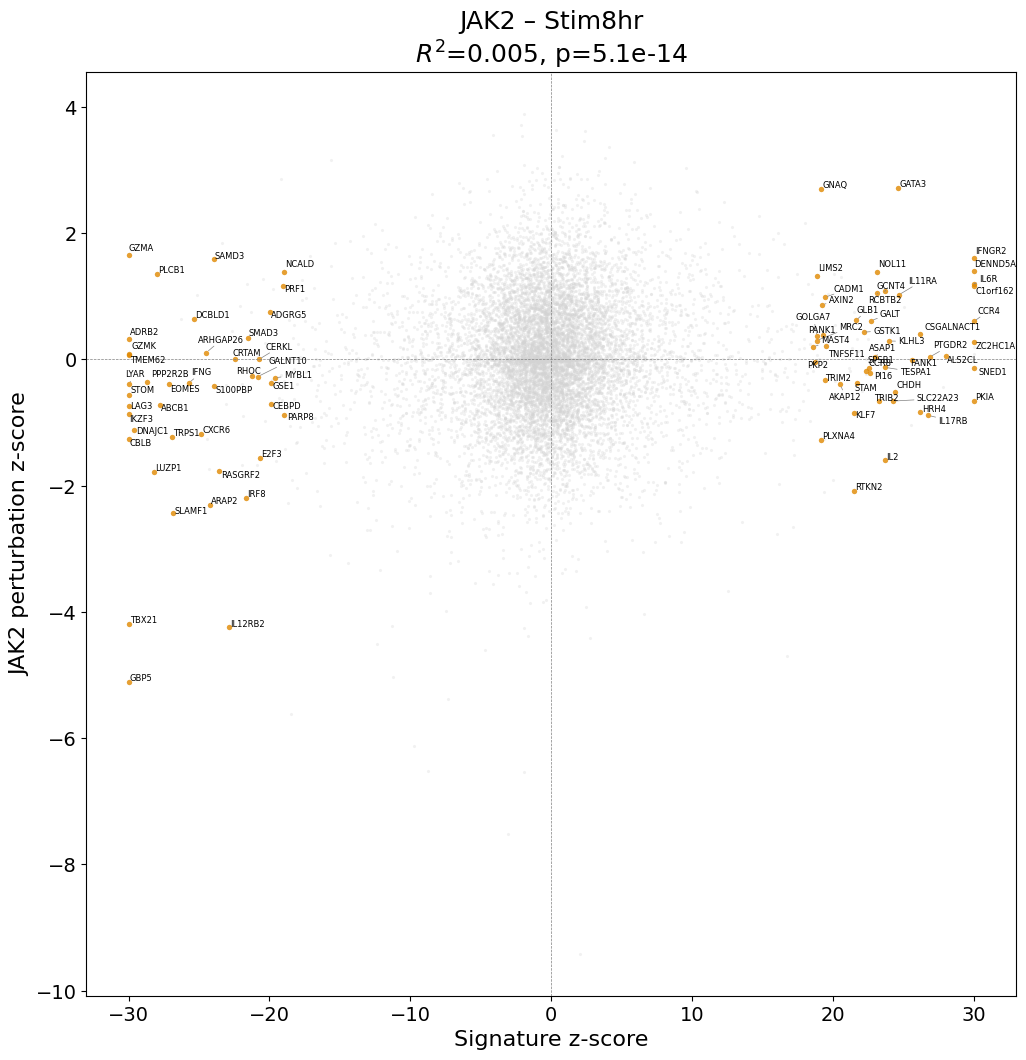

In [41]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_signature_vs_target(adata_de, ota_signature, target='JAK2', condition='Stim8hr', highlight_genes=signature_gs_up + signature_gs_down + ['IFNG'], ax=ax)

<Axes: title={'center': 'TBX21 – Stim8hr\n$R^2$=0.004, p=4.4e-11'}, xlabel='Signature z-score', ylabel='TBX21 perturbation z-score'>

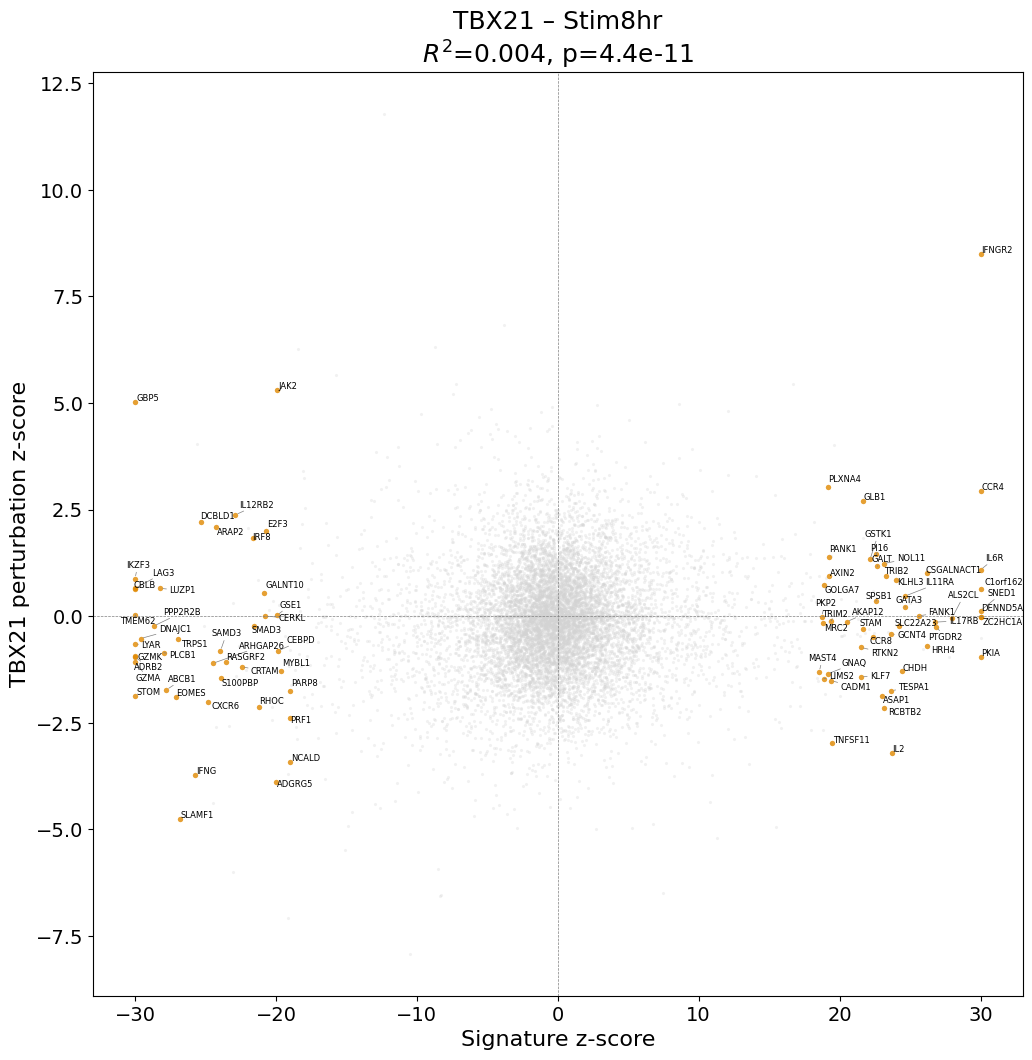

In [42]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_signature_vs_target(adata_de, ota_signature, target='TBX21', condition='Stim8hr', highlight_genes=signature_gs_up + signature_gs_down + ['IFNG'], ax=ax)

<Axes: title={'center': 'TBX21 – Stim8hr\n$R^2$=0.149, p=3.8e-37'}, xlabel='Signature z-score', ylabel='TBX21 perturbation z-score'>

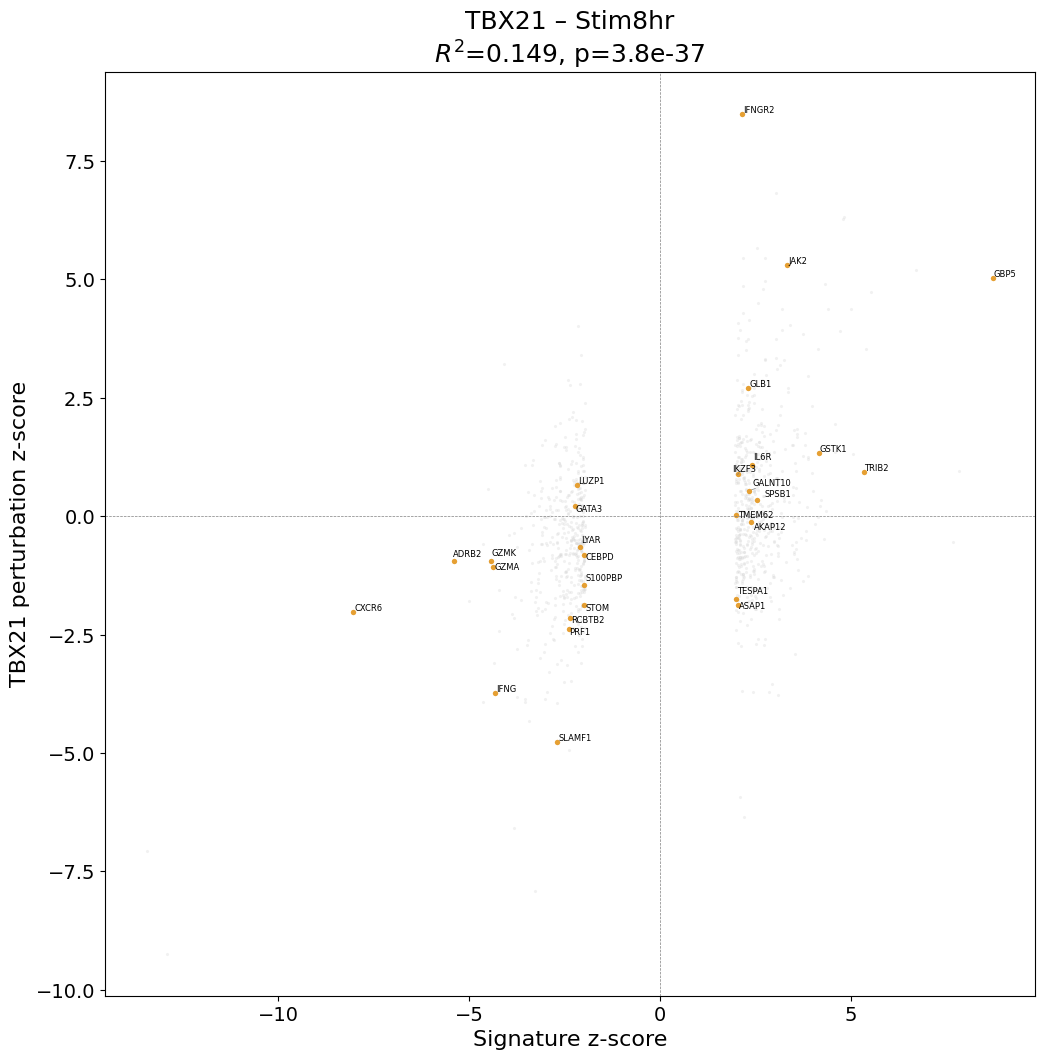

In [43]:
fig, ax = plt.subplots(figsize=(12, 12))
plot_signature_vs_target(adata_de, tbx21_weinstock, target='TBX21', condition='Stim8hr', highlight_genes=signature_gs_up + signature_gs_down + ['IFNG'], ax=ax)

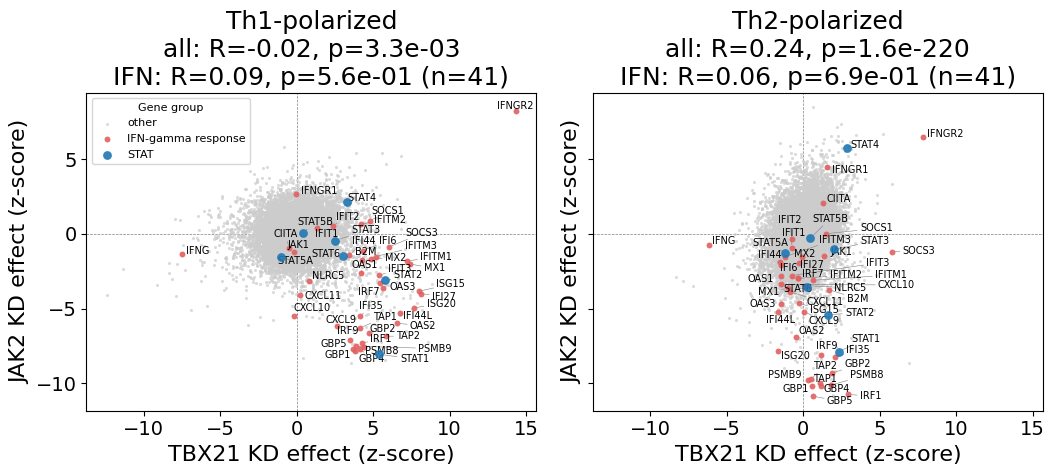

In [44]:
# JAK2 vs TBX21 KD effects in Th1- and Th2-polarized conditions (joint bulk DE).
# Mirrors the perturb-seq Stim8hr scatter above, but on res_df (Diff084/Diff089 pooled).
# Highlight STATs and IFN-gamma response genes to test whether JAK2 KD pushes them
# in the opposite direction to TBX21 KD that we saw in the non-polarized data.
from scipy.stats import pearsonr

stat_genes = ['STAT1', 'STAT2', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6']
# Hallmark IFN-gamma response (curated subset of canonical ISGs / IFNG pathway genes)
ifn_genes = [
    'IFI6', 'IFI27', 'IFI35', 'IFI44', 'IFI44L', 'IFIT1', 'IFIT2', 'IFIT3',
    'ISG15', 'ISG20', 'OAS1', 'OAS2', 'OAS3', 'MX1', 'MX2',
    'IRF1', 'IRF7', 'IRF9', 'GBP1', 'GBP2', 'GBP4', 'GBP5',
    'IFNG', 'IFNGR1', 'IFNGR2', 'JAK1',
    'IFITM1', 'IFITM2', 'IFITM3', 'NLRC5', 'TAP1', 'TAP2',
    'PSMB8', 'PSMB9', 'B2M', 'CXCL9', 'CXCL10', 'CXCL11',
    'CIITA', 'SOCS1', 'SOCS3',
]

palette = {'other': '#cccccc', 'STAT': '#1f77b4', 'IFN-gamma response': '#e35f5f'}
size_map = {'other': 5, 'STAT': 40, 'IFN-gamma response': 18}
zorder_map = {'other': 1, 'STAT': 4, 'IFN-gamma response': 3}

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

for ax, cond in zip(axes, ['Th1', 'Th2']):
    sub = res_df[(res_df['condition'] == cond) &
                 (res_df['contrast'].isin(['JAK2', 'TBX21']))].copy()
    pl_df = sub.pivot_table(index='gene_name', columns='contrast', values='zscore')
    pl_df = pl_df.dropna(subset=['JAK2', 'TBX21'])
    # Drop on-target effects (otherwise they dominate the corner)
    pl_df = pl_df.drop(['JAK2', 'TBX21'], errors='ignore')

    pl_df['group'] = 'other'
    pl_df.loc[pl_df.index.isin(ifn_genes), 'group'] = 'IFN-gamma response'
    pl_df.loc[pl_df.index.isin(stat_genes), 'group'] = 'STAT'

    for grp in ['other', 'IFN-gamma response', 'STAT']:
        d = pl_df[pl_df['group'] == grp]
        ax.scatter(d['TBX21'], d['JAK2'], c=palette[grp], s=size_map[grp],
                   alpha=0.7 if grp == 'other' else 0.9, linewidths=0,
                   label=grp, zorder=zorder_map[grp])

    # Label highlighted genes
    texts = []
    for gene, row in pl_df[pl_df['group'] != 'other'].iterrows():
        texts.append(ax.text(row['TBX21'], row['JAK2'], gene, fontsize=7))
    try:
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.4))
    except Exception:
        pass

    r_all, p_all = pearsonr(pl_df['TBX21'], pl_df['JAK2'])
    ifn = pl_df[pl_df['group'] == 'IFN-gamma response']
    if len(ifn) > 2:
        r_ifn, p_ifn = pearsonr(ifn['TBX21'], ifn['JAK2'])
        ifn_str = f"\nIFN: R={r_ifn:.2f}, p={p_ifn:.1e} (n={len(ifn)})"
    else:
        ifn_str = ""

    ax.axhline(0, color='grey', lw=0.5, ls='--', zorder=0)
    ax.axvline(0, color='grey', lw=0.5, ls='--', zorder=0)
    ax.set_xlabel('TBX21 KD effect (z-score)')
    ax.set_ylabel('JAK2 KD effect (z-score)')
    ax.set_title(f'{cond}-polarized\nall: R={r_all:.2f}, p={p_all:.1e}{ifn_str}')

axes[0].legend(fontsize=8, title='Gene group', title_fontsize=8, loc='best')
plt.tight_layout()
plt.show()


## §8 JAK2 compensation correction (Diff081)

#### JAK2 compensation correction

TBX21 knock-down leads to upregulation of JAK2 and of genes that are down-regulated upon JAK2 perturbation, consistent across datasets. This suggests TBX21 KD may trigger a compensatory increase in JAK2. To test whether this compensation confounds the TBX21→Ota-signature relationship, we fit two linear models:
- **Model 1** (uncorrected): `ota_zscore ~ TBX21_zscore`
- **Model 2** (JAK2-corrected): regress JAK2 effect out of TBX21 z-scores first, then `ota_zscore ~ TBX21_residual`

In [ ]:
n_top = 500
signature_effect_size_up = ota_signature[ota_signature['adj_p_value'] < 0.01].nlargest(n_top, 'zscore').sort_values('zscore', ascending=False)
signature_effect_size_down = ota_signature[ota_signature['adj_p_value'] < 0.01].nsmallest(n_top, 'zscore').sort_values('zscore')
signature_gs_up = signature_effect_size_up.index.tolist()
signature_gs_down = signature_effect_size_down.index.tolist()

In [ ]:
# JAK2 compensation correction: compare two linear models predicting Ota signature from TBX21 bulk DE
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# --- Prepare gene-level z-scores from bulk DE (exclude duplicated gene names) ---
def _get_bulk_zscore(res_df, contrast):
    s = (
        res_df[res_df['contrast'] == contrast]
        .set_index('gene_name')['zscore']
        .drop(contrast, errors='ignore')  # exclude on-target
    )
    dupes = s.index[s.index.duplicated(keep=False)]
    if len(dupes):
        print(f"  {contrast}: dropping {dupes.nunique()} duplicated gene names")
    return s[~s.index.duplicated(keep=False)]

tbx21_bulk = _get_bulk_zscore(res_df_diff081, 'TBX21')
jak2_bulk  = _get_bulk_zscore(res_df_diff081, 'JAK2')

# Genes significantly DE in JAK2 perturbation (used to define correction scope)
jak2_sig_genes = set(
    res_df_diff081[(res_df_diff081['contrast'] == 'JAK2') & (res_df_diff081['adj_p_value'] < 0.05) & (res_df_diff081['log_fc'] < 0)]['gene_name']
) - {'JAK2'}

# Subset to significant ota_signature genes
ota_sig = ota_signature.loc[signature_gs_up + signature_gs_down].copy()
# ota_sig = ota_signature.loc[ota_signature['adj_p_value'] < 0.01].copy()
print(f"Significant ota genes: {len(ota_sig)} / {len(ota_signature)}")
print(f"Significant JAK2 DE genes: {len(jak2_sig_genes)}")

common_genes = ota_sig.index.intersection(tbx21_bulk.index).intersection(jak2_bulk.index)
print(f"Genes in common (ota sig ∩ TBX21 ∩ JAK2): {len(common_genes)}")

ota_z   = ota_sig.loc[common_genes, 'zscore'].values
tbx21_z = tbx21_bulk.loc[common_genes].values
jak2_z  = jak2_bulk.loc[common_genes].values

# --- Model 1: ota ~ TBX21 (uncorrected) ---
m1 = LinearRegression().fit(tbx21_z.reshape(-1, 1), ota_z)
r2_m1 = m1.score(tbx21_z.reshape(-1, 1), ota_z)
r_m1, _ = pearsonr(tbx21_z, ota_z)

# --- Model 2: regress JAK2 out of TBX21 only for JAK2-significant genes ---
# For genes significantly DE in JAK2: subtract predicted JAK2 contribution
# For all other genes: leave TBX21 z-score unchanged
jak2_correction_mask = pd.Index(common_genes).isin(jak2_sig_genes)
m_jak2 = LinearRegression().fit(jak2_z[jak2_correction_mask].reshape(-1, 1),
                                 tbx21_z[jak2_correction_mask])
tbx21_corrected = tbx21_z.copy()
tbx21_corrected[jak2_correction_mask] = 0
# tbx21_corrected[jak2_correction_mask] -= m_jak2.predict(
#     jak2_z[jak2_correction_mask].reshape(-1, 1)
# )

m2 = LinearRegression().fit(tbx21_corrected.reshape(-1, 1), ota_z)
r2_m2 = m2.score(tbx21_corrected.reshape(-1, 1), ota_z)
r_m2, _ = pearsonr(tbx21_corrected, ota_z)

# --- JAK2 vs TBX21 among JAK2-significant genes (compensation relationship) ---
r_comp, _ = pearsonr(jak2_z[jak2_correction_mask], tbx21_z[jak2_correction_mask])

print(f"\nJAK2 vs TBX21 z-score (JAK2-sig genes): R={r_comp:.3f}")
print(f"Model 1 (uncorrected):    R={r_m1:.3f}, R²={r2_m1:.3f}")
print(f"Model 2 (JAK2-corrected): R={r_m2:.3f}, R²={r2_m2:.3f}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: JAK2 vs TBX21 z-score for JAK2-significant genes (compensation)
axes[0].scatter(jak2_z[~jak2_correction_mask], tbx21_z[~jak2_correction_mask],
                s=5, alpha=0.2, linewidths=0, color='lightgrey', label='JAK2 non-sig')
axes[0].scatter(jak2_z[jak2_correction_mask], tbx21_z[jak2_correction_mask],
                s=15, alpha=0.7, linewidths=0, color='#e08800', label='JAK2 sig')
axes[0].set_xlabel('JAK2 perturbation z-score')
axes[0].set_ylabel('TBX21 perturbation z-score')
axes[0].set_title(f'JAK2 vs TBX21 (JAK2-sig genes)\nPearson R={r_comp:.3f}')
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].axvline(0, color='grey', lw=0.5, ls='--')
axes[0].legend(fontsize=7, markerscale=1.5)

# Panel 2: Model 1 – ota vs TBX21 (uncorrected)
axes[1].scatter(tbx21_z, ota_z, s=5, alpha=0.3, linewidths=0, color='#5f8de3')
axes[1].scatter(tbx21_z[jak2_correction_mask], ota_z[jak2_correction_mask],
                s=15, alpha=0.7, linewidths=0, color='#e35f5f', label='JAK2-corrected genes')
axes[1].set_xlabel('TBX21 perturbation z-score')
axes[1].set_ylabel('Ota signature z-score')
axes[1].set_title(f'Model 1 – uncorrected\n$R^2$={r2_m1:.3f}  (R={r_m1:.3f})')
axes[1].axhline(0, color='grey', lw=0.5, ls='--')
axes[1].axvline(0, color='grey', lw=0.5, ls='--')

# Panel 3: Model 2 – ota vs TBX21 corrected for JAK2
axes[2].scatter(tbx21_corrected[~jak2_correction_mask], ota_z[~jak2_correction_mask],
                s=5, alpha=0.2, linewidths=0, color='lightgrey')
axes[2].scatter(tbx21_corrected[jak2_correction_mask], ota_z[jak2_correction_mask],
                s=15, alpha=0.7, linewidths=0, color='#e35f5f', label='JAK2-corrected genes')
axes[2].set_xlabel('TBX21 z-score (JAK2-corrected)')
axes[2].set_ylabel('Ota signature z-score')
axes[2].set_title(f'Model 2 – JAK2-corrected\n$R^2$={r2_m2:.3f}  (R={r_m2:.3f})')
axes[2].axhline(0, color='grey', lw=0.5, ls='--')
axes[2].axvline(0, color='grey', lw=0.5, ls='--')
axes[2].legend(fontsize=7, markerscale=1.5)

plt.tight_layout()
plt.show()


In [ ]:
plt.scatter(tbx21_z[jak2_correction_mask], tbx21_z[jak2_correction_mask] - jak2_z[jak2_correction_mask])

In [ ]:
m_jak2.coef_

In [ ]:
import pickle
with open('./results/polarization_prediction_condition_comparison.models.pkl', 'rb') as f:
    comparison_results = pickle.load(f)

In [ ]:
stim_model = comparison_results['ota_Stim8hr']

In [ ]:
pert2state_model = stim_model[0]
perts = pert2state_model.get_coefs().index
pca_df = pd.DataFrame(pert2state_model.pcas[1].components_, columns=perts).T

In [ ]:
pd.DataFrame(pert2state_model.models[1].coef_).reset_index().sort_values(0)

In [ ]:
pca_df[43].sort_values(ascending=True)[0:30]

In [ ]:
ax = sns.scatterplot(x=pert2state_model.models[1].coef_, y=pca_df.loc['FAM120A_Stim8hr'].values)
for i, (x, y) in enumerate(zip(pert2state_model.models[0].coef_, pca_df.loc['FAM120A_Stim8hr'].values)):
    ax.annotate(f'{i}', (x, y), fontsize=8, alpha=0.6)

sns.scatterplot(x=pert2state_model.models[1].coef_, y=pca_df.loc['STAT6_Stim8hr'].values, ax=ax)
for i, (x, y) in enumerate(zip(pert2state_model.models[0].coef_, pca_df.loc['STAT6_Stim8hr'].values)):
    ax.annotate(f'{i}', (x, y), fontsize=8, alpha=0.6)

In [ ]:
ax = sns.scatterplot(x=pca_df.loc['JAK2_Stim8hr'].values, y=pca_df.loc['TBX21_Stim8hr'].values)
for i, (x, y) in enumerate(zip(pca_df.loc['JAK2_Stim8hr'].values, pca_df.loc['TBX21_Stim8hr'].values)):
    ax.annotate(f'{i}', (x, y), fontsize=8, alpha=0.6)
# sns.scatterplot(x=pert2state_model.models[1].coef_, y=pca_df.loc['JAK2_Stim8hr'].values, ax=ax)
# for i, (x, y) in enumerate(zip(pert2state_model.models[0].coef_, pca_df.loc['JAK2_Stim8hr'].values)):
#     ax.annotate(f'{i}', (x, y), fontsize=8, alpha=0.6)

In [ ]:
# Plotting as barplots using seaborn (or fallback to plt.bar if seaborn is not imported)
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

sns.barplot(x=pca_df.columns, y=pca_df.loc['TBX21_Stim8hr'].values, ax=axes[0], color='C0')
axes[0].set_ylabel('TBX21_Stim8hr')
axes[0].set_title('PCA Component Weights: TBX21_Stim8hr')

sns.barplot(x=pca_df.columns, y=pca_df.loc['JAK2_Stim8hr'].values, ax=axes[1], color='C1')
axes[1].set_ylabel('JAK2_Stim8hr')
axes[1].set_title('PCA Component Weights: JAK2_Stim8hr')

plt.tight_layout()
plt.show()

## §10 GO enrichment for novel regulators

For each of the novel TFs validated here (ZMYND8, KDM1A, NAB2, MED24, NKTR), run a GO Biological Process / Hallmark enrichment on the union of significant DE genes (adj p < 0.1) across all three polarization conditions (Th0, Th1, Th2). Background is the set of genes tested in the DE table for that regulator. Same gseapy.enrichr setup as `pert2state_polarization.ipynb`.

In [15]:
# GO BP gene sets only -- skip Msigdb fetch (network/SSL issue on this
# machine). The local GMT below is what `pert2state_polarization.ipynb`
# uses for its GO enrichment.
import gseapy as gp

def parse_gene_sets(filename):
    gene_sets = {}
    with open(filename, 'r') as f:
        for line in f:
            terms = line.strip().split('\t')
            gene_sets[terms[0]] = terms[2:]
    return gene_sets

OAKPATH = '/mnt/oak/'
GO_sets = parse_gene_sets(f'{OAKPATH}/users/emma/data/GO_Biological_Process_2023.txt')

In [16]:
# Pool significant DE genes across the three polarization conditions for
# each novel regulator, stratified by direction of effect: 'up' = log_fc > 0
# (induced upon KD), 'down' = log_fc < 0 (repressed upon KD). Run a
# separate enrichment per (regulator, direction). Background is the set of
# genes tested for that regulator (any condition); the on-target gene is
# excluded from both gene-list and background since the self-KD effect
# is uninformative for downstream interpretation.
NOVEL_REGULATORS = ['ZMYND8', 'KDM1A', 'NAB2', 'MED24', 'NKTR']
SIG_THRESHOLD = 0.1
DIRECTIONS = ['up', 'down']

def _split_dir(sub, threshold):
    sig = sub[sub['adj_p_value'] < threshold].dropna(subset=['gene_name', 'log_fc'])
    return {
        'up':   sig.loc[sig['log_fc'] > 0, 'gene_name'].unique().tolist(),
        'down': sig.loc[sig['log_fc'] < 0, 'gene_name'].unique().tolist(),
    }

enrich_results = {}  # keys: (regulator, direction)
for reg in NOVEL_REGULATORS:
    sub = res_df[res_df['contrast'] == reg]
    if sub.empty:
        print(f'{reg}: no DE rows in res_df -- skipping')
        continue
    bg_genes = sub['gene_name'].dropna().unique().tolist()
    bg_genes = [g for g in bg_genes if g != reg]
    by_dir = _split_dir(sub, SIG_THRESHOLD)
    for direction in DIRECTIONS:
        sig_genes = [g for g in by_dir[direction] if g != reg]
        if len(sig_genes) < 5:
            print(f'{reg} ({direction}): only {len(sig_genes)} sig genes -- skipping')
            continue
        enr = gp.enrichr(
            gene_list=sig_genes,
            gene_sets=GO_sets,
            organism='human',
            outdir=None,
            background=bg_genes,
        )
        enr.results['regulator'] = reg
        enr.results['direction'] = direction
        enrich_results[(reg, direction)] = enr.results
        n_sig_terms = (enr.results['Adjusted P-value'] < 0.1).sum()
        print(f'{reg} ({direction}): {len(sig_genes)} DE genes (bg={len(bg_genes)}), '
              f'{n_sig_terms} terms at adj p < 0.1')

all_enrich = (pd.concat(enrich_results.values(), ignore_index=True)
              if enrich_results else pd.DataFrame())
if not all_enrich.empty:
    all_enrich.to_csv('./results/bulkRNAseq_novel_regulators_GO_enrichment.csv', index=False)
    print(f'\nWrote {all_enrich.shape[0]} rows to '
          f'bulkRNAseq_novel_regulators_GO_enrichment.csv')

ZMYND8 (up): 990 DE genes (bg=17261), 75 terms at adj p < 0.1
ZMYND8 (down): 901 DE genes (bg=17261), 90 terms at adj p < 0.1
KDM1A (up): 3556 DE genes (bg=17261), 45 terms at adj p < 0.1
KDM1A (down): 2251 DE genes (bg=17261), 415 terms at adj p < 0.1
NAB2 (up): 118 DE genes (bg=17261), 98 terms at adj p < 0.1
NAB2 (down): 37 DE genes (bg=17261), 17 terms at adj p < 0.1
MED24 (up): 2484 DE genes (bg=17261), 54 terms at adj p < 0.1
MED24 (down): 2182 DE genes (bg=17261), 176 terms at adj p < 0.1
NKTR (up): 216 DE genes (bg=17261), 3 terms at adj p < 0.1
NKTR (down): 260 DE genes (bg=17261), 1 terms at adj p < 0.1

Wrote 29546 rows to bulkRNAseq_novel_regulators_GO_enrichment.csv


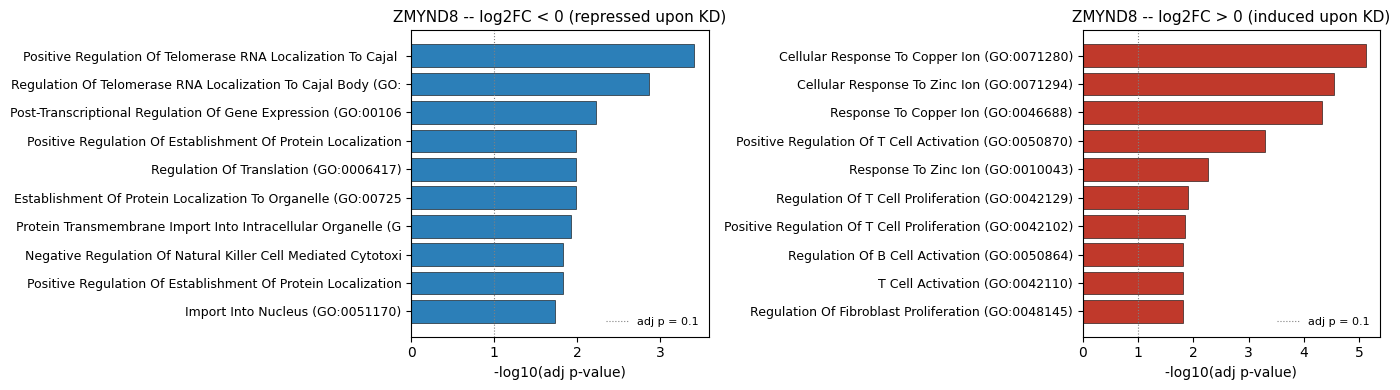

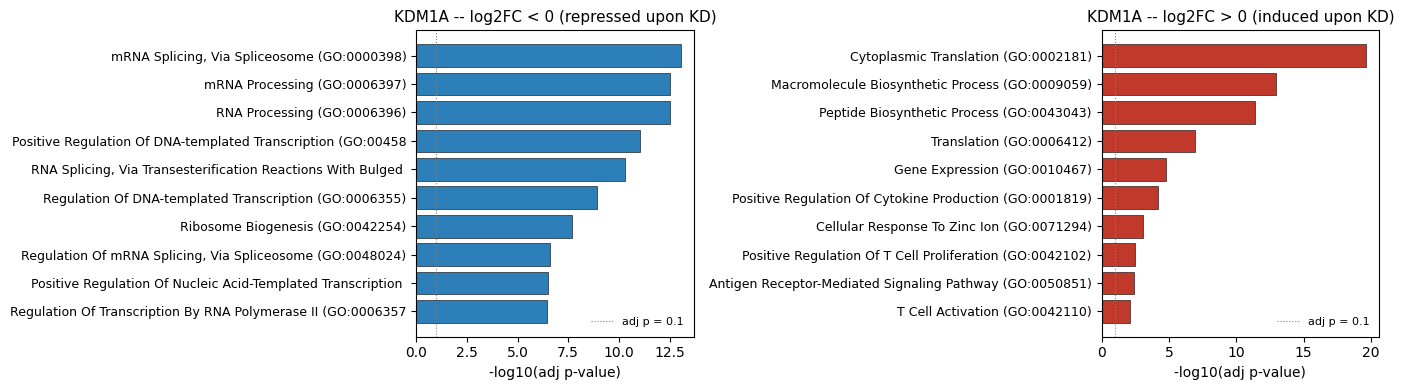

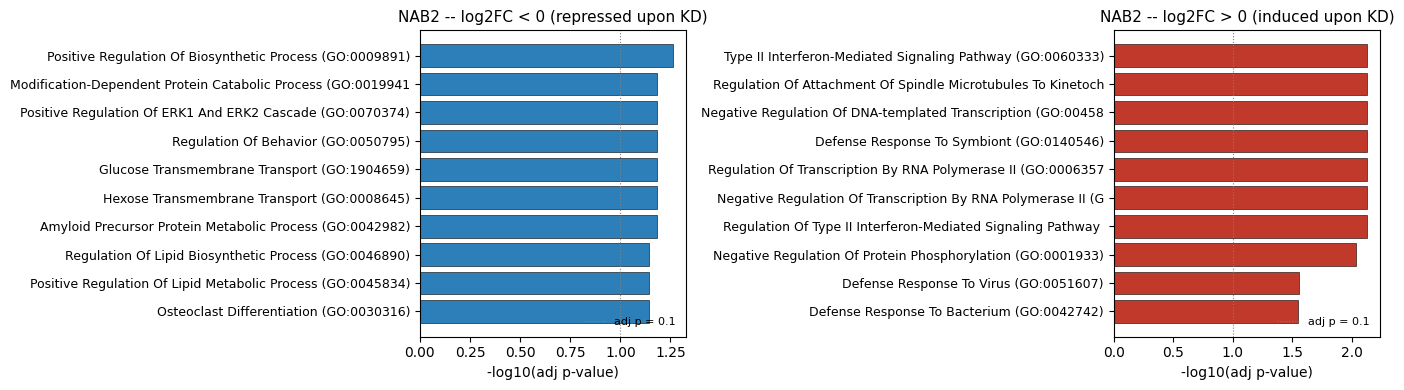

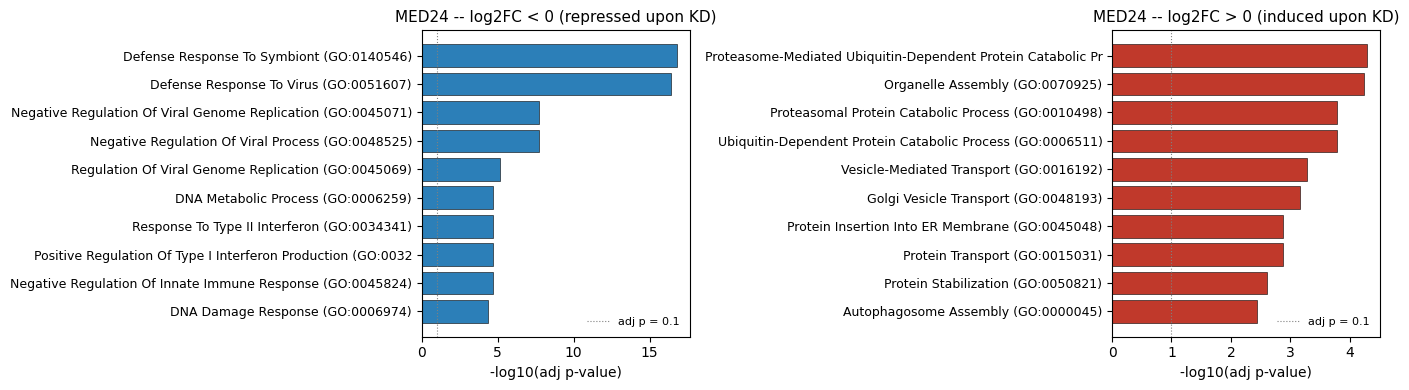

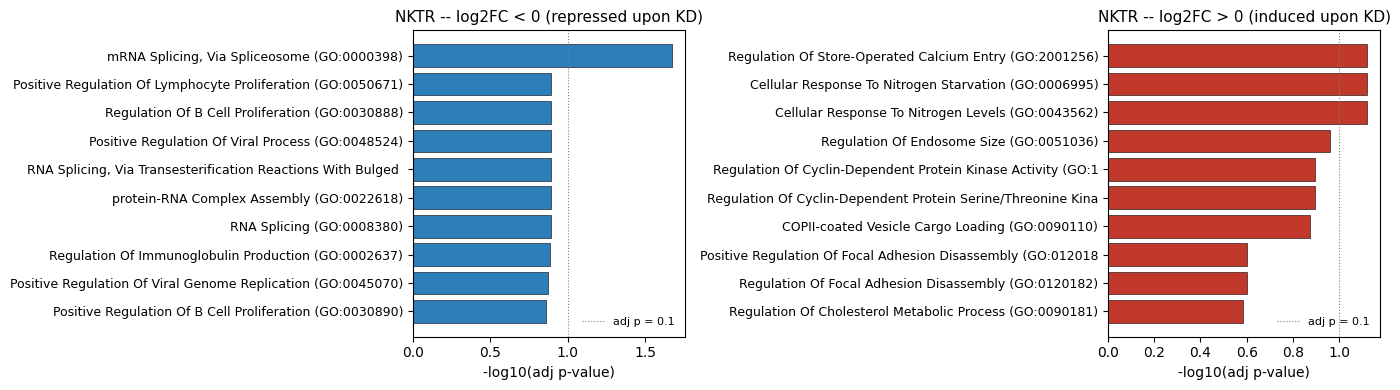

In [17]:
# Top N GO BP terms per regulator, stratified by direction (up / down).
# One row per regulator; two horizontal bar panels (down on the left,
# up on the right) -- bars coloured by direction.
N_TOP = 10
DIR_COLOR = {'up': '#c0392b', 'down': '#2c7fb8'}
DIR_LABEL = {'up': 'log2FC > 0 (induced upon KD)',
             'down': 'log2FC < 0 (repressed upon KD)'}

for reg in NOVEL_REGULATORS:
    if not any((reg, d) in enrich_results for d in DIRECTIONS):
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, direction in zip(axes, ['down', 'up']):
        if (reg, direction) not in enrich_results:
            ax.set_visible(False)
            continue
        df = (enrich_results[(reg, direction)]
              .sort_values('Adjusted P-value')
              .head(N_TOP)
              .iloc[::-1]
              .copy())
        df['neglog10_padj'] = -np.log10(df['Adjusted P-value'].clip(lower=1e-300))
        ax.barh(range(len(df)), df['neglog10_padj'].values,
                color=DIR_COLOR[direction], edgecolor='black', linewidth=0.4)
        ax.set_yticks(range(len(df)))
        ax.set_yticklabels([t[:60] for t in df['Term']], fontsize=9)
        ax.axvline(-np.log10(0.1), color='grey', ls=':', lw=0.8,
                   label='adj p = 0.1')
        ax.set_xlabel('-log10(adj p-value)')
        ax.set_title(f'{reg} -- {DIR_LABEL[direction]}', fontsize=11)
        ax.legend(loc='lower right', fontsize=8, frameon=False)
    plt.tight_layout()
    plt.savefig(f'./results/GO_enrichment_{reg}.pdf')
    plt.show()

In [29]:
enrich_results[('NAB2', 'up')].sort_values('Adjusted P-value')[0:20]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,regulator,direction
1170,gs_ind_0,Type II Interferon-Mediated Signaling Pathway ...,3/9,0.000025,0.007397,79.895105,845.387269,IFNGR2;SP100;IRF1,NAB2,up
811,gs_ind_0,Regulation Of Attachment Of Spindle Microtubul...,3/9,0.000025,0.007397,79.895105,845.387269,NEK2;SPAG5;CCNB1,NAB2,up
339,gs_ind_0,Negative Regulation Of DNA-templated Transcrip...,20/969,0.000009,0.007397,3.549688,41.412416,TBX21;KLF11;NAB1;CEBPB;SMURF2;DNMT3A;ZNF512B;Z...,NAB2,up
126,gs_ind_0,Defense Response To Symbiont (GO:0140546),7/137,0.000043,0.007397,8.769393,88.146619,MX1;PRF1;DDX60;IRF1;OAS1;OAS3;USP27X,NAB2,up
1057,gs_ind_0,Regulation Of Transcription By RNA Polymerase ...,28/1855,0.000041,0.007397,2.639359,26.659320,AEBP2;KLF11;TNIP3;TBX21;CEBPB;MET;SMURF2;DNMT3...,NAB2,up
437,gs_ind_0,Negative Regulation Of Transcription By RNA Po...,16/715,0.000029,0.007397,3.784365,39.570535,UHRF1;TBX21;KLF11;HMGB2;KLF10;SP100;CEBPB;PPAR...,NAB2,up
1069,gs_ind_0,Regulation Of Type II Interferon-Mediated Sign...,3/10,0.000036,0.007397,69.238384,708.276912,PARP9;PARP14;PPARG,NAB2,up
405,gs_ind_0,Negative Regulation Of Protein Phosphorylation...,7/145,0.000062,0.009288,8.258973,80.033639,PPARG;GNAQ;PRKCD;PRR5L;NIBAN1;CALM2;DBNDD2,NAB2,up
128,gs_ind_0,Defense Response To Virus (GO:0051607),7/176,0.000207,0.027651,6.736180,57.134671,MX1;PRF1;DDX60;IRF1;OAS1;OAS3;USP27X,NAB2,up
123,gs_ind_0,Defense Response To Bacterium (GO:0042742),6/127,0.000237,0.028461,8.094833,67.571848,CEBPB;SPN;PRKCD;OAS1;OAS3;HMGB2,NAB2,up


In [33]:
res_df[res_df['gene_name'] == 'EGR2'].sort_values('adj_p_value')

,variable,gene_name,contrast,target_contrast_gene_name,condition,batch,baseMean,log_fc,lfcSE,stat,zscore,p_value,adj_p_value
34781,ENSG00000122877,EGR2,MED24,MED24,Th0,"Diff081,Diff089",690.625806,0.499665,0.108829,4.591300,4.591300,0.000004,0.000075
17871,ENSG00000122877,EGR2,GATA3,GATA3,Th0,"Diff081,Diff084",690.625806,-0.399868,0.089465,-4.469533,-4.469533,0.000008,0.000128
485906,ENSG00000122877,EGR2,STAT6,STAT6,Th1,Diff089,1024.173848,0.783356,0.176845,4.429611,4.429611,0.000009,0.002127
372441,ENSG00000122877,EGR2,STYXL1,STYXL1,Th1,Diff084,1024.173848,0.472082,0.124051,3.805541,3.805541,0.000141,0.003660
104082,ENSG00000122877,EGR2,MTA2,MTA2,Th0,Diff081,690.625806,0.429633,0.148469,2.893749,2.893749,0.003807,0.027722
85994,ENSG00000122877,EGR2,JAK2,JAK2,Th0,"Diff081,Diff084",690.625806,0.239418,0.088710,2.698869,2.698869,0.006958,0.095014
340616,ENSG00000122877,EGR2,GATA3,GATA3,Th1,Diff084,1024.173848,-0.301806,0.123029,-2.453120,-2.453120,0.014162,0.161856
437476,ENSG00000122877,EGR2,ZMYND8,ZMYND8,Th1,Diff084,1024.173848,0.337476,0.120355,2.804008,2.804008,0.005047,0.161922
667903,ENSG00000122877,EGR2,KDM1A,KDM1A,Th2,Diff089,1097.189563,-0.409445,0.192232,-2.129948,-2.129948,0.033176,0.175011
650428,ENSG00000122877,EGR2,MED24,MED24,Th2,Diff089,1097.189563,0.417398,0.189642,2.200981,2.200981,0.027737,0.235298


In [34]:

# Compare NAB2 KD signature to EGR1, EGR2 KD signatures in Stim8hr (perturb-seq).
# NAB2 is an EGR1/2 corepressor -- if NAB2 KD derepresses EGR targets, NAB2 KD
# and EGR1/2 KD should be ANTI-correlated (since EGR1/2 KD reduces EGR-driven
# transcription, while NAB2 KD increases it).
import numpy as np
import pandas as pd
import anndata, scipy.stats

# Load perturb-seq DE results if not already loaded
try:
    adata_de
except NameError:
    adata_de = anndata.read_h5ad('/mnt/oak/users/emma/data/GWT/CD4i_final/DE_results_all_confounders/CD4i_final.merged_DE_results.h5ad')

if 'zscore' not in adata_de.layers:
    adata_de.layers['zscore'] = adata_de.layers['log_fc'] / adata_de.layers['lfcSE']

# Filter to Stim8hr and the three perturbations of interest.
targets = ['NAB2', 'EGR1', 'EGR2']
mask = (adata_de.obs['culture_condition'] == 'Stim8hr') & adata_de.obs['target_contrast_gene_name'].isin(targets)
adata_sub = adata_de[mask].copy()
print('rows present:')
print(adata_sub.obs[['target_contrast_gene_name', 'culture_condition']].value_counts())
print()

# For each pert, take the per-gene z-score vector (one row per pert in Stim8hr).
def vec(pert):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == pert]
    if len(rows) == 0:
        return None
    return pd.Series(adata_sub[rows[0]].layers['zscore'].toarray().ravel() if hasattr(adata_sub[rows[0]].layers['zscore'], 'toarray') else np.asarray(adata_sub[rows[0]].layers['zscore']).ravel(),
                     index=adata_sub.var.index)

vectors = {p: vec(p) for p in targets}
present = {p: v for p, v in vectors.items() if v is not None}
print('present perts:', list(present.keys()))


rows present:
target_contrast_gene_name  culture_condition
EGR1                       Stim8hr              1
EGR2                       Stim8hr              1
NAB2                       Stim8hr              1
Name: count, dtype: int64

present perts: ['NAB2', 'EGR1', 'EGR2']


In [35]:

# Pairwise correlations on per-gene z-scores (Stim8hr).
# Self-target genes excluded for each comparison so the on-target effect doesn't dominate.
df = pd.DataFrame(present)

print('==== full-transcriptome (all genes) ====')
for a, b in [('NAB2', 'EGR1'), ('NAB2', 'EGR2'), ('EGR1', 'EGR2')]:
    sub = df[[a, b]].dropna()
    sub = sub[~sub.index.isin([a, b])]  # drop on-target genes
    r_p = scipy.stats.pearsonr(sub[a], sub[b])
    r_s = scipy.stats.spearmanr(sub[a], sub[b])
    print(f'{a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r_p.statistic:+.3f} (p={r_p.pvalue:.1e})  Spearman r={r_s.statistic:+.3f}')

# Now restrict to genes with substantial signal in either pert (|z|>2)
print('\n==== restricted to genes with |z|>2 in either pert ====')
for a, b in [('NAB2', 'EGR1'), ('NAB2', 'EGR2'), ('EGR1', 'EGR2')]:
    sub = df[[a, b]].dropna()
    sub = sub[~sub.index.isin([a, b])]
    sub = sub[(sub[a].abs() > 2) | (sub[b].abs() > 2)]
    r_p = scipy.stats.pearsonr(sub[a], sub[b])
    print(f'{a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r_p.statistic:+.3f} (p={r_p.pvalue:.1e})')


==== full-transcriptome (all genes) ====
 NAB2 vs EGR1   n=12,352  Pearson r=-0.071 (p=2.0e-15)  Spearman r=-0.076
 NAB2 vs EGR2   n=12,349  Pearson r=+0.049 (p=3.9e-08)  Spearman r=+0.064
 EGR1 vs EGR2   n=12,351  Pearson r=+0.165 (p=6.5e-76)  Spearman r=+0.148

==== restricted to genes with |z|>2 in either pert ====
 NAB2 vs EGR1   n=1,708  Pearson r=-0.083 (p=5.7e-04)
 NAB2 vs EGR2   n=2,629  Pearson r=+0.049 (p=1.2e-02)
 EGR1 vs EGR2   n=2,279  Pearson r=+0.214 (p=4.8e-25)


In [36]:

# Sanity check: how much DE signal does each pert actually have in Stim8hr?
import numpy as np
def stats_for(p):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == p]
    z = np.asarray(adata_sub[rows[0]].layers['zscore'])
    p_adj = np.asarray(adata_sub[rows[0]].layers['adj_p_value'])
    z = np.ravel(z); p_adj = np.ravel(p_adj)
    n_sig = (p_adj < 0.1).sum()
    n_up  = ((p_adj < 0.1) & (z > 0)).sum()
    n_dn  = ((p_adj < 0.1) & (z < 0)).sum()
    return n_sig, n_up, n_dn

for p in ['NAB2', 'EGR1', 'EGR2']:
    n_sig, n_up, n_dn = stats_for(p)
    print(f'{p}: {n_sig} sig genes (up={n_up}, down={n_dn}) at adj p<0.1')


NAB2: 318 sig genes (up=230, down=88) at adj p<0.1
EGR1: 7 sig genes (up=2, down=5) at adj p<0.1
EGR2: 876 sig genes (up=415, down=461) at adj p<0.1


In [ ]:

# Compare NAB2 vs CHD4 KD in Stim8hr.
# Mechanistic prior: NAB2 recruits the NuRD complex via CHD4 to repress EGR1/2 targets.
# So NAB2 KD and CHD4 KD might produce similar (correlated) signatures.
import numpy as np
import pandas as pd
import scipy.stats

# Add CHD4 to the comparison
mask = (adata_de.obs['culture_condition'] == 'Stim8hr') & adata_de.obs['target_contrast_gene_name'].isin(['NAB2', 'CHD4', 'EGR1', 'EGR2'])
adata_sub = adata_de[mask].copy()
print(adata_sub.obs[['target_contrast_gene_name','culture_condition']].value_counts())

def vec(pert):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == pert]
    if len(rows) == 0: return None
    z = adata_sub[rows[0]].layers['zscore']
    z = np.ravel(z.toarray() if hasattr(z, 'toarray') else np.asarray(z))
    return pd.Series(z, index=adata_sub.var.index)

vectors = {p: vec(p) for p in ['NAB2', 'CHD4', 'EGR1', 'EGR2']}
present = {p: v for p, v in vectors.items() if v is not None}
df = pd.DataFrame(present)

def stats_for(p):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == p]
    z = np.ravel(np.asarray(adata_sub[rows[0]].layers['zscore']))
    pa = np.ravel(np.asarray(adata_sub[rows[0]].layers['adj_p_value']))
    return ((pa<0.1).sum(), ((pa<0.1)&(z>0)).sum(), ((pa<0.1)&(z<0)).sum())

print('\n==== DE counts (Stim8hr, adj p < 0.1) ====')
for p in present:
    n,u,d = stats_for(p)
    print(f'  {p}: {n} sig (up={u}, down={d})')

print('\n==== Pairwise Pearson r on per-gene z-scores (Stim8hr, target genes excluded) ====')
pairs = [('NAB2','CHD4'), ('NAB2','EGR1'), ('NAB2','EGR2'), ('CHD4','EGR1'), ('CHD4','EGR2'), ('EGR1','EGR2')]
for a,b in pairs:
    if a not in df or b not in df: continue
    sub = df[[a,b]].dropna()
    sub = sub[~sub.index.isin([a,b])]
    r = scipy.stats.pearsonr(sub[a], sub[b])
    rs = scipy.stats.spearmanr(sub[a], sub[b])
    print(f'  {a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r.statistic:+.3f} (p={r.pvalue:.1e})  Spearman r={rs.statistic:+.3f}')

print('\n==== Restricted to genes with |z|>2 in either pert ====')
for a,b in pairs:
    if a not in df or b not in df: continue
    sub = df[[a,b]].dropna()
    sub = sub[~sub.index.isin([a,b])]
    sub = sub[(sub[a].abs()>2)|(sub[b].abs()>2)]
    r = scipy.stats.pearsonr(sub[a], sub[b])
    print(f'  {a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r.statistic:+.3f} (p={r.pvalue:.1e})')


In [ ]:

# Compare NAB2 vs CHD4 KD in Stim8hr (mechanistic prior: NAB2 recruits NuRD via CHD4
# to repress EGR1/2 targets, so the two KDs might phenocopy each other).
import numpy as np
import pandas as pd
import scipy.stats

mask = (adata_de.obs['culture_condition'] == 'Stim8hr') & adata_de.obs['target_contrast_gene_name'].isin(['NAB2', 'CHD4', 'EGR1', 'EGR2'])
adata_sub = adata_de[mask].copy()
print(adata_sub.obs[['target_contrast_gene_name','culture_condition']].value_counts())

def vec(pert):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == pert]
    if len(rows) == 0: return None
    z = adata_sub[rows[0]].layers['zscore']
    z = np.ravel(z.toarray() if hasattr(z, 'toarray') else np.asarray(z))
    return pd.Series(z, index=adata_sub.var.index)

vectors = {p: vec(p) for p in ['NAB2', 'CHD4', 'EGR1', 'EGR2']}
present = {p: v for p, v in vectors.items() if v is not None}
df = pd.DataFrame(present)

def stats_for(p):
    rows = adata_sub.obs.index[adata_sub.obs['target_contrast_gene_name'] == p]
    z = np.ravel(np.asarray(adata_sub[rows[0]].layers['zscore']))
    pa = np.ravel(np.asarray(adata_sub[rows[0]].layers['adj_p_value']))
    return ((pa<0.1).sum(), ((pa<0.1)&(z>0)).sum(), ((pa<0.1)&(z<0)).sum())

print('\n==== DE counts (Stim8hr, adj p < 0.1) ====')
for p in present:
    n,u,d = stats_for(p)
    print(f'  {p}: {n} sig (up={u}, down={d})')

print('\n==== Pairwise Pearson r on per-gene z-scores (target genes excluded) ====')
pairs = [('NAB2','CHD4'), ('NAB2','EGR1'), ('NAB2','EGR2'), ('CHD4','EGR1'), ('CHD4','EGR2'), ('EGR1','EGR2')]
for a,b in pairs:
    if a not in df or b not in df: continue
    sub = df[[a,b]].dropna()
    sub = sub[~sub.index.isin([a,b])]
    r = scipy.stats.pearsonr(sub[a], sub[b])
    rs = scipy.stats.spearmanr(sub[a], sub[b])
    print(f'  {a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r.statistic:+.3f} (p={r.pvalue:.1e})  Spearman r={rs.statistic:+.3f}')

print('\n==== Restricted to genes with |z|>2 in either pert ====')
for a,b in pairs:
    if a not in df or b not in df: continue
    sub = df[[a,b]].dropna()
    sub = sub[~sub.index.isin([a,b])]
    sub = sub[(sub[a].abs()>2)|(sub[b].abs()>2)]
    r = scipy.stats.pearsonr(sub[a], sub[b])
    print(f'  {a:>5} vs {b:<5}  n={len(sub):,}  Pearson r={r.statistic:+.3f} (p={r.pvalue:.1e})')
